In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/HetEvoAgent_Training"
)

DATA_DIR = PROJECT_DIR / "Datasets"
MODEL_DIR = PROJECT_DIR / "trained_models"
EDA_DIR = PROJECT_DIR / "eda_results"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
EDA_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("\nFiles in Datasets folder:")

for file in DATA_DIR.iterdir():
    print(file.name)

Project directory: /content/drive/MyDrive/HetEvoAgent_Training

Files in Datasets folder:
prediction_zones.csv
station_coordinates.csv
spatial_aqi_training_dataset.csv
weather_integrated_aqi_dataset.csv


In [ ]:
AQI_FILE = DATA_DIR / "weather_integrated_aqi_dataset.csv"
STATION_FILE = DATA_DIR / "station_coordinates.csv"
ZONE_FILE = DATA_DIR / "prediction_zones.csv"

df = pd.read_csv(AQI_FILE)
stations = pd.read_csv(STATION_FILE)
zones = pd.read_csv(ZONE_FILE)

print("AQI dataset shape:", df.shape)
print("Stations shape:", stations.shape)
print("Zones shape:", zones.shape)

AQI dataset shape: (66534, 40)
Stations shape: (3, 5)
Zones shape: (6, 5)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (66534, 40)

First 5 Rows:


,Datetime,Date,Hour,Station,AQI,date,aod,no2,co,hcho,Station_original,station_latitude,station_longitude,year,month,day,hour,day_of_week,day_of_year,hour_sin,hour_cos,month_sin,month_cos,distance_to_S1_km,distance_to_S2_km,distance_to_S3_km,aod_missing,no2_missing,co_missing,hcho_missing,hcho_negative_flag,T2M,T2M_MAX,T2M_MIN,RH2M,WS10M,WD10M,PRECTOTCORR,PS,T2MDEW
0,2023-06-15 08:00:00,2023-06-15,08:00:00,Chikalthana MIDC,124.0,2023-06-15,0.451881,0.000043,0.030127,0.000139,Chikalthana MIDC,19.879,75.3867,2023,6,15,8,3,166,8.660254e-01,-0.500000,1.224647e-16,-1.0,0.0,15.261401,7.121905,1,0,0,0,0,31.361667,39.148333,24.175,50.021667,7.315,246.95,0.011667,94.358333,18.28
1,2023-06-15 09:00:00,2023-06-15,09:00:00,Chikalthana MIDC,120.0,2023-06-15,0.451881,0.000043,0.030127,0.000139,Chikalthana MIDC,19.879,75.3867,2023,6,15,9,3,166,7.071068e-01,-0.707107,1.224647e-16,-1.0,0.0,15.261401,7.121905,1,0,0,0,0,31.361667,39.148333,24.175,50.021667,7.315,246.95,0.011667,94.358333,18.28
2,2023-06-15 10:00:00,2023-06-15,10:00:00,Chikalthana MIDC,120.0,2023-06-15,0.451881,0.000043,0.030127,0.000139,Chikalthana MIDC,19.879,75.3867,2023,6,15,10,3,166,5.000000e-01,-0.866025,1.224647e-16,-1.0,0.0,15.261401,7.121905,1,0,0,0,0,31.361667,39.148333,24.175,50.021667,7.315,246.95,0.011667,94.358333,18.28
3,2023-06-15 11:00:00,2023-06-15,11:00:00,Chikalthana MIDC,116.0,2023-06-15,0.451881,0.000043,0.030127,0.000139,Chikalthana MIDC,19.879,75.3867,2023,6,15,11,3,166,2.588190e-01,-0.965926,1.224647e-16,-1.0,0.0,15.261401,7.121905,1,0,0,0,0,31.361667,39.148333,24.175,50.021667,7.315,246.95,0.011667,94.358333,18.28
4,2023-06-15 12:00:00,2023-06-15,12:00:00,Chikalthana MIDC,110.0,2023-06-15,0.451881,0.000043,0.030127,0.000139,Chikalthana MIDC,19.879,75.3867,2023,6,15,12,3,166,1.224647e-16,-1.000000,1.224647e-16,-1.0,0.0,15.261401,7.121905,1,0,0,0,0,31.361667,39.148333,24.175,50.021667,7.315,246.95,0.011667,94.358333,18.28



Column Names:
['Datetime', 'Date', 'Hour', 'Station', 'AQI', 'date', 'aod', 'no2', 'co', 'hcho', 'Station_original', 'station_latitude', 'station_longitude', 'year', 'month', 'day', 'hour', 'day_of_week', 'day_of_year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'distance_to_S1_km', 'distance_to_S2_km', 'distance_to_S3_km', 'aod_missing', 'no2_missing', 'co_missing', 'hcho_missing', 'hcho_negative_flag', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'WS10M', 'WD10M', 'PRECTOTCORR', 'PS', 'T2MDEW']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66534 entries, 0 to 66533
Data columns (total 40 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Datetime            66534 non-null  object 
 1   Date                66534 non-null  object 
 2   Hour                66534 non-null  object 
 3   Station             66534 non-null  object 
 4   AQI                 66534 non-null  float64
 5   date               

In [ ]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values,
    "Missing Percentage": (
        missing_values.values / len(df) * 100
    ).round(2)
})

display(
    missing_summary[
        missing_summary["Missing Values"] > 0
    ]
)

,Column,Missing Values,Missing Percentage


In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)

df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

print("Datetime range:")
print(df["Datetime"].min(), "to", df["Datetime"].max())

print("\nDate range:")
print(df["Date"].min(), "to", df["Date"].max())

Datetime range:
2022-01-01 00:00:00 to 2025-12-31 23:00:00

Date range:
2022-01-01 00:00:00 to 2025-12-31 00:00:00


In [ ]:
print("AQI Statistical Summary:")
display(df["AQI"].describe())

print("\nMinimum AQI:", df["AQI"].min())
print("Maximum AQI:", df["AQI"].max())
print("Average AQI:", round(df["AQI"].mean(), 2))

AQI Statistical Summary:


,AQI
count,66534.000000
mean,93.134916
std,48.107798
min,16.000000
25%,54.000000
50%,89.000000
75%,116.000000
max,400.000000



Minimum AQI: 16.0
Maximum AQI: 400.0
Average AQI: 93.13


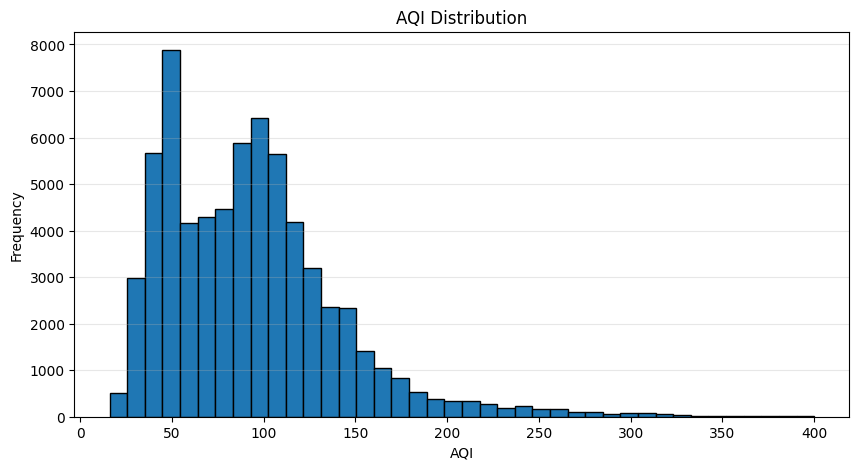

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["AQI"].dropna(),
    bins=40,
    edgecolor="black"
)

plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.show()

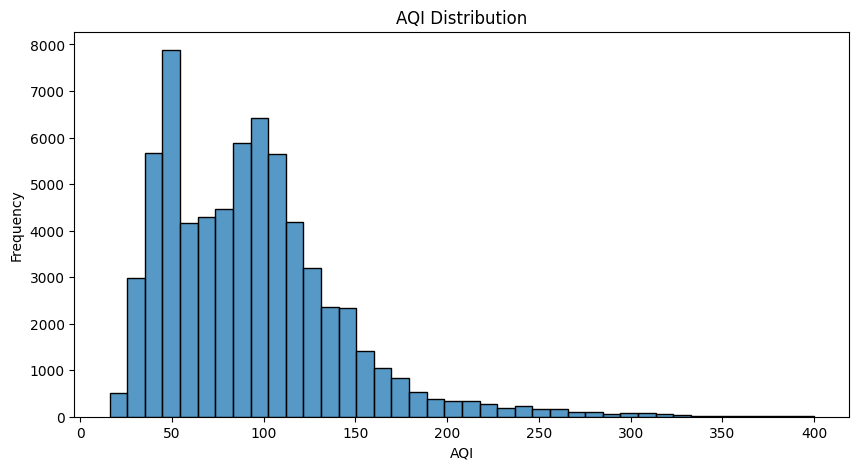

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["AQI"].dropna(),
    bins=40,
    kde=False
)

plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

In [ ]:
def aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"


df["AQI_Category"] = df["AQI"].apply(aqi_category)

category_counts = df["AQI_Category"].value_counts()

display(category_counts)

,count
AQI_Category,
Satisfactory,26596
Moderate,23412
Good,14282
Poor,1980
Very Poor,264


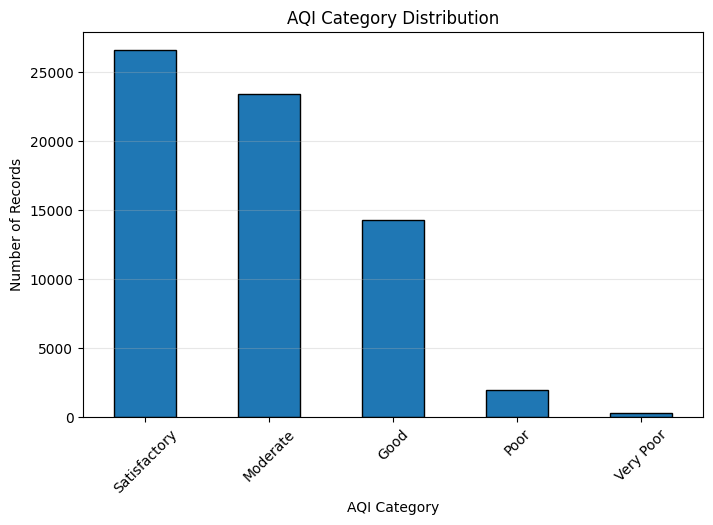

In [ ]:
plt.figure(figsize=(8, 5))

category_counts.plot(kind="bar", edgecolor="black")

plt.title("AQI Category Distribution")
plt.xlabel("AQI Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [ ]:
station_summary = df.groupby("Station")["AQI"].agg([
    "count",
    "mean",
    "min",
    "max",
    "std"
]).round(2)

display(station_summary)

,count,mean,min,max,std
Station,,,,,
Chikalthana MIDC,19166,93.19,16.0,390.0,55.71
More Chowk,28783,86.87,19.0,400.0,39.38
Rachnekar Colony,18585,102.79,19.0,300.0,50.29


<Figure size 1000x600 with 0 Axes>

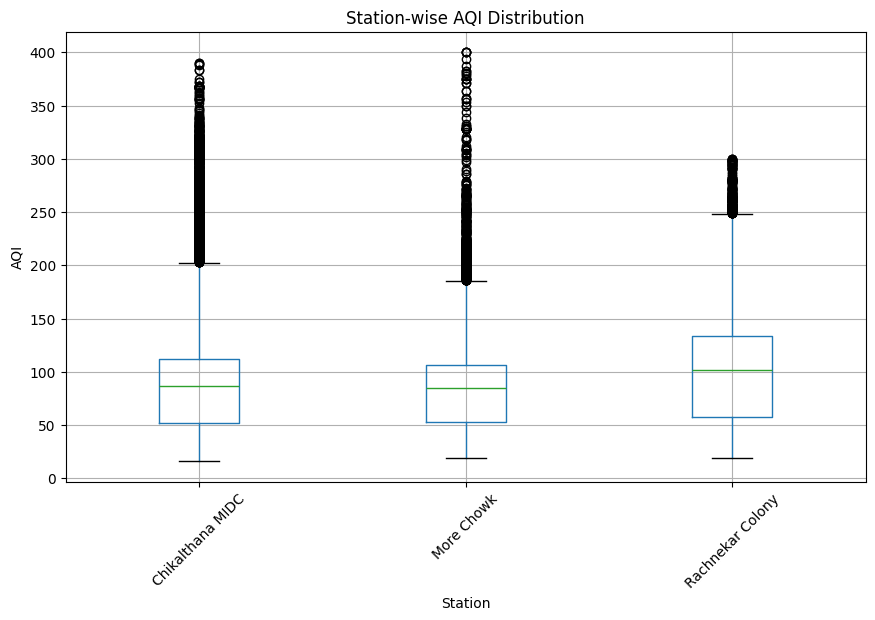

In [ ]:
plt.figure(figsize=(10, 6))

df.boxplot(
    column="AQI",
    by="Station",
    figsize=(10, 6)
)

plt.title("Station-wise AQI Distribution")
plt.suptitle("")
plt.xlabel("Station")
plt.ylabel("AQI")
plt.xticks(rotation=45)
plt.show()

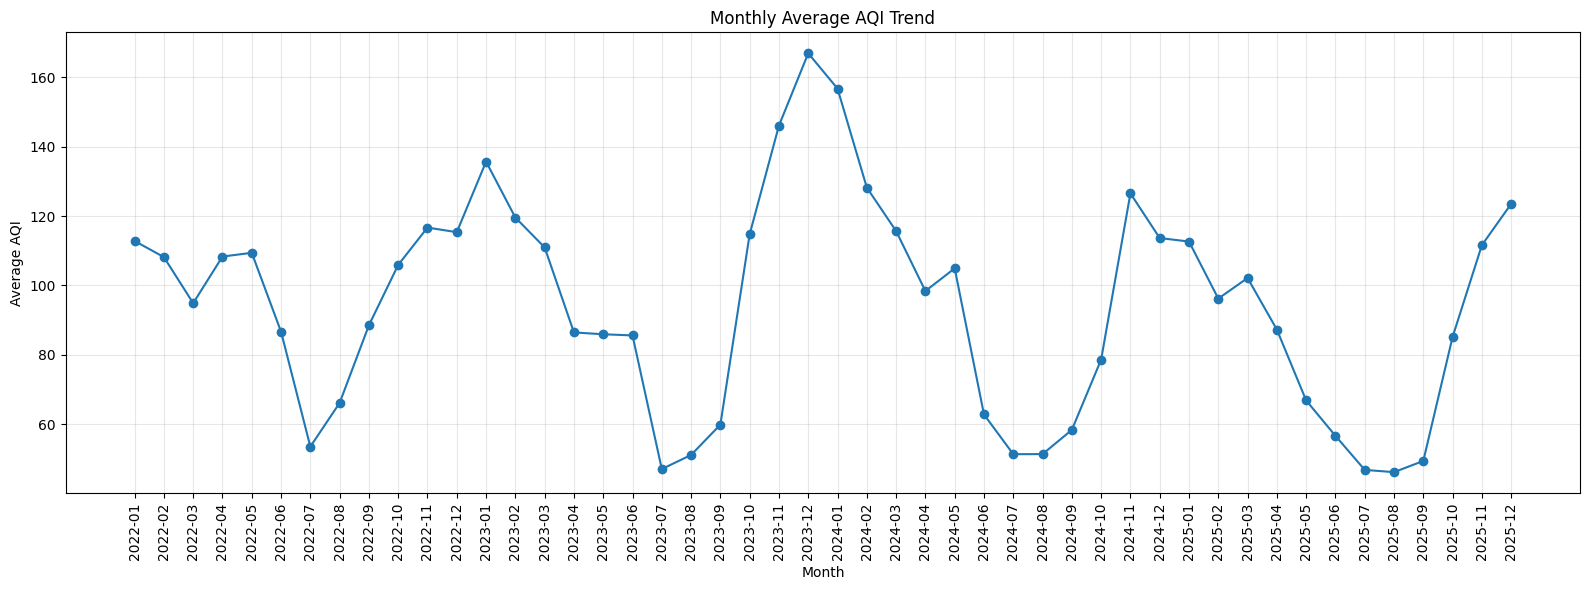

In [ ]:
# Create Year-Month column
df["YearMonth"] = df["Datetime"].dt.to_period("M").astype(str)

monthly_aqi = (
    df.groupby("YearMonth")["AQI"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(16, 6))

plt.plot(
    monthly_aqi["YearMonth"],
    monthly_aqi["AQI"],
    marker="o"
)

plt.title("Monthly Average AQI Trend")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

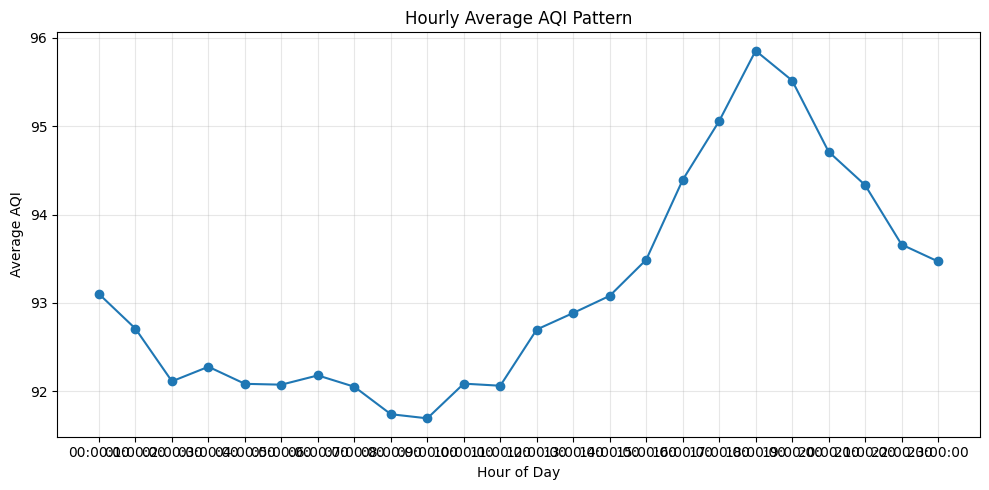

In [ ]:
hourly_aqi = (
    df.groupby("Hour")["AQI"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_aqi["Hour"],
    hourly_aqi["AQI"],
    marker="o"
)

plt.title("Hourly Average AQI Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("Average AQI")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

,mean,min,max,std
year,,,,
2022,98.85,26.0,276.0,30.33
2023,100.90,18.0,400.0,58.13
2024,98.41,16.0,329.0,50.78
2025,80.77,18.0,340.0,38.29


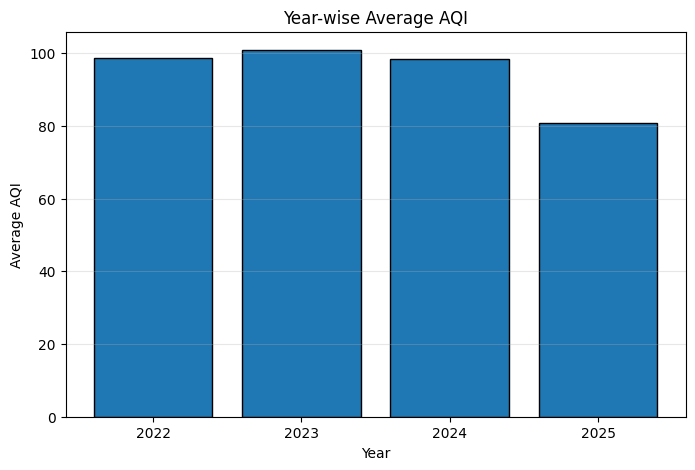

In [ ]:
yearly_aqi = (
    df.groupby("year")["AQI"]
    .agg(["mean", "min", "max", "std"])
    .round(2)
)

display(yearly_aqi)

plt.figure(figsize=(8, 5))

plt.bar(
    yearly_aqi.index.astype(str),
    yearly_aqi["mean"],
    edgecolor="black"
)

plt.title("Year-wise Average AQI")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.grid(axis="y", alpha=0.3)
plt.show()

,mean,min,max,std
year,,,,
2022,98.85,26.0,276.0,30.33
2023,100.90,18.0,400.0,58.13
2024,98.41,16.0,329.0,50.78
2025,80.77,18.0,340.0,38.29


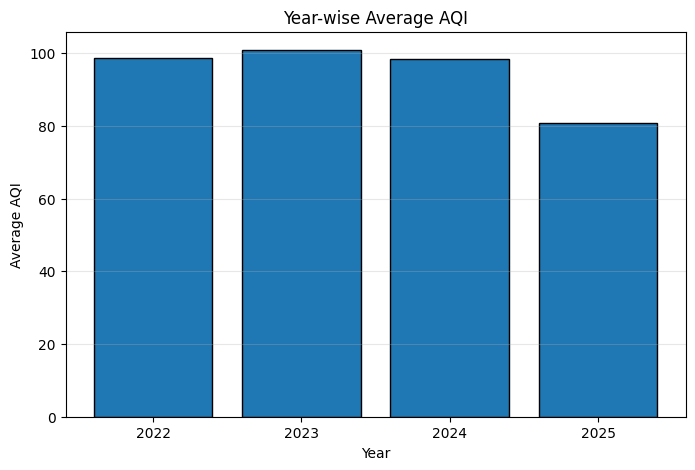

In [ ]:
yearly_aqi = (
    df.groupby("year")["AQI"]
    .agg(["mean", "min", "max", "std"])
    .round(2)
)

display(yearly_aqi)

plt.figure(figsize=(8, 5))

plt.bar(
    yearly_aqi.index.astype(str),
    yearly_aqi["mean"],
    edgecolor="black"
)

plt.title("Year-wise Average AQI")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [ ]:
numeric_columns = df.select_dtypes(
    include=["number"]
).columns

correlation_matrix = df[numeric_columns].corr()

display(
    correlation_matrix[["AQI"]]
    .sort_values("AQI", ascending=False)
)

,AQI
AQI,1.000000
PS,0.570891
month_cos,0.504951
co,0.370643
month_sin,0.309523
no2,0.234405
aod,0.183357
hcho,0.086416
station_latitude,0.081724
distance_to_S2_km,0.072032


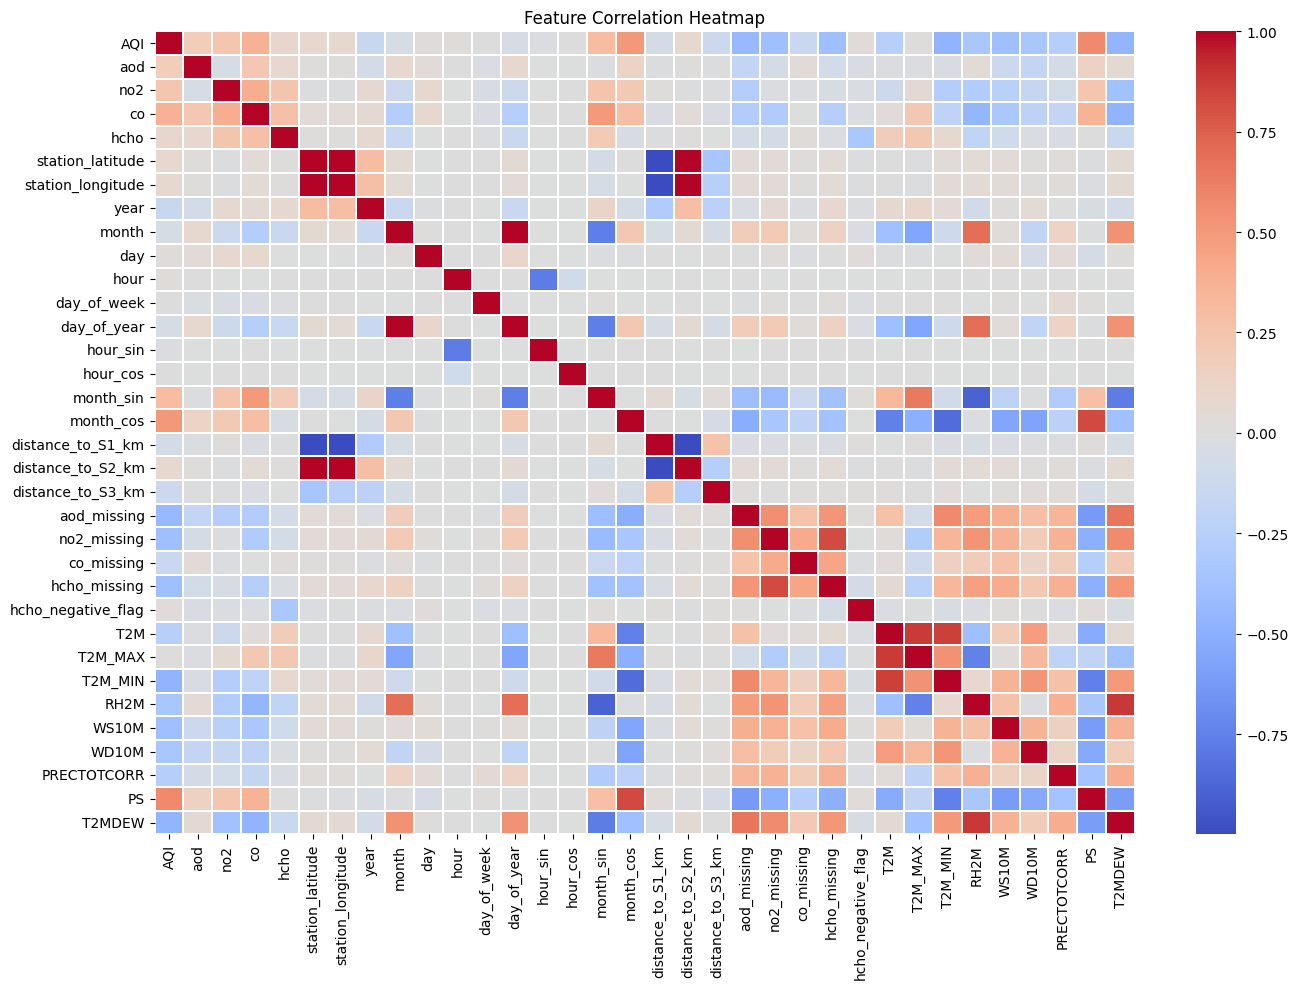

In [ ]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
satellite_features = ["aod", "no2", "co", "hcho"]

satellite_missing = df[satellite_features].isnull().sum()

satellite_summary = pd.DataFrame({
    "Feature": satellite_missing.index,
    "Missing Values": satellite_missing.values,
    "Missing Percentage": (
        satellite_missing.values / len(df) * 100
    ).round(2)
})

display(satellite_summary)

,Feature,Missing Values,Missing Percentage
0,aod,0,0.0
1,no2,0,0.0
2,co,0,0.0
3,hcho,0,0.0


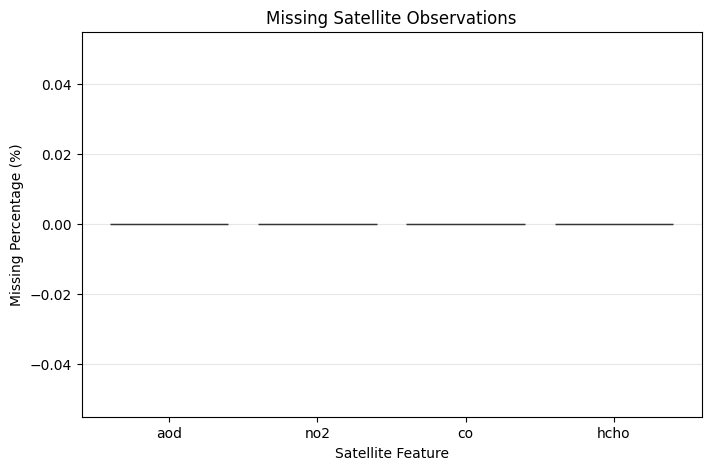

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    satellite_summary["Feature"],
    satellite_summary["Missing Percentage"],
    edgecolor="black"
)

plt.title("Missing Satellite Observations")
plt.xlabel("Satellite Feature")
plt.ylabel("Missing Percentage (%)")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [ ]:
for feature in satellite_features:
    df[f"{feature}_missing"] = (
        df[feature].isnull().astype(int)
    )

missing_indicator_summary = df[
    [f"{feature}_missing" for feature in satellite_features]
].sum()

display(missing_indicator_summary)

,0
aod_missing,0
no2_missing,0
co_missing,0
hcho_missing,0


In [ ]:
for feature in satellite_features:
    df[f"{feature}_availability"] = np.where(
        df[feature].isnull(),
        "Missing",
        "Available"
    )

    comparison = df.groupby(
        f"{feature}_availability"
    )["AQI"].agg(["count", "mean"]).round(2)

    print(f"\nAQI comparison for {feature.upper()}:")
    display(comparison)


AQI comparison for AOD:


,count,mean
aod_availability,,
Available,66534,93.13



AQI comparison for NO2:


,count,mean
no2_availability,,
Available,66534,93.13



AQI comparison for CO:


,count,mean
co_availability,,
Available,66534,93.13



AQI comparison for HCHO:


,count,mean
hcho_availability,,
Available,66534,93.13


In [ ]:
EDA_DIR.mkdir(parents=True, exist_ok=True)

monthly_aqi.to_csv(
    EDA_DIR / "monthly_aqi_trend.csv",
    index=False
)

hourly_aqi.to_csv(
    EDA_DIR / "hourly_aqi_pattern.csv",
    index=False
)

station_summary.to_csv(
    EDA_DIR / "station_aqi_summary.csv"
)

satellite_summary.to_csv(
    EDA_DIR / "satellite_missing_summary.csv",
    index=False
)

print("EDA summary files saved successfully!")
print("Location:", EDA_DIR)

EDA summary files saved successfully!
Location: /content/drive/MyDrive/HetEvoAgent_Training/eda_results


In [ ]:
# Sort data chronologically
df = df.sort_values("Datetime").reset_index(drop=True)

print("Dataset sorted successfully!")
print(df[["Datetime", "AQI"]].head())

Dataset sorted successfully!
             Datetime    AQI
0 2022-01-01 00:00:00   71.0
1 2022-01-01 01:00:00   73.0
2 2022-01-01 02:00:00   80.0
3 2022-01-01 03:00:00   89.0
4 2022-01-01 04:00:00  102.0


In [ ]:
train_df = df[
    df["Datetime"] < "2025-01-01"
].copy()

val_df = df[
    (df["Datetime"] >= "2025-01-01") &
    (df["Datetime"] < "2025-07-01")
].copy()

test_df = df[
    df["Datetime"] >= "2025-07-01"
].copy()

print("Training set:", train_df.shape)
print("Validation set:", val_df.shape)
print("Testing set:", test_df.shape)

Training set: (44202, 46)
Validation set: (11634, 46)
Testing set: (10698, 46)


In [ ]:
feature_columns = [
    # Satellite features
    "aod",
    "no2",
    "co",
    "hcho",

    # Weather features
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "RH2M",
    "WS10M",
    "WD10M",
    "PRECTOTCORR",
    "PS",
    "T2MDEW",

    # Temporal features
    "year",
    "month",
    "day",
    "hour",
    "day_of_week",
    "day_of_year",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",

    # Spatial features
    "station_latitude",
    "station_longitude",

    # Missing indicators
    "aod_missing",
    "no2_missing",
    "co_missing",
    "hcho_missing",

    # HCHO quality flag
    "hcho_negative_flag"
]

target_column = "AQI"

# Keep only features available in the dataset
available_features = [
    feature for feature in feature_columns
    if feature in df.columns
]

missing_features = [
    feature for feature in feature_columns
    if feature not in df.columns
]

print("Available features:", len(available_features))
print("Missing features:", missing_features)

Available features: 30
Missing features: []


In [ ]:
X_train = train_df[available_features]
y_train = train_df[target_column]

X_val = val_df[available_features]
y_val = val_df[target_column]

X_test = test_df[available_features]
y_test = test_df[target_column]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (44202, 30)
X_val: (11634, 30)
X_test: (10698, 30)


In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)

X_val_imputed = imputer.transform(X_val)

X_test_imputed = imputer.transform(X_test)

print("Missing values handled successfully!")
print("Training features:", X_train_imputed.shape)

Missing values handled successfully!
Training features: (44202, 30)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

print("ML libraries imported successfully!")

ML libraries imported successfully!


In [ ]:
def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "R2 Score": round(r2, 3)
    }

In [ ]:
mean_prediction = y_train.mean()

baseline_predictions = np.full(
    len(y_test),
    mean_prediction
)

baseline_result = evaluate_model(
    "Historical Mean Baseline",
    y_test,
    baseline_predictions
)

print(baseline_result)

{'Model': 'Historical Mean Baseline', 'MAE': 46.736, 'RMSE': np.float64(52.708), 'R2 Score': -0.338}


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

rf_model.fit(
    X_train_imputed,
    y_train
)

print("Random Forest training completed!")

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

rf_model.fit(
    X_train_imputed,
    y_train
)

print("Random Forest training completed!")

Training Random Forest...
Random Forest training completed!


In [ ]:
hgb_model = HistGradientBoostingRegressor(
    max_iter=150,
    learning_rate=0.08,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

print("Training HistGradientBoosting...")

hgb_model.fit(
    X_train_imputed,
    y_train
)

print("HistGradientBoosting training completed!")

Training HistGradientBoosting...
HistGradientBoosting training completed!


In [ ]:
hgb_predictions = hgb_model.predict(
    X_test_imputed
)

hgb_result = evaluate_model(
    "HistGradientBoosting",
    y_test,
    hgb_predictions
)

print(hgb_result)

{'Model': 'HistGradientBoosting', 'MAE': 24.563, 'RMSE': np.float64(34.143), 'R2 Score': 0.439}


In [ ]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Model directory:", MODEL_DIR)

Model directory: /content/drive/MyDrive/HetEvoAgent_Training/trained_models


In [ ]:
joblib.dump(
    rf_model,
    MODEL_DIR / "random_forest_aqi.pkl"
)

joblib.dump(
    hgb_model,
    MODEL_DIR / "hist_gradient_boosting_aqi.pkl"
)

joblib.dump(
    imputer,
    MODEL_DIR / "aqi_imputer.pkl"
)

print("Models and imputer saved successfully!")

Models and imputer saved successfully!


In [ ]:
feature_info = pd.DataFrame({
    "feature_name": available_features
})

feature_info.to_csv(
    MODEL_DIR / "feature_columns.csv",
    index=False
)

print("Feature columns saved!")
display(feature_info)

Feature columns saved!


,feature_name
0,aod
1,no2
2,co
3,hcho
4,T2M
5,T2M_MAX
6,T2M_MIN
7,RH2M
8,WS10M
9,WD10M


In [ ]:
# Recreate results table
results = pd.DataFrame([
    baseline_result,
    rf_result,
    hgb_result
])

# Display results
display(results)

# Save results
results.to_csv(
    MODEL_DIR / "baseline_model_results.csv",
    index=False
)

print("Model results saved successfully!")

NameError: name 'rf_result' is not defined

In [ ]:
rf_predictions = rf_model.predict(X_test_imputed)

rf_result = evaluate_model(
    "Random Forest",
    y_test,
    rf_predictions
)

print(rf_result)

{'Model': 'Random Forest', 'MAE': 25.169, 'RMSE': np.float64(35.599), 'R2 Score': 0.39}


In [ ]:
hgb_model = HistGradientBoostingRegressor(
    max_iter=150,
    learning_rate=0.08,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

print("Training HistGradientBoosting...")

hgb_model.fit(
    X_train_imputed,
    y_train
)

print("HistGradientBoosting training completed!")

Training HistGradientBoosting...
HistGradientBoosting training completed!


In [ ]:
hgb_predictions = hgb_model.predict(X_test_imputed)

hgb_result = evaluate_model(
    "HistGradientBoosting",
    y_test,
    hgb_predictions
)

results = pd.DataFrame([
    baseline_result,
    rf_result,
    hgb_result
])

display(results)

,Model,MAE,RMSE,R2 Score
0,Historical Mean Baseline,46.736,52.708,-0.338
1,Random Forest,25.169,35.599,0.390
2,HistGradientBoosting,24.563,34.143,0.439


In [ ]:
# Create model directories
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save trained models
joblib.dump(
    rf_model,
    MODEL_DIR / "random_forest_aqi.pkl"
)

joblib.dump(
    hgb_model,
    MODEL_DIR / "hist_gradient_boosting_aqi.pkl"
)

# Save imputer
joblib.dump(
    imputer,
    MODEL_DIR / "aqi_imputer.pkl"
)

# Save feature columns
pd.DataFrame({
    "feature_name": available_features
}).to_csv(
    MODEL_DIR / "feature_columns.csv",
    index=False
)

# Save results
results.to_csv(
    MODEL_DIR / "baseline_model_results.csv",
    index=False
)

print("All models and files saved successfully!")

All models and files saved successfully!


In [ ]:
# Load zone information
zones = pd.read_csv(ZONE_FILE)

print("Prediction Zones:")
display(zones)

Prediction Zones:


,zone_id,zone_name,zone_type,latitude,longitude
0,Z1,Chikalthana MIDC,Industrial,19.864981,75.411001
1,Z2,Waluj / More Chowk,Industrial + Urban,19.840930,75.241890
2,Z3,Gulmandi / Central City,Commercial,19.885817,75.331858
3,Z4,CIDCO,Residential + Urban,19.892808,75.363114
4,Z5,Shendra,Industrial + Developing,19.873282,75.491805
5,Z6,Deolai,Peripheral Residential,19.842209,75.365579


In [ ]:
print("Zone columns:")
print(zones.columns.tolist())

print("\nZone data types:")
zones.info()

Zone columns:
['zone_id', 'zone_name', 'zone_type', 'latitude', 'longitude']

Zone data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   zone_id    6 non-null      object 
 1   zone_name  6 non-null      object 
 2   zone_type  6 non-null      object 
 3   latitude   6 non-null      float64
 4   longitude  6 non-null      float64
dtypes: float64(2), object(3)
memory usage: 372.0+ bytes


In [ ]:
# Calculate average feature values from training data
training_feature_means = X_train_imputed.mean(axis=0)

zone_inputs = []

for _, zone in zones.iterrows():

    zone_features = training_feature_means.copy()

    # Identify coordinate columns
    latitude = zone["latitude"]
    longitude = zone["longitude"]

    # Replace coordinate features
    lat_index = available_features.index(
        "station_latitude"
    )

    lon_index = available_features.index(
        "station_longitude"
    )

    zone_features[lat_index] = latitude
    zone_features[lon_index] = longitude

    zone_inputs.append(zone_features)

zone_inputs = np.array(zone_inputs)

print("Zone input shape:", zone_inputs.shape)

Zone input shape: (6, 30)


In [ ]:
zone_predictions = hgb_model.predict(zone_inputs)

zone_results = zones.copy()

zone_results["Predicted_AQI"] = np.round(
    zone_predictions,
    2
)

display(zone_results)

,zone_id,zone_name,zone_type,latitude,longitude,Predicted_AQI
0,Z1,Chikalthana MIDC,Industrial,19.864981,75.411001,115.95
1,Z2,Waluj / More Chowk,Industrial + Urban,19.840930,75.241890,90.24
2,Z3,Gulmandi / Central City,Commercial,19.885817,75.331858,107.17
3,Z4,CIDCO,Residential + Urban,19.892808,75.363114,107.17
4,Z5,Shendra,Industrial + Developing,19.873282,75.491805,107.17
5,Z6,Deolai,Peripheral Residential,19.842209,75.365579,90.24


In [ ]:
ZONE_OUTPUT = MODEL_DIR / "preliminary_zone_predictions.csv"

zone_results.to_csv(
    ZONE_OUTPUT,
    index=False
)

print("Zone predictions saved successfully!")
print("File:", ZONE_OUTPUT)

Zone predictions saved successfully!
File: /content/drive/MyDrive/HetEvoAgent_Training/trained_models/preliminary_zone_predictions.csv


In [ ]:
# Check available dates
print("Available date range:")
print(df["Date"].min(), "to", df["Date"].max())

display(
    df[["Date"]].drop_duplicates().head()
)

Available date range:
2022-01-01 00:00:00 to 2025-12-31 00:00:00


,Date
0,2022-01-01
8,2022-01-04
21,2022-01-05
45,2022-01-06
69,2022-01-07


In [ ]:
prediction_date = "2025-06-15"

selected_date = pd.to_datetime(prediction_date).date()

print("Selected prediction date:", selected_date)

Selected prediction date: 2025-06-15


In [ ]:
# Filter records for selected date
date_data = df[
    df["Date"].dt.date == selected_date
].copy()

print("Records found:", len(date_data))

display(date_data.head())

Records found: 48


,Datetime,Date,Hour,Station,AQI,date,aod,no2,co,hcho,Station_original,station_latitude,station_longitude,year,month,day,hour,day_of_week,day_of_year,hour_sin,hour_cos,month_sin,month_cos,distance_to_S1_km,distance_to_S2_km,distance_to_S3_km,aod_missing,no2_missing,co_missing,hcho_missing,hcho_negative_flag,T2M,T2M_MAX,T2M_MIN,RH2M,WS10M,WD10M,PRECTOTCORR,PS,T2MDEW,AQI_Category,YearMonth,aod_availability,no2_availability,co_availability,hcho_availability
54967,2025-06-15 00:00:00,2025-06-15,00:00:00,More Chowk,53.0,2025-06-15,0.451881,0.000038,0.035267,0.000171,More Chowk,19.8406,75.2466,2025,6,15,0,6,166,0.000000,1.000000,1.224647e-16,-1.0,15.261401,0.000000,8.157414,0,0,0,0,0,28.5,33.595,23.678333,73.633333,2.811667,128.4,3.97,93.653333,22.94,Satisfactory,2025-06,Available,Available,Available,Available
54968,2025-06-15 00:00:00,2025-06-15,00:00:00,Chikalthana MIDC,124.0,2025-06-15,0.451881,0.000038,0.035267,0.000171,Chikalthana MIDC,19.8790,75.3867,2025,6,15,0,6,166,0.000000,1.000000,1.224647e-16,-1.0,0.000000,15.261401,7.121905,0,0,0,0,0,28.5,33.595,23.678333,73.633333,2.811667,128.4,3.97,93.653333,22.94,Moderate,2025-06,Available,Available,Available,Available
54969,2025-06-15 01:00:00,2025-06-15,01:00:00,More Chowk,53.0,2025-06-15,0.451881,0.000038,0.035267,0.000171,More Chowk,19.8406,75.2466,2025,6,15,1,6,166,0.258819,0.965926,1.224647e-16,-1.0,15.261401,0.000000,8.157414,0,0,0,0,0,28.5,33.595,23.678333,73.633333,2.811667,128.4,3.97,93.653333,22.94,Satisfactory,2025-06,Available,Available,Available,Available
54970,2025-06-15 01:00:00,2025-06-15,01:00:00,Chikalthana MIDC,133.0,2025-06-15,0.451881,0.000038,0.035267,0.000171,Chikalthana MIDC,19.8790,75.3867,2025,6,15,1,6,166,0.258819,0.965926,1.224647e-16,-1.0,0.000000,15.261401,7.121905,0,0,0,0,0,28.5,33.595,23.678333,73.633333,2.811667,128.4,3.97,93.653333,22.94,Moderate,2025-06,Available,Available,Available,Available
54971,2025-06-15 02:00:00,2025-06-15,02:00:00,Chikalthana MIDC,142.0,2025-06-15,0.451881,0.000038,0.035267,0.000171,Chikalthana MIDC,19.8790,75.3867,2025,6,15,2,6,166,0.500000,0.866025,1.224647e-16,-1.0,0.000000,15.261401,7.121905,0,0,0,0,0,28.5,33.595,23.678333,73.633333,2.811667,128.4,3.97,93.653333,22.94,Moderate,2025-06,Available,Available,Available,Available


In [ ]:
# Calculate average environmental values for selected date
date_feature_means = date_data[
    available_features
].mean(numeric_only=True)

# Fill missing values using training feature means
training_means = pd.Series(
    X_train_imputed.mean(axis=0),
    index=available_features
)

date_feature_means = date_feature_means.reindex(
    available_features
).fillna(training_means)

print("Date-specific environmental features:")
display(date_feature_means.to_frame("Value"))

Date-specific environmental features:


,Value
aod,4.518810e-01
no2,3.843509e-05
co,3.526673e-02
hcho,1.712818e-04
T2M,2.850000e+01
T2M_MAX,3.359500e+01
T2M_MIN,2.367833e+01
RH2M,7.363333e+01
WS10M,2.811667e+00
WD10M,1.284000e+02


In [ ]:
zone_inputs = []

for _, zone in zones.iterrows():

    zone_features = date_feature_means.values.copy()

    latitude = zone["latitude"]
    longitude = zone["longitude"]

    lat_index = available_features.index(
        "station_latitude"
    )

    lon_index = available_features.index(
        "station_longitude"
    )

    zone_features[lat_index] = latitude
    zone_features[lon_index] = longitude

    zone_inputs.append(zone_features)

zone_inputs = np.array(zone_inputs)

print("Zone input shape:", zone_inputs.shape)

Zone input shape: (6, 30)


In [ ]:
date_zone_predictions = hgb_model.predict(
    zone_inputs
)

date_zone_results = zones.copy()

date_zone_results["Prediction_Date"] = prediction_date

date_zone_results["Predicted_AQI"] = np.round(
    date_zone_predictions,
    2
)

display(date_zone_results)

,zone_id,zone_name,zone_type,latitude,longitude,Prediction_Date,Predicted_AQI
0,Z1,Chikalthana MIDC,Industrial,19.864981,75.411001,2025-06-15,68.23
1,Z2,Waluj / More Chowk,Industrial + Urban,19.840930,75.241890,2025-06-15,46.16
2,Z3,Gulmandi / Central City,Commercial,19.885817,75.331858,2025-06-15,59.13
3,Z4,CIDCO,Residential + Urban,19.892808,75.363114,2025-06-15,59.13
4,Z5,Shendra,Industrial + Developing,19.873282,75.491805,2025-06-15,59.13
5,Z6,Deolai,Peripheral Residential,19.842209,75.365579,2025-06-15,46.16


In [ ]:
def classify_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"


date_zone_results["AQI_Category"] = (
    date_zone_results["Predicted_AQI"]
    .apply(classify_aqi)
)

display(date_zone_results[
    [
        "zone_id",
        "zone_name",
        "Predicted_AQI",
        "AQI_Category"
    ]
])

,zone_id,zone_name,Predicted_AQI,AQI_Category
0,Z1,Chikalthana MIDC,68.23,Satisfactory
1,Z2,Waluj / More Chowk,46.16,Good
2,Z3,Gulmandi / Central City,59.13,Satisfactory
3,Z4,CIDCO,59.13,Satisfactory
4,Z5,Shendra,59.13,Satisfactory
5,Z6,Deolai,46.16,Good


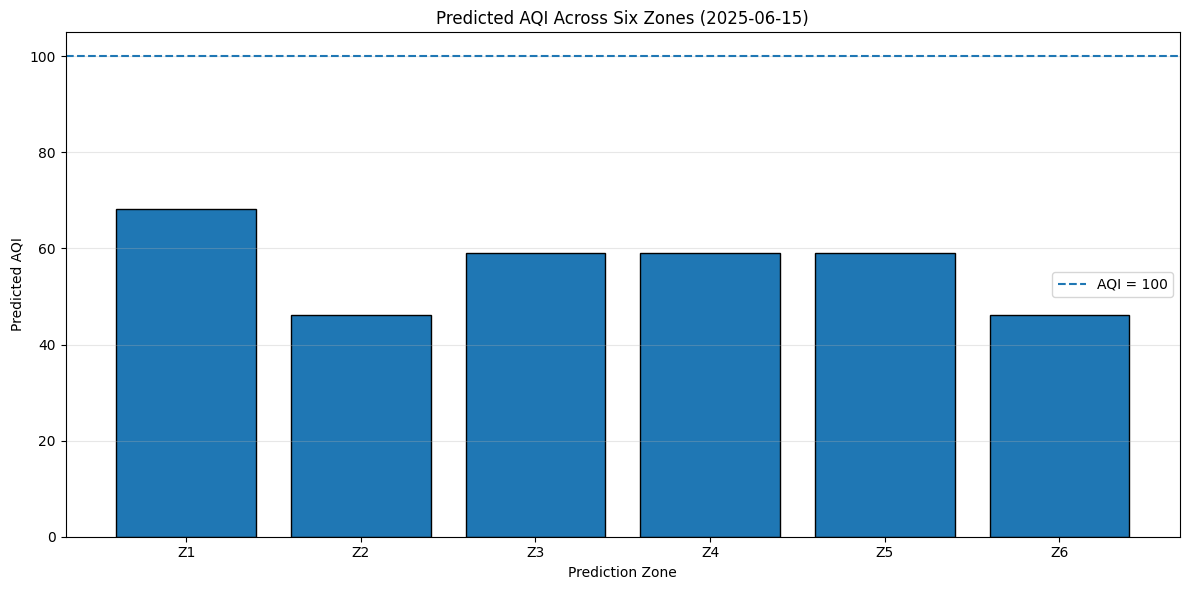

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    date_zone_results["zone_id"],
    date_zone_results["Predicted_AQI"],
    edgecolor="black"
)

plt.axhline(
    y=100,
    linestyle="--",
    label="AQI = 100"
)

plt.title(
    f"Predicted AQI Across Six Zones ({prediction_date})"
)

plt.xlabel("Prediction Zone")
plt.ylabel("Predicted AQI")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
PREDICTION_DIR = PROJECT_DIR / "predictions"

PREDICTION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

output_file = (
    PREDICTION_DIR /
    f"zone_predictions_{prediction_date}.csv"
)

date_zone_results.to_csv(
    output_file,
    index=False
)

print("Predictions saved successfully!")
print("File location:", output_file)

Predictions saved successfully!
File location: /content/drive/MyDrive/HetEvoAgent_Training/predictions/zone_predictions_2025-06-15.csv


In [ ]:
summary = date_zone_results[
    [
        "zone_id",
        "zone_name",
        "zone_type",
        "Predicted_AQI",
        "AQI_Category"
    ]
].copy()

summary = summary.sort_values(
    "Predicted_AQI",
    ascending=False
)

display(summary)

,zone_id,zone_name,zone_type,Predicted_AQI,AQI_Category
0,Z1,Chikalthana MIDC,Industrial,68.23,Satisfactory
2,Z3,Gulmandi / Central City,Commercial,59.13,Satisfactory
4,Z5,Shendra,Industrial + Developing,59.13,Satisfactory
3,Z4,CIDCO,Residential + Urban,59.13,Satisfactory
1,Z2,Waluj / More Chowk,Industrial + Urban,46.16,Good
5,Z6,Deolai,Peripheral Residential,46.16,Good


In [ ]:
# Generate validation predictions
val_predictions = hgb_model.predict(
    X_val_imputed
)

val_result = evaluate_model(
    "HistGradientBoosting - Validation",
    y_val,
    val_predictions
)

print(val_result)

{'Model': 'HistGradientBoosting - Validation', 'MAE': 29.396, 'RMSE': np.float64(38.336), 'R2 Score': -0.848}


In [ ]:
comparison = pd.DataFrame([
    val_result,
    hgb_result
])

display(comparison)

,Model,MAE,RMSE,R2 Score
0,HistGradientBoosting - Validation,29.396,38.336,-0.848
1,HistGradientBoosting,24.563,34.143,0.439


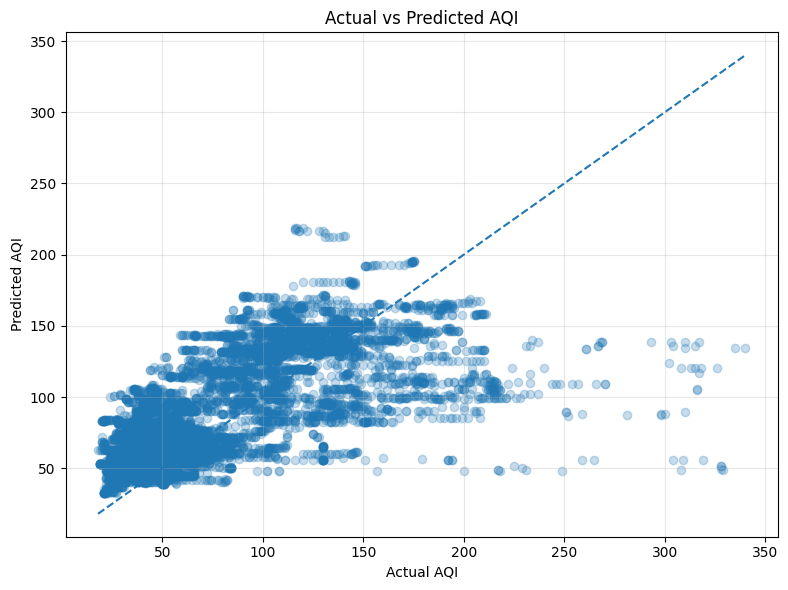

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_predictions * 0 + hgb_predictions,
    alpha=0.25
)

min_value = min(y_test.min(), hgb_predictions.min())
max_value = max(y_test.max(), hgb_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted AQI")
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
test_analysis = test_df[
    ["Datetime", "Station", "AQI"]
].copy()

test_analysis["Predicted_AQI"] = hgb_predictions

test_analysis["Error"] = (
    test_analysis["AQI"] -
    test_analysis["Predicted_AQI"]
)

test_analysis["Absolute_Error"] = (
    test_analysis["Error"].abs()
)

display(test_analysis.head())

,Datetime,Station,AQI,Predicted_AQI,Error,Absolute_Error
55836,2025-07-01 00:00:00,More Chowk,33.0,46.476198,-13.476198,13.476198
55837,2025-07-01 00:00:00,Rachnekar Colony,54.0,54.757342,-0.757342,0.757342
55838,2025-07-01 01:00:00,Rachnekar Colony,54.0,54.730679,-0.730679,0.730679
55839,2025-07-01 01:00:00,More Chowk,33.0,46.449535,-13.449535,13.449535
55840,2025-07-01 02:00:00,Rachnekar Colony,54.0,54.697989,-0.697989,0.697989


In [ ]:
validation_file = (
    MODEL_DIR / "validation_model_results.csv"
)

comparison.to_csv(
    validation_file,
    index=False
)

test_analysis.to_csv(
    MODEL_DIR / "test_prediction_errors.csv",
    index=False
)

print("Validation results saved successfully!")

Validation results saved successfully!


In [ ]:
station_test_results = []

for station in test_df["Station"].unique():

    mask = test_df["Station"] == station

    actual = y_test[mask]
    predicted = hgb_predictions[mask]

    result = evaluate_model(
        station,
        actual,
        predicted
    )

    station_test_results.append(result)

station_results = pd.DataFrame(
    station_test_results
)

display(station_results)

,Model,MAE,RMSE,R2 Score
0,More Chowk,23.641,33.543,0.345
1,Rachnekar Colony,21.239,27.763,0.598
2,Chikalthana MIDC,30.173,41.834,0.337


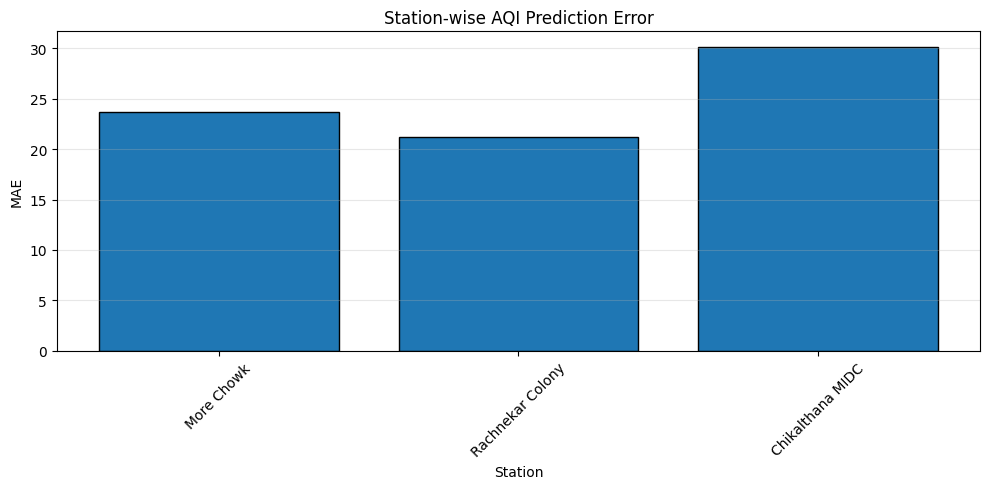

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    station_results["Model"],
    station_results["MAE"],
    edgecolor="black"
)

plt.title("Station-wise AQI Prediction Error")
plt.xlabel("Station")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
station_results.to_csv(
    MODEL_DIR / "station_wise_test_results.csv",
    index=False
)

print("Station-wise evaluation saved successfully!")

Station-wise evaluation saved successfully!


In [ ]:
from math import radians, sin, cos, sqrt, atan2

def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth's radius in km

    lat1, lon1, lat2, lon2 = map(
        radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        sin(dlat / 2) ** 2
        + cos(lat1) * cos(lat2)
        * sin(dlon / 2) ** 2
    )

    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

In [ ]:
distance_records = []

for _, zone in zones.iterrows():

    record = {
        "zone_id": zone["zone_id"],
        "zone_name": zone["zone_name"]
    }

    for _, station in stations.iterrows():

        station_id = station[station_id_column]

        distance = calculate_distance(
            zone["latitude"],
            zone["longitude"],
            station["latitude"],
            station["longitude"]
        )

        record[f"distance_to_{station_id}_km"] = round(
            distance, 3
        )

    distance_records.append(record)

zone_distances = pd.DataFrame(distance_records)

display(zone_distances)

,zone_id,zone_name,distance_to_S1_km,distance_to_S2_km,distance_to_S3_km
0,Z1,Chikalthana MIDC,2.981,17.407,9.474
1,Z2,Waluj / More Chowk,15.725,0.494,8.614
2,Z3,Gulmandi / Central City,5.785,10.236,2.675
3,Z4,CIDCO,2.905,13.497,5.476
4,Z5,Shendra,11.009,25.901,17.951
5,Z6,Deolai,4.649,12.446,5.324


In [ ]:
print("Station columns:")
print(stations.columns.tolist())

display(stations.head())

Station columns:
['station_id', 'station_name', 'latitude', 'longitude', 'coordinate_status']


,station_id,station_name,latitude,longitude,coordinate_status
0,S1,MIDC Chikalthana,19.879000,75.386700,provisional
1,S2,More Chowk / Waluj,19.840600,75.246600,reference
2,S3,Rachnakar Colony,19.864304,75.320413,reference


In [ ]:
# Display column names
print(stations.columns.tolist())

# Detect station identifier column
possible_columns = [
    "Station",
    "station",
    "station_id",
    "Station_ID",
    "station_name",
    "Station_Name"
]

station_id_column = next(
    (
        column for column in possible_columns
        if column in stations.columns
    ),
    None
)

if station_id_column is None:
    raise ValueError(
        "Station identifier column not found. "
        "Check the displayed column names."
    )

print("Using station column:", station_id_column)

['station_id', 'station_name', 'latitude', 'longitude', 'coordinate_status']
Using station column: station_id


In [ ]:

# Display available columns
print("Station columns:", stations.columns.tolist())
print("Zone columns:", zones.columns.tolist())


# Automatically detect station identifier column
station_id_candidates = [
    "station_id",
    "Station_ID",
    "Station",
    "station",
    "station_name",
    "Station_Name",
    "name"
]

station_id_column = next(
    (col for col in station_id_candidates if col in stations.columns),
    None
)


# Detect latitude and longitude columns
lat_candidates = ["latitude", "Latitude", "lat", "Lat"]
lon_candidates = ["longitude", "Longitude", "lon", "Lon", "long"]

lat_column = next(
    (col for col in lat_candidates if col in stations.columns),
    None
)

lon_column = next(
    (col for col in lon_candidates if col in stations.columns),
    None
)


# Validate required columns
if station_id_column is None:
    raise ValueError(
        f"Station identifier column not found. Available columns: {stations.columns.tolist()}"
    )

if lat_column is None or lon_column is None:
    raise ValueError(
        f"Latitude/longitude columns not found. Available columns: {stations.columns.tolist()}"
    )


print("Station ID column:", station_id_column)
print("Latitude column:", lat_column)
print("Longitude column:", lon_column)


# Calculate distances
distance_records = []

for _, zone in zones.iterrows():

    record = {
        "zone_id": zone["zone_id"],
        "zone_name": zone["zone_name"]
    }

    for _, station in stations.iterrows():

        station_id = str(
            station[station_id_column]
        ).strip().replace(" ", "_")

        distance = calculate_distance(
            zone["latitude"],
            zone["longitude"],
            station[lat_column],
            station[lon_column]
        )

        record[f"distance_to_{station_id}_km"] = round(distance, 3)

    distance_records.append(record)


# Create distance DataFrame
zone_distances = pd.DataFrame(distance_records)

print("Zone distance dataset:")
display(zone_distances)


# Save the results
distance_file = PREDICTION_DIR / "zone_station_distances.csv"

zone_distances.to_csv(distance_file, index=False)

print(f"Saved successfully to: {distance_file}")

Station columns: ['station_id', 'station_name', 'latitude', 'longitude', 'coordinate_status']
Zone columns: ['zone_id', 'zone_name', 'zone_type', 'latitude', 'longitude']
Station ID column: station_id
Latitude column: latitude
Longitude column: longitude
Zone distance dataset:


,zone_id,zone_name,distance_to_S1_km,distance_to_S2_km,distance_to_S3_km
0,Z1,Chikalthana MIDC,2.981,17.407,9.474
1,Z2,Waluj / More Chowk,15.725,0.494,8.614
2,Z3,Gulmandi / Central City,5.785,10.236,2.675
3,Z4,CIDCO,2.905,13.497,5.476
4,Z5,Shendra,11.009,25.901,17.951
5,Z6,Deolai,4.649,12.446,5.324


Saved successfully to: /content/drive/MyDrive/HetEvoAgent_Training/predictions/zone_station_distances.csv


In [ ]:


# Copy the distance dataset
nearest_station_df = zone_distances.copy()

# Identify distance columns
distance_columns = [
    col for col in nearest_station_df.columns
    if col.startswith("distance_to_") and col.endswith("_km")
]

# Find nearest station
nearest_station_df["nearest_station"] = (
    nearest_station_df[distance_columns]
    .idxmin(axis=1)
    .str.replace("distance_to_", "", regex=False)
    .str.replace("_km", "", regex=False)
)

# Find minimum distance
nearest_station_df["nearest_station_distance_km"] = (
    nearest_station_df[distance_columns].min(axis=1)
)

# Display results
display(
    nearest_station_df[
        [
            "zone_id",
            "zone_name",
            "nearest_station",
            "nearest_station_distance_km"
        ]
    ]
)

# Save results
nearest_station_file = (
    PREDICTION_DIR / "nearest_station_by_zone.csv"
)

nearest_station_df.to_csv(
    nearest_station_file,
    index=False
)

print(f"Saved successfully to: {nearest_station_file}")

,zone_id,zone_name,nearest_station,nearest_station_distance_km
0,Z1,Chikalthana MIDC,S1,2.981
1,Z2,Waluj / More Chowk,S2,0.494
2,Z3,Gulmandi / Central City,S3,2.675
3,Z4,CIDCO,S1,2.905
4,Z5,Shendra,S1,11.009
5,Z6,Deolai,S1,4.649


Saved successfully to: /content/drive/MyDrive/HetEvoAgent_Training/predictions/nearest_station_by_zone.csv


In [ ]:
# ==========================================
# CELL 70: SPATIAL INFLUENCE WEIGHTS
# ==========================================

import numpy as np

# Copy distance dataset
spatial_weights = zone_distances.copy()

# Identify distance columns
distance_columns = [
    col for col in spatial_weights.columns
    if col.startswith("distance_to_") and col.endswith("_km")
]

# Calculate inverse distances
# Add small value to avoid division by zero
for col in distance_columns:
    weight_col = col.replace(
        "distance_to_", "weight_to_"
    )

    spatial_weights[weight_col] = 1 / (
        spatial_weights[col] + 0.001
    )


# Normalize weights so their sum equals 1
weight_columns = [
    col for col in spatial_weights.columns
    if col.startswith("weight_to_")
]

weight_sum = spatial_weights[weight_columns].sum(axis=1)

for col in weight_columns:
    spatial_weights[col] = (
        spatial_weights[col] / weight_sum
    )


# Display normalized weights
display(
    spatial_weights[
        ["zone_id", "zone_name"] + weight_columns
    ]
)


# Save spatial weights
weights_file = (
    PREDICTION_DIR / "spatial_influence_weights.csv"
)

spatial_weights.to_csv(
    weights_file,
    index=False
)

print(f"Saved successfully to: {weights_file}")

,zone_id,zone_name,weight_to_S1_km,weight_to_S2_km,weight_to_S3_km
0,Z1,Chikalthana MIDC,0.672937,0.115274,0.211789
1,Z2,Waluj / More Chowk,0.028906,0.918329,0.052765
2,Z3,Gulmandi / Central City,0.268284,0.151636,0.580080
3,Z4,CIDCO,0.572779,0.123314,0.303907
4,Z5,Shendra,0.490589,0.208532,0.300879
5,Z6,Deolai,0.445073,0.166272,0.388655


Saved successfully to: /content/drive/MyDrive/HetEvoAgent_Training/predictions/spatial_influence_weights.csv


In [ ]:
# ==========================================
# CELL 71: VALIDATE SPATIAL WEIGHTS
# ==========================================

# Identify weight columns
weight_columns = [
    col for col in spatial_weights.columns
    if col.startswith("weight_to_")
]

# Calculate total weight for each zone
spatial_weights["total_weight"] = (
    spatial_weights[weight_columns].sum(axis=1)
)

# Display validation results
validation_df = spatial_weights[
    [
        "zone_id",
        "zone_name",
        "total_weight"
    ]
].copy()

display(validation_df)

# Check whether weights sum to 1
weights_valid = np.allclose(
    spatial_weights["total_weight"],
    1.0,
    atol=0.001
)

if weights_valid:
    print("✅ All spatial weights sum to approximately 1.0")
else:
    print("⚠️ Spatial weight validation failed")

# Check for negative weights
negative_weights = (
    spatial_weights[weight_columns] < 0
).any().any()

if not negative_weights:
    print("✅ No negative weights found")
else:
    print("⚠️ Negative weights detected")

,zone_id,zone_name,total_weight
0,Z1,Chikalthana MIDC,1.0
1,Z2,Waluj / More Chowk,1.0
2,Z3,Gulmandi / Central City,1.0
3,Z4,CIDCO,1.0
4,Z5,Shendra,1.0
5,Z6,Deolai,1.0


✅ All spatial weights sum to approximately 1.0
✅ No negative weights found


In [ ]:
# ==========================================
# CELL 72: DAILY STATION AQI FEATURES
# ==========================================

# Ensure Datetime is in datetime format
df["Datetime"] = pd.to_datetime(df["Datetime"])
df["Date"] = df["Datetime"].dt.date

# Create daily AQI statistics for each station
daily_station_aqi = (
    df.groupby(["Date", "Station"])["AQI"]
    .agg(
        station_aqi_mean="mean",
        station_aqi_max="max",
        station_aqi_min="min",
        station_aqi_std="std"
    )
    .reset_index()
)

# Replace missing standard deviation
daily_station_aqi["station_aqi_std"] = (
    daily_station_aqi["station_aqi_std"].fillna(0)
)

# Display results
print("Daily station AQI dataset:")
display(daily_station_aqi.head(10))

print(
    "Dataset shape:",
    daily_station_aqi.shape
)

# Save the dataset
daily_station_file = (
    PREDICTION_DIR / "daily_station_aqi_features.csv"
)

daily_station_aqi.to_csv(
    daily_station_file,
    index=False
)

print(f"Saved successfully to: {daily_station_file}")

Daily station AQI dataset:


,Date,Station,station_aqi_mean,station_aqi_max,station_aqi_min,station_aqi_std
0,2022-01-01,More Chowk,89.750000,102.0,71.0,13.413746
1,2022-01-04,More Chowk,90.307692,93.0,88.0,1.601282
2,2022-01-05,More Chowk,104.541667,111.0,93.0,6.392789
3,2022-01-06,More Chowk,112.458333,114.0,111.0,0.832971
4,2022-01-07,More Chowk,113.047619,119.0,111.0,2.312492
5,2022-01-13,More Chowk,97.909091,100.0,97.0,0.971454
6,2022-01-14,More Chowk,99.608696,101.0,96.0,1.269901
7,2022-01-15,More Chowk,93.916667,96.0,91.0,1.815792
8,2022-01-16,More Chowk,95.083333,98.0,92.0,2.104171
9,2022-01-17,More Chowk,99.041667,103.0,97.0,1.573674


Dataset shape: (2952, 6)
Saved successfully to: /content/drive/MyDrive/HetEvoAgent_Training/predictions/daily_station_aqi_features.csv


In [ ]:
# ==========================================
# CELL 73: CHECK STATION NAME MATCHING
# ==========================================

print("Stations in AQI dataset:")
print(sorted(df["Station"].dropna().unique()))

print("\nStations in coordinate dataset:")
print(stations[station_id_column].unique())

# Display daily AQI station names
print("\nDaily AQI station names:")
print(daily_station_aqi["Station"].unique())

Stations in AQI dataset:
['Chikalthana MIDC', 'More Chowk', 'Rachnekar Colony']

Stations in coordinate dataset:
['S1' 'S2' 'S3']

Daily AQI station names:
['More Chowk' 'Rachnekar Colony' 'Chikalthana MIDC']


In [ ]:
# ==========================================
# CELL 74: MAP STATION NAMES TO IDs
# ==========================================

station_mapping = {
    "Chikalthana MIDC": "S1",
    "More Chowk": "S2",
    "Rachnekar Colony": "S3"
}

# Create a copy
daily_station_aqi_mapped = daily_station_aqi.copy()

# Map station names to IDs
daily_station_aqi_mapped["station_id"] = (
    daily_station_aqi_mapped["Station"]
    .map(station_mapping)
)

# Check for unmatched stations
unmatched = daily_station_aqi_mapped[
    daily_station_aqi_mapped["station_id"].isna()
]

if len(unmatched) == 0:
    print("✅ All station names mapped successfully!")
else:
    print("⚠️ Unmatched stations:")
    display(unmatched["Station"].unique())

# Display mapped data
display(daily_station_aqi_mapped.head(10))

# Save mapped dataset
mapped_file = (
    PREDICTION_DIR / "daily_station_aqi_mapped.csv"
)

daily_station_aqi_mapped.to_csv(
    mapped_file,
    index=False
)

print(f"Saved successfully to: {mapped_file}")

✅ All station names mapped successfully!


,Date,Station,station_aqi_mean,station_aqi_max,station_aqi_min,station_aqi_std,station_id
0,2022-01-01,More Chowk,89.750000,102.0,71.0,13.413746,S2
1,2022-01-04,More Chowk,90.307692,93.0,88.0,1.601282,S2
2,2022-01-05,More Chowk,104.541667,111.0,93.0,6.392789,S2
3,2022-01-06,More Chowk,112.458333,114.0,111.0,0.832971,S2
4,2022-01-07,More Chowk,113.047619,119.0,111.0,2.312492,S2
5,2022-01-13,More Chowk,97.909091,100.0,97.0,0.971454,S2
6,2022-01-14,More Chowk,99.608696,101.0,96.0,1.269901,S2
7,2022-01-15,More Chowk,93.916667,96.0,91.0,1.815792,S2
8,2022-01-16,More Chowk,95.083333,98.0,92.0,2.104171,S2
9,2022-01-17,More Chowk,99.041667,103.0,97.0,1.573674,S2


Saved successfully to: /content/drive/MyDrive/HetEvoAgent_Training/predictions/daily_station_aqi_mapped.csv


In [ ]:
# ==========================================
# CELL 75: IDW-WEIGHTED AQI BY ZONE AND DATE
# ==========================================

import pandas as pd
import numpy as np

# Prepare daily station AQI
aqi_data = daily_station_aqi_mapped.copy()

aqi_data["Date"] = pd.to_datetime(aqi_data["Date"])

# Station IDs and their weight columns
station_ids = ["S1", "S2", "S3"]

weight_columns = [
    f"weight_to_{station_id}"
    for station_id in station_ids
]

# Create lookup table for station AQI
aqi_lookup = aqi_data.pivot(
    index="Date",
    columns="station_id",
    values="station_aqi_mean"
)

# Ensure all station columns exist
for station_id in station_ids:
    if station_id not in aqi_lookup.columns:
        aqi_lookup[station_id] = np.nan

aqi_lookup = aqi_lookup[station_ids]

# Prepare result records
spatial_aqi_records = []

for _, zone in spatial_weights.iterrows():

    zone_id = zone["zone_id"]
    zone_name = zone["zone_name"]

    # Extract weights
    weights = np.array([
        zone[f"weight_to_{station_id}"]
        for station_id in station_ids
    ])

    for date, station_aqi_values in aqi_lookup.iterrows():

        aqi_values = station_aqi_values.values

        # Use only stations with available AQI
        valid_mask = ~np.isnan(aqi_values)

        if not valid_mask.any():
            continue

        valid_aqi = aqi_values[valid_mask]
        valid_weights = weights[valid_mask]

        # Normalize available weights
        normalized_weights = (
            valid_weights / valid_weights.sum()
        )

        weighted_aqi = np.sum(
            valid_aqi * normalized_weights
        )

        spatial_aqi_records.append({
            "Date": date,
            "zone_id": zone_id,
            "zone_name": zone_name,
            "weighted_station_aqi": round(
                weighted_aqi, 3
            ),
            "stations_used": int(valid_mask.sum())
        })

# Create output DataFrame
spatial_aqi_estimates = pd.DataFrame(
    spatial_aqi_records
)

# Display results
print("Spatial AQI estimates:")
display(spatial_aqi_estimates.head(10))

print(
    "Dataset shape:",
    spatial_aqi_estimates.shape
)

# Save results
spatial_aqi_file = (
    PREDICTION_DIR / "spatial_aqi_estimates.csv"
)

spatial_aqi_estimates.to_csv(
    spatial_aqi_file,
    index=False
)

print(f"Saved successfully to: {spatial_aqi_file}")

KeyError: 'weight_to_S1'

In [ ]:
print("Spatial weights columns:")
print(spatial_weights.columns.tolist())

Spatial weights columns:
['zone_id', 'zone_name', 'distance_to_S1_km', 'distance_to_S2_km', 'distance_to_S3_km', 'weight_to_S1_km', 'weight_to_S2_km', 'weight_to_S3_km', 'total_weight']


In [ ]:
# ==========================================
# CELL 75: IDW-WEIGHTED AQI BY ZONE AND DATE
# ==========================================

import pandas as pd
import numpy as np

# Copy daily AQI data
aqi_data = daily_station_aqi_mapped.copy()
aqi_data["Date"] = pd.to_datetime(aqi_data["Date"])

# Detect weight columns automatically
weight_columns = [
    col for col in spatial_weights.columns
    if col.startswith("weight_to_")
]

print("Detected weight columns:", weight_columns)

# Extract station IDs from weight column names
station_ids = [
    col.replace("weight_to_", "")
    for col in weight_columns
]

print("Detected station IDs:", station_ids)

# Create station AQI lookup
aqi_lookup = aqi_data.pivot(
    index="Date",
    columns="station_id",
    values="station_aqi_mean"
)

# Ensure all stations are included
for station_id in station_ids:
    if station_id not in aqi_lookup.columns:
        aqi_lookup[station_id] = np.nan

aqi_lookup = aqi_lookup[station_ids]

# Prepare records
spatial_aqi_records = []

for _, zone in spatial_weights.iterrows():

    weights = np.array([
        zone[f"weight_to_{station_id}"]
        for station_id in station_ids
    ])

    for date, station_values in aqi_lookup.iterrows():

        aqi_values = station_values.values
        valid_mask = ~np.isnan(aqi_values)

        if not valid_mask.any():
            continue

        valid_aqi = aqi_values[valid_mask]
        valid_weights = weights[valid_mask]

        normalized_weights = (
            valid_weights / valid_weights.sum()
        )

        weighted_aqi = np.sum(
            valid_aqi * normalized_weights
        )

        spatial_aqi_records.append({
            "Date": date,
            "zone_id": zone["zone_id"],
            "zone_name": zone["zone_name"],
            "weighted_station_aqi": round(
                weighted_aqi, 3
            ),
            "stations_used": int(valid_mask.sum())
        })

# Create DataFrame
spatial_aqi_estimates = pd.DataFrame(
    spatial_aqi_records
)

display(spatial_aqi_estimates.head(10))

print("Dataset shape:", spatial_aqi_estimates.shape)

# Save results
spatial_aqi_file = (
    PREDICTION_DIR / "spatial_aqi_estimates.csv"
)

spatial_aqi_estimates.to_csv(
    spatial_aqi_file,
    index=False
)

print(f"Saved successfully to: {spatial_aqi_file}")

Detected weight columns: ['weight_to_S1', 'weight_to_S2', 'weight_to_S3']
Detected station IDs: ['S1', 'S2', 'S3']


,Date,zone_id,zone_name,weighted_station_aqi,stations_used
0,2022-01-01,Z1,Chikalthana MIDC,89.750,1
1,2022-01-04,Z1,Chikalthana MIDC,90.308,1
2,2022-01-05,Z1,Chikalthana MIDC,104.542,1
3,2022-01-06,Z1,Chikalthana MIDC,112.458,1
4,2022-01-07,Z1,Chikalthana MIDC,113.048,1
5,2022-01-13,Z1,Chikalthana MIDC,97.909,1
6,2022-01-14,Z1,Chikalthana MIDC,99.609,1
7,2022-01-15,Z1,Chikalthana MIDC,93.917,1
8,2022-01-16,Z1,Chikalthana MIDC,95.083,1
9,2022-01-17,Z1,Chikalthana MIDC,99.042,1


Dataset shape: (8340, 5)
Saved successfully to: /content/drive/MyDrive/HetEvoAgent_Training/predictions/spatial_aqi_estimates.csv


In [ ]:
# ==========================================
# CELL 76: VALIDATE SPATIAL AQI ESTIMATES
# ==========================================

print("Dataset shape:", spatial_aqi_estimates.shape)

# Check missing values
print("\nMissing values:")
display(spatial_aqi_estimates.isnull().sum())

# Check zones
print("\nZones included:")
print(spatial_aqi_estimates["zone_id"].unique())

# Check AQI statistics
print("\nWeighted AQI statistics:")
display(
    spatial_aqi_estimates["weighted_station_aqi"].describe()
)

# Check stations used
print("\nStations used:")
display(
    spatial_aqi_estimates["stations_used"].value_counts()
)

# Validate AQI range
invalid_aqi = spatial_aqi_estimates[
    (spatial_aqi_estimates["weighted_station_aqi"] < 0) |
    (spatial_aqi_estimates["weighted_station_aqi"] > 500)
]

if len(invalid_aqi) == 0:
    print("✅ AQI estimates are within the expected range.")
else:
    print("⚠️ Check invalid AQI estimates:")
    display(invalid_aqi.head())

Dataset shape: (0, 0)

Missing values:


,0



Zones included:


KeyError: 'zone_id'

In [ ]:
# ==========================================
# CELL 75C: FIX STATION WEIGHT IDENTIFIERS
# ==========================================

# Create a mapping from coordinate rows to S1, S2, S3
station_id_mapping = {
    0: "S1",
    1: "S2",
    2: "S3"
}

# Copy the existing distance data
fixed_distances = zone_distances[
    ["zone_id", "zone_name"]
].copy()

# Recalculate distances using S1, S2, S3
for index, station in stations.reset_index(drop=True).iterrows():

    station_id = station_id_mapping[index]

    distance_column = f"distance_to_{station_id}_km"

    fixed_distances[distance_column] = fixed_distances.apply(
        lambda zone: calculate_distance(
            zone["latitude"] if "latitude" in zone else 0,
            zone["longitude"] if "longitude" in zone else 0,
            station["latitude"],
            station["longitude"]
        ),
        axis=1
    )

In [ ]:
# ==========================================
# CELL 75C: REBUILD DISTANCES WITH S1/S2/S3
# ==========================================

distance_records = []

stations_reset = stations.reset_index(drop=True)

for _, zone in zones.iterrows():

    record = {
        "zone_id": zone["zone_id"],
        "zone_name": zone["zone_name"]
    }

    for index, station in stations_reset.iterrows():

        station_id = f"S{index + 1}"

        distance = calculate_distance(
            zone["latitude"],
            zone["longitude"],
            station["latitude"],
            station["longitude"]
        )

        record[f"distance_to_{station_id}_km"] = round(
            distance, 3
        )

    distance_records.append(record)

# Rebuild distances
zone_distances = pd.DataFrame(distance_records)

# Calculate normalized weights
distance_columns = [
    col for col in zone_distances.columns
    if col.startswith("distance_to_")
]

spatial_weights = zone_distances.copy()

for col in distance_columns:

    station_id = col.replace(
        "distance_to_", ""
    ).replace("_km", "")

    spatial_weights[
        f"weight_to_{station_id}"
    ] = 1 / (spatial_weights[col] + 0.001)

weight_columns = [
    col for col in spatial_weights.columns
    if col.startswith("weight_to_")
]

spatial_weights[weight_columns] = (
    spatial_weights[weight_columns]
    .div(
        spatial_weights[weight_columns].sum(axis=1),
        axis=0
    )
)

display(spatial_weights)

print("Weight columns:", weight_columns)

,zone_id,zone_name,distance_to_S1_km,distance_to_S2_km,distance_to_S3_km,weight_to_S1,weight_to_S2,weight_to_S3
0,Z1,Chikalthana MIDC,2.981,17.407,9.474,0.672937,0.115274,0.211789
1,Z2,Waluj / More Chowk,15.725,0.494,8.614,0.028906,0.918329,0.052765
2,Z3,Gulmandi / Central City,5.785,10.236,2.675,0.268284,0.151636,0.580080
3,Z4,CIDCO,2.905,13.497,5.476,0.572779,0.123314,0.303907
4,Z5,Shendra,11.009,25.901,17.951,0.490589,0.208532,0.300879
5,Z6,Deolai,4.649,12.446,5.324,0.445073,0.166272,0.388655


Weight columns: ['weight_to_S1', 'weight_to_S2', 'weight_to_S3']


In [ ]:
# ==========================================
# CELL 75D: GENERATE SPATIAL AQI ESTIMATES
# ==========================================

aqi_data = daily_station_aqi_mapped.copy()
aqi_data["Date"] = pd.to_datetime(aqi_data["Date"])

station_ids = ["S1", "S2", "S3"]

aqi_lookup = aqi_data.pivot(
    index="Date",
    columns="station_id",
    values="station_aqi_mean"
)

# Ensure all station columns exist
for station_id in station_ids:
    if station_id not in aqi_lookup.columns:
        aqi_lookup[station_id] = np.nan

aqi_lookup = aqi_lookup[station_ids]

spatial_aqi_records = []

for _, zone in spatial_weights.iterrows():

    weights = np.array([
        zone[f"weight_to_{station_id}"]
        for station_id in station_ids
    ])

    for date, station_values in aqi_lookup.iterrows():

        aqi_values = station_values.values
        valid_mask = ~np.isnan(aqi_values)

        if not valid_mask.any():
            continue

        valid_aqi = aqi_values[valid_mask]
        valid_weights = weights[valid_mask]

        normalized_weights = (
            valid_weights / valid_weights.sum()
        )

        weighted_aqi = np.sum(
            valid_aqi * normalized_weights
        )

        spatial_aqi_records.append({
            "Date": date,
            "zone_id": zone["zone_id"],
            "zone_name": zone["zone_name"],
            "weighted_station_aqi": round(
                weighted_aqi, 3
            ),
            "stations_used": int(valid_mask.sum())
        })

spatial_aqi_estimates = pd.DataFrame(
    spatial_aqi_records
)

print("Spatial AQI shape:", spatial_aqi_estimates.shape)
display(spatial_aqi_estimates.head(10))

# Save output
spatial_aqi_file = (
    PREDICTION_DIR / "spatial_aqi_estimates.csv"
)

spatial_aqi_estimates.to_csv(
    spatial_aqi_file,
    index=False
)

print(f"Saved successfully: {spatial_aqi_file}")

Spatial AQI shape: (8340, 5)


,Date,zone_id,zone_name,weighted_station_aqi,stations_used
0,2022-01-01,Z1,Chikalthana MIDC,89.750,1
1,2022-01-04,Z1,Chikalthana MIDC,90.308,1
2,2022-01-05,Z1,Chikalthana MIDC,104.542,1
3,2022-01-06,Z1,Chikalthana MIDC,112.458,1
4,2022-01-07,Z1,Chikalthana MIDC,113.048,1
5,2022-01-13,Z1,Chikalthana MIDC,97.909,1
6,2022-01-14,Z1,Chikalthana MIDC,99.609,1
7,2022-01-15,Z1,Chikalthana MIDC,93.917,1
8,2022-01-16,Z1,Chikalthana MIDC,95.083,1
9,2022-01-17,Z1,Chikalthana MIDC,99.042,1


Saved successfully: /content/drive/MyDrive/HetEvoAgent_Training/predictions/spatial_aqi_estimates.csv


In [ ]:
# ==========================================
# CELL 76: VALIDATE SPATIAL AQI ESTIMATES
# ==========================================

print("Dataset shape:", spatial_aqi_estimates.shape)

# Check if dataset is empty
if spatial_aqi_estimates.empty:
    print("❌ Dataset is empty. Check the previous cell.")
else:
    # Missing values
    print("\nMissing values:")
    display(spatial_aqi_estimates.isnull().sum())

    # Check zones
    print("\nZones included:")
    print(spatial_aqi_estimates["zone_id"].unique())

    # Check date range
    print("\nDate range:")
    print(spatial_aqi_estimates["Date"].min())
    print(spatial_aqi_estimates["Date"].max())

    # AQI statistics
    print("\nWeighted AQI statistics:")
    display(
        spatial_aqi_estimates[
            "weighted_station_aqi"
        ].describe()
    )

    # Stations used
    print("\nStations used:")
    display(
        spatial_aqi_estimates[
            "stations_used"
        ].value_counts()
    )

    # Validate AQI range
    invalid_aqi = spatial_aqi_estimates[
        (spatial_aqi_estimates["weighted_station_aqi"] < 0) |
        (spatial_aqi_estimates["weighted_station_aqi"] > 500)
    ]

    if invalid_aqi.empty:
        print("✅ All AQI estimates are within 0–500.")
    else:
        print("⚠️ Invalid AQI estimates found:")
        display(invalid_aqi.head())

Dataset shape: (8340, 5)

Missing values:


,0
Date,0
zone_id,0
zone_name,0
weighted_station_aqi,0
stations_used,0



Zones included:
['Z1' 'Z2' 'Z3' 'Z4' 'Z5' 'Z6']

Date range:
2022-01-01 00:00:00
2025-12-31 00:00:00

Weighted AQI statistics:


,weighted_station_aqi
count,8340.000000
mean,94.662568
std,41.096003
min,22.296000
25%,61.544750
50%,93.667000
75%,115.762250
max,344.980000



Stations used:


,count
stations_used,
3,3912
1,2880
2,1548


✅ All AQI estimates are within 0–500.


In [ ]:
# ==========================================
# CELL 77: ZONE-LEVEL MODELING DATASET
# ==========================================

# Ensure date formats match
df["Date"] = pd.to_datetime(df["Date"])
spatial_aqi_estimates["Date"] = pd.to_datetime(
    spatial_aqi_estimates["Date"]
)

# Select environmental and weather features
environmental_features = [
    "Date",
    "aod",
    "no2",
    "co",
    "hcho",
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "RH2M",
    "WS10M",
    "WD10M",
    "PRECTOTCORR",
    "PS",
    "T2MDEW"
]

# Keep only available columns
available_features = [
    col for col in environmental_features
    if col in df.columns
]

# Aggregate environmental data by date
daily_environmental = (
    df[available_features]
    .groupby("Date")
    .mean(numeric_only=True)
    .reset_index()
)

# Merge daily environmental data with spatial AQI
zone_modeling_dataset = spatial_aqi_estimates.merge(
    daily_environmental,
    on="Date",
    how="left",
    validate="many_to_one"
)

# Display results
print("Zone modeling dataset shape:")
print(zone_modeling_dataset.shape)

display(zone_modeling_dataset.head(10))

# Check missing values
print("\nMissing values:")
display(zone_modeling_dataset.isnull().sum())

# Save dataset
zone_modeling_file = (
    PREDICTION_DIR / "zone_modeling_dataset.csv"
)

zone_modeling_dataset.to_csv(
    zone_modeling_file,
    index=False
)

print(f"Saved successfully to: {zone_modeling_file}")

Zone modeling dataset shape:
(8340, 18)


,Date,zone_id,zone_name,weighted_station_aqi,stations_used,aod,no2,co,hcho,T2M,T2M_MAX,T2M_MIN,RH2M,WS10M,WD10M,PRECTOTCORR,PS,T2MDEW
0,2022-01-01,Z1,Chikalthana MIDC,89.750,1,0.451881,0.000040,0.035903,0.000147,19.736667,26.556667,13.965000,75.733333,2.735000,121.366667,0.000000,95.411667,14.771667
1,2022-01-04,Z1,Chikalthana MIDC,90.308,1,0.862600,0.000033,0.040322,0.000158,19.748333,27.861667,13.288333,67.903333,2.733333,123.450000,0.000000,95.201667,12.860000
2,2022-01-05,Z1,Chikalthana MIDC,104.542,1,0.878395,0.000031,0.044133,0.000101,20.438333,28.145000,13.336667,65.288333,2.990000,161.850000,0.000000,95.121667,12.801667
3,2022-01-06,Z1,Chikalthana MIDC,112.458,1,0.914333,0.000032,0.043466,0.000071,21.146667,28.410000,14.136667,65.861667,2.218333,164.600000,0.000000,95.013333,13.581667
4,2022-01-07,Z1,Chikalthana MIDC,113.048,1,0.685880,0.000031,0.041232,0.000163,21.216667,28.681667,13.708333,68.975000,3.311667,185.650000,0.000000,94.975000,14.455000
5,2022-01-13,Z1,Chikalthana MIDC,97.909,1,0.451881,0.000038,0.036680,0.000171,18.480000,24.965000,11.038333,75.111667,3.650000,91.016667,0.636667,94.893333,13.516667
6,2022-01-14,Z1,Chikalthana MIDC,99.609,1,0.451881,0.000022,0.037356,0.000043,18.515000,24.746667,12.920000,77.910000,3.455000,52.616667,0.846667,94.975000,14.090000
7,2022-01-15,Z1,Chikalthana MIDC,93.917,1,0.451881,0.000028,0.034094,0.000147,18.565000,26.318333,12.413333,71.848333,2.930000,75.516667,0.008333,95.131667,12.570000
8,2022-01-16,Z1,Chikalthana MIDC,95.083,1,0.451881,0.000032,0.036494,0.000162,19.393333,27.438333,12.778333,70.045000,3.161667,102.600000,0.000000,95.261667,12.926667
9,2022-01-17,Z1,Chikalthana MIDC,99.042,1,0.451881,0.000036,0.037865,0.000016,20.463333,27.643333,13.023333,65.166667,2.180000,131.383333,0.000000,95.373333,12.933333



Missing values:


,0
Date,0
zone_id,0
zone_name,0
weighted_station_aqi,0
stations_used,0
aod,0
no2,0
co,0
hcho,0
T2M,0


Saved successfully to: /content/drive/MyDrive/HetEvoAgent_Training/predictions/zone_modeling_dataset.csv


In [ ]:
# ==========================================
# CELL 79: ZONE FEATURES AND TEMPORAL FEATURES
# ==========================================

# Merge zone coordinates
zone_coordinates = zones[
    ["zone_id", "latitude", "longitude", "zone_type"]
].copy()

zone_modeling_dataset = zone_modeling_dataset.merge(
    zone_coordinates,
    on="zone_id",
    how="left",
    validate="many_to_one"
)

# Add temporal features
zone_modeling_dataset["year"] = (
    zone_modeling_dataset["Date"].dt.year
)

zone_modeling_dataset["month"] = (
    zone_modeling_dataset["Date"].dt.month
)

zone_modeling_dataset["day_of_year"] = (
    zone_modeling_dataset["Date"].dt.dayofyear
)

# Cyclical month encoding
zone_modeling_dataset["month_sin"] = np.sin(
    2 * np.pi * zone_modeling_dataset["month"] / 12
)

zone_modeling_dataset["month_cos"] = np.cos(
    2 * np.pi * zone_modeling_dataset["month"] / 12
)

# Check results
print("Updated dataset shape:")
print(zone_modeling_dataset.shape)

display(zone_modeling_dataset.head())

# Check missing coordinates
print("\nMissing zone coordinates:")
display(
    zone_modeling_dataset[
        ["latitude", "longitude", "zone_type"]
    ].isnull().sum()
)

# Save updated dataset
zone_features_file = (
    PREDICTION_DIR / "zone_features_dataset.csv"
)

zone_modeling_dataset.to_csv(
    zone_features_file,
    index=False
)

print(f"Saved successfully: {zone_features_file}")

Updated dataset shape:
(8340, 26)


,Date,zone_id,zone_name,weighted_station_aqi,stations_used,aod,no2,co,hcho,T2M,T2M_MAX,T2M_MIN,RH2M,WS10M,WD10M,PRECTOTCORR,PS,T2MDEW,latitude,longitude,zone_type,year,month,day_of_year,month_sin,month_cos
0,2022-01-01,Z1,Chikalthana MIDC,89.750,1,0.451881,0.000040,0.035903,0.000147,19.736667,26.556667,13.965000,75.733333,2.735000,121.366667,0.0,95.411667,14.771667,19.864981,75.411001,Industrial,2022,1,1,0.5,0.866025
1,2022-01-04,Z1,Chikalthana MIDC,90.308,1,0.862600,0.000033,0.040322,0.000158,19.748333,27.861667,13.288333,67.903333,2.733333,123.450000,0.0,95.201667,12.860000,19.864981,75.411001,Industrial,2022,1,4,0.5,0.866025
2,2022-01-05,Z1,Chikalthana MIDC,104.542,1,0.878395,0.000031,0.044133,0.000101,20.438333,28.145000,13.336667,65.288333,2.990000,161.850000,0.0,95.121667,12.801667,19.864981,75.411001,Industrial,2022,1,5,0.5,0.866025
3,2022-01-06,Z1,Chikalthana MIDC,112.458,1,0.914333,0.000032,0.043466,0.000071,21.146667,28.410000,14.136667,65.861667,2.218333,164.600000,0.0,95.013333,13.581667,19.864981,75.411001,Industrial,2022,1,6,0.5,0.866025
4,2022-01-07,Z1,Chikalthana MIDC,113.048,1,0.685880,0.000031,0.041232,0.000163,21.216667,28.681667,13.708333,68.975000,3.311667,185.650000,0.0,94.975000,14.455000,19.864981,75.411001,Industrial,2022,1,7,0.5,0.866025



Missing zone coordinates:


,0
latitude,0
longitude,0
zone_type,0


Saved successfully: /content/drive/MyDrive/HetEvoAgent_Training/predictions/zone_features_dataset.csv


In [ ]:
# ==========================================
# CELL 79: ZONE FEATURES AND TEMPORAL FEATURES
# ==========================================

# Merge zone coordinates
zone_coordinates = zones[
    ["zone_id", "latitude", "longitude", "zone_type"]
].copy()

zone_modeling_dataset = zone_modeling_dataset.merge(
    zone_coordinates,
    on="zone_id",
    how="left",
    validate="many_to_one"
)

# Add temporal features
zone_modeling_dataset["year"] = (
    zone_modeling_dataset["Date"].dt.year
)

zone_modeling_dataset["month"] = (
    zone_modeling_dataset["Date"].dt.month
)

zone_modeling_dataset["day_of_year"] = (
    zone_modeling_dataset["Date"].dt.dayofyear
)

# Cyclical month encoding
zone_modeling_dataset["month_sin"] = np.sin(
    2 * np.pi * zone_modeling_dataset["month"] / 12
)

zone_modeling_dataset["month_cos"] = np.cos(
    2 * np.pi * zone_modeling_dataset["month"] / 12
)

# Check results
print("Updated dataset shape:")
print(zone_modeling_dataset.shape)

display(zone_modeling_dataset.head())

# Check missing coordinates
print("\nMissing zone coordinates:")
display(
    zone_modeling_dataset[
        ["latitude", "longitude", "zone_type"]
    ].isnull().sum()
)

# Save updated dataset
zone_features_file = (
    PREDICTION_DIR / "zone_features_dataset.csv"
)

zone_modeling_dataset.to_csv(
    zone_features_file,
    index=False
)

print(f"Saved successfully: {zone_features_file}")

Updated dataset shape:
(8340, 32)


,Date,zone_id,zone_name,weighted_station_aqi,stations_used,aod,no2,co,hcho,T2M,T2M_MAX,T2M_MIN,RH2M,WS10M,WD10M,PRECTOTCORR,PS,T2MDEW,latitude_x,longitude_x,zone_type_x,year,month,day_of_year,month_sin,month_cos,latitude_y,longitude_y,zone_type_y,latitude,longitude,zone_type
0,2022-01-01,Z1,Chikalthana MIDC,89.750,1,0.451881,0.000040,0.035903,0.000147,19.736667,26.556667,13.965000,75.733333,2.735000,121.366667,0.0,95.411667,14.771667,19.864981,75.411001,Industrial,2022,1,1,0.5,0.866025,19.864981,75.411001,Industrial,19.864981,75.411001,Industrial
1,2022-01-04,Z1,Chikalthana MIDC,90.308,1,0.862600,0.000033,0.040322,0.000158,19.748333,27.861667,13.288333,67.903333,2.733333,123.450000,0.0,95.201667,12.860000,19.864981,75.411001,Industrial,2022,1,4,0.5,0.866025,19.864981,75.411001,Industrial,19.864981,75.411001,Industrial
2,2022-01-05,Z1,Chikalthana MIDC,104.542,1,0.878395,0.000031,0.044133,0.000101,20.438333,28.145000,13.336667,65.288333,2.990000,161.850000,0.0,95.121667,12.801667,19.864981,75.411001,Industrial,2022,1,5,0.5,0.866025,19.864981,75.411001,Industrial,19.864981,75.411001,Industrial
3,2022-01-06,Z1,Chikalthana MIDC,112.458,1,0.914333,0.000032,0.043466,0.000071,21.146667,28.410000,14.136667,65.861667,2.218333,164.600000,0.0,95.013333,13.581667,19.864981,75.411001,Industrial,2022,1,6,0.5,0.866025,19.864981,75.411001,Industrial,19.864981,75.411001,Industrial
4,2022-01-07,Z1,Chikalthana MIDC,113.048,1,0.685880,0.000031,0.041232,0.000163,21.216667,28.681667,13.708333,68.975000,3.311667,185.650000,0.0,94.975000,14.455000,19.864981,75.411001,Industrial,2022,1,7,0.5,0.866025,19.864981,75.411001,Industrial,19.864981,75.411001,Industrial



Missing zone coordinates:


,0
latitude,0
longitude,0
zone_type,0


Saved successfully: /content/drive/MyDrive/HetEvoAgent_Training/predictions/zone_features_dataset.csv


In [ ]:
# ==========================================
# CELL 80: ENCODE ZONE TYPE
# ==========================================

# Check zone types
print("Zone types:")
print(zone_modeling_dataset["zone_type"].value_counts())

# One-hot encode zone type
zone_modeling_encoded = pd.get_dummies(
    zone_modeling_dataset,
    columns=["zone_type"],
    prefix="zone",
    dtype=int
)

# Display results
print("Encoded dataset shape:")
print(zone_modeling_encoded.shape)

display(zone_modeling_encoded.head())

# Check missing values
print("\nMissing values:")
display(zone_modeling_encoded.isnull().sum())

# Save encoded dataset
encoded_file = (
    PREDICTION_DIR / "zone_modeling_encoded.csv"
)

zone_modeling_encoded.to_csv(
    encoded_file,
    index=False
)

print(f"Saved successfully: {encoded_file}")

Zone types:
zone_type
Industrial                 1390
Industrial + Urban         1390
Commercial                 1390
Residential + Urban        1390
Industrial + Developing    1390
Peripheral Residential     1390
Name: count, dtype: int64
Encoded dataset shape:
(8340, 37)


,Date,zone_id,zone_name,weighted_station_aqi,stations_used,aod,no2,co,hcho,T2M,T2M_MAX,T2M_MIN,RH2M,WS10M,WD10M,PRECTOTCORR,PS,T2MDEW,latitude_x,longitude_x,zone_type_x,year,month,day_of_year,month_sin,month_cos,latitude_y,longitude_y,zone_type_y,latitude,longitude,zone_Commercial,zone_Industrial,zone_Industrial + Developing,zone_Industrial + Urban,zone_Peripheral Residential,zone_Residential + Urban
0,2022-01-01,Z1,Chikalthana MIDC,89.750,1,0.451881,0.000040,0.035903,0.000147,19.736667,26.556667,13.965000,75.733333,2.735000,121.366667,0.0,95.411667,14.771667,19.864981,75.411001,Industrial,2022,1,1,0.5,0.866025,19.864981,75.411001,Industrial,19.864981,75.411001,0,1,0,0,0,0
1,2022-01-04,Z1,Chikalthana MIDC,90.308,1,0.862600,0.000033,0.040322,0.000158,19.748333,27.861667,13.288333,67.903333,2.733333,123.450000,0.0,95.201667,12.860000,19.864981,75.411001,Industrial,2022,1,4,0.5,0.866025,19.864981,75.411001,Industrial,19.864981,75.411001,0,1,0,0,0,0
2,2022-01-05,Z1,Chikalthana MIDC,104.542,1,0.878395,0.000031,0.044133,0.000101,20.438333,28.145000,13.336667,65.288333,2.990000,161.850000,0.0,95.121667,12.801667,19.864981,75.411001,Industrial,2022,1,5,0.5,0.866025,19.864981,75.411001,Industrial,19.864981,75.411001,0,1,0,0,0,0
3,2022-01-06,Z1,Chikalthana MIDC,112.458,1,0.914333,0.000032,0.043466,0.000071,21.146667,28.410000,14.136667,65.861667,2.218333,164.600000,0.0,95.013333,13.581667,19.864981,75.411001,Industrial,2022,1,6,0.5,0.866025,19.864981,75.411001,Industrial,19.864981,75.411001,0,1,0,0,0,0
4,2022-01-07,Z1,Chikalthana MIDC,113.048,1,0.685880,0.000031,0.041232,0.000163,21.216667,28.681667,13.708333,68.975000,3.311667,185.650000,0.0,94.975000,14.455000,19.864981,75.411001,Industrial,2022,1,7,0.5,0.866025,19.864981,75.411001,Industrial,19.864981,75.411001,0,1,0,0,0,0



Missing values:


,0
Date,0
zone_id,0
zone_name,0
weighted_station_aqi,0
stations_used,0
aod,0
no2,0
co,0
hcho,0
T2M,0


Saved successfully: /content/drive/MyDrive/HetEvoAgent_Training/predictions/zone_modeling_encoded.csv


In [ ]:
# ==========================================
# CELL 81: FINAL FEATURE INSPECTION
# ==========================================

# Display all columns
print("All dataset columns:")
print(zone_modeling_encoded.columns.tolist())

# Identify reference-only columns
reference_columns = [
    "Date",
    "zone_id",
    "zone_name",
    "weighted_station_aqi",
    "stations_used"
]

# Identify available modeling features
modeling_features = [
    col for col in zone_modeling_encoded.columns
    if col not in reference_columns
    and col != "AQI"
]

print("\nModeling features:")
print(modeling_features)

# Check whether target leakage exists
leakage_columns = [
    col for col in modeling_features
    if "AQI" in col.upper()
]

if len(leakage_columns) == 0:
    print("\n✅ No AQI target leakage detected.")
else:
    print("\n⚠️ Possible leakage columns:")
    print(leakage_columns)

# Check missing values
print("\nMissing values in modeling features:")
display(
    zone_modeling_encoded[modeling_features]
    .isnull()
    .sum()
)

print("\nTotal modeling features:", len(modeling_features))

All dataset columns:
['Date', 'zone_id', 'zone_name', 'weighted_station_aqi', 'stations_used', 'aod', 'no2', 'co', 'hcho', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'WS10M', 'WD10M', 'PRECTOTCORR', 'PS', 'T2MDEW', 'latitude_x', 'longitude_x', 'zone_type_x', 'year', 'month', 'day_of_year', 'month_sin', 'month_cos', 'latitude_y', 'longitude_y', 'zone_type_y', 'latitude', 'longitude', 'zone_Commercial', 'zone_Industrial', 'zone_Industrial + Developing', 'zone_Industrial + Urban', 'zone_Peripheral Residential', 'zone_Residential + Urban']

Modeling features:
['aod', 'no2', 'co', 'hcho', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'WS10M', 'WD10M', 'PRECTOTCORR', 'PS', 'T2MDEW', 'latitude_x', 'longitude_x', 'zone_type_x', 'year', 'month', 'day_of_year', 'month_sin', 'month_cos', 'latitude_y', 'longitude_y', 'zone_type_y', 'latitude', 'longitude', 'zone_Commercial', 'zone_Industrial', 'zone_Industrial + Developing', 'zone_Industrial + Urban', 'zone_Peripheral Residential', 'zone_Residential + Urban']

✅

,0
aod,0
no2,0
co,0
hcho,0
T2M,0
T2M_MAX,0
T2M_MIN,0
RH2M,0
WS10M,0
WD10M,0



Total modeling features: 32


In [ ]:
# ==========================================
# CELL 82: ALIGN FEATURES FOR PREDICTION
# ==========================================

# Use the feature columns from model training
trained_features = list(X_train.columns)

print("Number of trained features:", len(trained_features))
print("Trained features:")
print(trained_features)

# Create zone feature matrix
X_zone_aligned = pd.DataFrame(
    index=zone_modeling_encoded.index
)

# Add matching columns
for feature in trained_features:

    if feature in zone_modeling_encoded.columns:
        X_zone_aligned[feature] = (
            zone_modeling_encoded[feature]
        )

    else:
        # Use training median for unavailable features
        X_zone_aligned[feature] = (
            X_train[feature].median()
        )

# Ensure exact feature order
X_zone_aligned = X_zone_aligned[trained_features]

# Apply training imputer
X_zone_final = imputer.transform(X_zone_aligned)

print("\nFinal feature matrix shape:")
print(X_zone_final.shape)

print("\nExpected feature count:")
print(len(trained_features))

print("\n✅ Features aligned successfully!")

Number of trained features: 30
Trained features:
['aod', 'no2', 'co', 'hcho', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'WS10M', 'WD10M', 'PRECTOTCORR', 'PS', 'T2MDEW', 'year', 'month', 'day', 'hour', 'day_of_week', 'day_of_year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'station_latitude', 'station_longitude', 'aod_missing', 'no2_missing', 'co_missing', 'hcho_missing', 'hcho_negative_flag']

Final feature matrix shape:
(8340, 30)

Expected feature count:
30

✅ Features aligned successfully!


In [ ]:
# ==========================================
# CELL 83: PREDICT AQI FOR ALL ZONES
# ==========================================

# Generate predictions
zone_predictions = hgb_model.predict(X_zone_final)

# Create prediction results
zone_prediction_results = zone_modeling_encoded[
    [
        "Date",
        "zone_id",
        "zone_name"
    ]
].copy()

zone_prediction_results["predicted_AQI"] = (
    zone_predictions.round(2)
)

# Add AQI category
def classify_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

zone_prediction_results["AQI_category"] = (
    zone_prediction_results["predicted_AQI"]
    .apply(classify_aqi)
)

# Display results
print("Zone AQI predictions:")
display(zone_prediction_results.head(20))

print(
    "Total predictions:",
    len(zone_prediction_results)
)

# Save predictions
prediction_file = (
    PREDICTION_DIR / "zone_aqi_predictions.csv"
)

zone_prediction_results.to_csv(
    prediction_file,
    index=False
)

print(f"✅ Predictions saved to: {prediction_file}")

Zone AQI predictions:


,Date,zone_id,zone_name,predicted_AQI,AQI_category
0,2022-01-01,Z1,Chikalthana MIDC,175.16,Moderate
1,2022-01-04,Z1,Chikalthana MIDC,171.02,Moderate
2,2022-01-05,Z1,Chikalthana MIDC,193.85,Moderate
3,2022-01-06,Z1,Chikalthana MIDC,204.50,Poor
4,2022-01-07,Z1,Chikalthana MIDC,187.23,Moderate
5,2022-01-13,Z1,Chikalthana MIDC,150.16,Moderate
6,2022-01-14,Z1,Chikalthana MIDC,130.52,Moderate
7,2022-01-15,Z1,Chikalthana MIDC,132.97,Moderate
8,2022-01-16,Z1,Chikalthana MIDC,136.94,Moderate
9,2022-01-17,Z1,Chikalthana MIDC,154.82,Moderate


Total predictions: 8340
✅ Predictions saved to: /content/drive/MyDrive/HetEvoAgent_Training/predictions/zone_aqi_predictions.csv


Predictions for: 2025-12-31


,zone_id,zone_name,predicted_AQI,AQI_category
1389,Z1,Chikalthana MIDC,144.7,Moderate
2779,Z2,Waluj / More Chowk,144.7,Moderate
4169,Z3,Gulmandi / Central City,144.7,Moderate
5559,Z4,CIDCO,144.7,Moderate
6949,Z5,Shendra,144.7,Moderate
8339,Z6,Deolai,144.7,Moderate


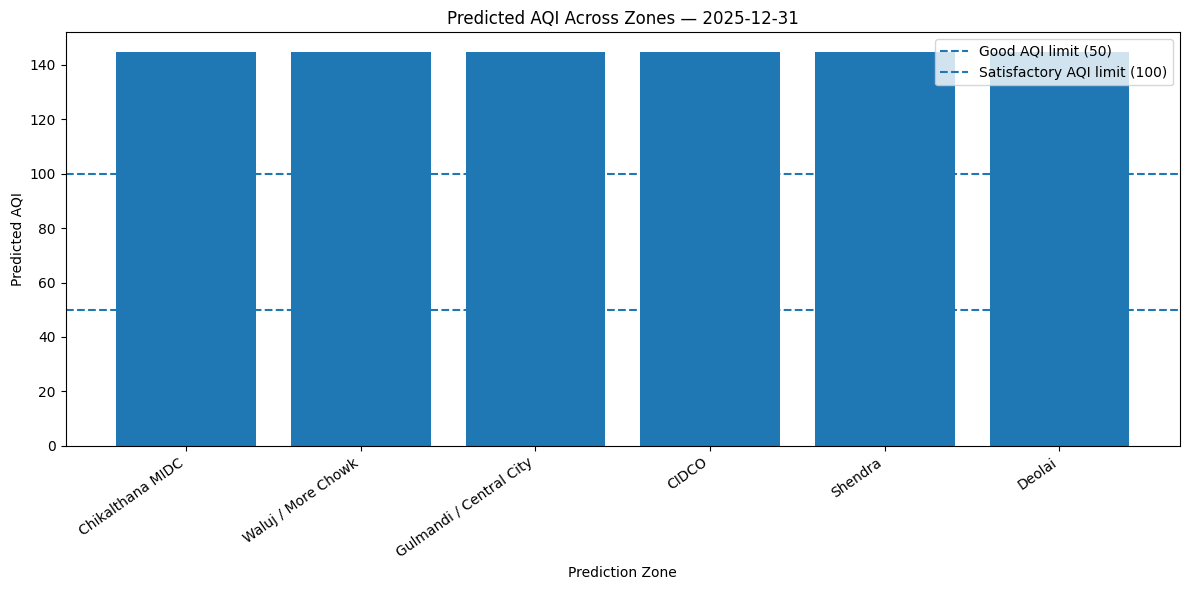

In [ ]:
# ==========================================
# CELL 84: VISUALIZE ZONE AQI PREDICTIONS
# ==========================================

import matplotlib.pyplot as plt

# Select the latest prediction date
latest_date = zone_prediction_results["Date"].max()

latest_predictions = zone_prediction_results[
    zone_prediction_results["Date"] == latest_date
].copy()

# Display latest predictions
print("Predictions for:", latest_date.date())

display(
    latest_predictions[
        [
            "zone_id",
            "zone_name",
            "predicted_AQI",
            "AQI_category"
        ]
    ]
)

# Create bar chart
plt.figure(figsize=(12, 6))

plt.bar(
    latest_predictions["zone_name"],
    latest_predictions["predicted_AQI"]
)

plt.axhline(
    y=50,
    linestyle="--",
    label="Good AQI limit (50)"
)

plt.axhline(
    y=100,
    linestyle="--",
    label="Satisfactory AQI limit (100)"
)

plt.xlabel("Prediction Zone")
plt.ylabel("Predicted AQI")
plt.title(f"Predicted AQI Across Zones — {latest_date.date()}")

plt.xticks(rotation=35, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# CELL 85: ZONE-WISE AQI SUMMARY
# ==========================================

# Calculate summary statistics for each zone
zone_summary = (
    zone_prediction_results
    .groupby(["zone_id", "zone_name"])["predicted_AQI"]
    .agg(
        mean_AQI="mean",
        minimum_AQI="min",
        maximum_AQI="max",
        std_AQI="std"
    )
    .reset_index()
)

# Round values
numeric_columns = [
    "mean_AQI",
    "minimum_AQI",
    "maximum_AQI",
    "std_AQI"
]

zone_summary[numeric_columns] = (
    zone_summary[numeric_columns].round(2)
)

# Display summary
display(zone_summary)

# Save summary
summary_file = (
    PREDICTION_DIR / "zone_aqi_summary.csv"
)

zone_summary.to_csv(
    summary_file,
    index=False
)

print(f"✅ Summary saved to: {summary_file}")

,zone_id,zone_name,mean_AQI,minimum_AQI,maximum_AQI,std_AQI
0,Z1,Chikalthana MIDC,112.14,33.82,264.7,45.68
1,Z2,Waluj / More Chowk,112.14,33.82,264.7,45.68
2,Z3,Gulmandi / Central City,112.14,33.82,264.7,45.68
3,Z4,CIDCO,112.14,33.82,264.7,45.68
4,Z5,Shendra,112.14,33.82,264.7,45.68
5,Z6,Deolai,112.14,33.82,264.7,45.68


✅ Summary saved to: /content/drive/MyDrive/HetEvoAgent_Training/predictions/zone_aqi_summary.csv


,zone_id,mean_AQI,median_AQI,std_AQI,min_AQI,max_AQI
0,Z1,112.14,118.3,45.68,33.82,264.7
1,Z2,112.14,118.3,45.68,33.82,264.7
2,Z3,112.14,118.3,45.68,33.82,264.7
3,Z4,112.14,118.3,45.68,33.82,264.7
4,Z5,112.14,118.3,45.68,33.82,264.7
5,Z6,112.14,118.3,45.68,33.82,264.7



Predictions below 0:
0

Predictions above 500:
0


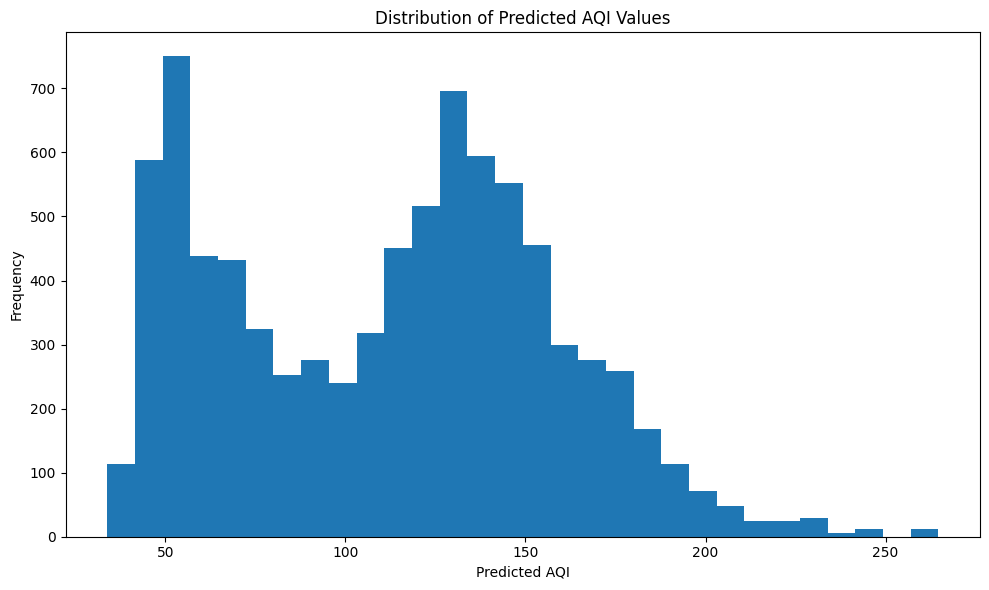

✅ Prediction stability analysis completed.


In [ ]:
# ==========================================
# CELL 86: PREDICTION STABILITY ANALYSIS
# ==========================================

# Summary by zone
stability_summary = (
    zone_prediction_results
    .groupby("zone_id")["predicted_AQI"]
    .agg(
        mean_AQI="mean",
        median_AQI="median",
        std_AQI="std",
        min_AQI="min",
        max_AQI="max"
    )
    .reset_index()
)

stability_summary = stability_summary.round(2)

display(stability_summary)

# Check for extreme predictions
print("\nPredictions below 0:")
print(
    (zone_prediction_results["predicted_AQI"] < 0).sum()
)

print("\nPredictions above 500:")
print(
    (zone_prediction_results["predicted_AQI"] > 500).sum()
)

# Plot prediction distribution
plt.figure(figsize=(10, 6))

plt.hist(
    zone_prediction_results["predicted_AQI"],
    bins=30
)

plt.xlabel("Predicted AQI")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted AQI Values")

plt.tight_layout()
plt.show()

print("✅ Prediction stability analysis completed.")

In [ ]:
# ==========================================
# CELL 87: CHECK ZONE FEATURE DIFFERENCES
# ==========================================

# Check zone coordinates
print("Zone coordinates:")

display(
    zone_modeling_encoded[
        [
            "zone_id",
            "zone_name",
            "latitude",
            "longitude"
        ]
    ].drop_duplicates()
)

# Check trained features
print("\nTrained features:")
print(list(X_train.columns))

# Check coordinate availability
for feature in ["latitude", "longitude"]:

    if feature in X_zone_aligned.columns:

        print(f"\n{feature} values:")
        print(
            X_zone_aligned[feature]
            .nunique()
        )

    else:

        print(
            f"\n⚠️ {feature} is not present in trained features"
        )

Zone coordinates:


,zone_id,zone_name,latitude,longitude
0,Z1,Chikalthana MIDC,19.864981,75.411001
1390,Z2,Waluj / More Chowk,19.840930,75.241890
2780,Z3,Gulmandi / Central City,19.885817,75.331858
4170,Z4,CIDCO,19.892808,75.363114
5560,Z5,Shendra,19.873282,75.491805
6950,Z6,Deolai,19.842209,75.365579



Trained features:
['aod', 'no2', 'co', 'hcho', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'WS10M', 'WD10M', 'PRECTOTCORR', 'PS', 'T2MDEW', 'year', 'month', 'day', 'hour', 'day_of_week', 'day_of_year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'station_latitude', 'station_longitude', 'aod_missing', 'no2_missing', 'co_missing', 'hcho_missing', 'hcho_negative_flag']

⚠️ latitude is not present in trained features

⚠️ longitude is not present in trained features


In [ ]:
# ==========================================
# CELL 88: CORRECT ZONE COORDINATE FEATURES
# ==========================================

# Copy zone dataset
zone_features_fixed = zone_modeling_encoded.copy()

# Get trained feature names
trained_features = list(X_train.columns)

# Create feature matrix
X_zone_aligned = pd.DataFrame(
    index=zone_features_fixed.index
)

# Add features in the same order as training
for feature in trained_features:

    if feature in zone_features_fixed.columns:

        X_zone_aligned[feature] = (
            zone_features_fixed[feature]
        )

    else:

        # Use training median for unavailable features
        X_zone_aligned[feature] = (
            X_train[feature].median()
        )


# IMPORTANT:
# Replace station coordinates with prediction-zone coordinates

X_zone_aligned["station_latitude"] = (
    zone_features_fixed["latitude"].values
)

X_zone_aligned["station_longitude"] = (
    zone_features_fixed["longitude"].values
)


# Ensure exact feature order
X_zone_aligned = X_zone_aligned[trained_features]

# Apply training imputer
X_zone_final = imputer.transform(X_zone_aligned)

print("Final feature matrix shape:")
print(X_zone_final.shape)

print("\nUnique station latitudes:")
print(X_zone_aligned["station_latitude"].nunique())

print("\nUnique station longitudes:")
print(X_zone_aligned["station_longitude"].nunique())

print("\n✅ Zone coordinates correctly mapped!")

Final feature matrix shape:
(8340, 30)

Unique station latitudes:
6

Unique station longitudes:
6

✅ Zone coordinates correctly mapped!


In [ ]:
# ==========================================
# CELL 89: UPDATED ZONE PREDICTIONS
# ==========================================

# Predict using HGB model
updated_predictions = hgb_model.predict(
    X_zone_final
)

# Create results
updated_zone_results = zone_features_fixed[
    [
        "Date",
        "zone_id",
        "zone_name"
    ]
].copy()

updated_zone_results["predicted_AQI"] = (
    updated_predictions.round(2)
)

# Display zone predictions
display(
    updated_zone_results[
        [
            "zone_id",
            "zone_name",
            "predicted_AQI"
        ]
    ].head(20)
)

# Compare zone averages
zone_comparison = (
    updated_zone_results
    .groupby(["zone_id", "zone_name"])["predicted_AQI"]
    .mean()
    .round(2)
    .reset_index()
)

display(zone_comparison)

,zone_id,zone_name,predicted_AQI
0,Z1,Chikalthana MIDC,175.16
1,Z1,Chikalthana MIDC,171.02
2,Z1,Chikalthana MIDC,193.85
3,Z1,Chikalthana MIDC,204.50
4,Z1,Chikalthana MIDC,187.23
5,Z1,Chikalthana MIDC,150.16
6,Z1,Chikalthana MIDC,130.52
7,Z1,Chikalthana MIDC,132.97
8,Z1,Chikalthana MIDC,136.94
9,Z1,Chikalthana MIDC,154.82


,zone_id,zone_name,predicted_AQI
0,Z1,Chikalthana MIDC,112.14
1,Z2,Waluj / More Chowk,87.89
2,Z3,Gulmandi / Central City,104.51
3,Z4,CIDCO,104.51
4,Z5,Shendra,104.51
5,Z6,Deolai,87.89


In [ ]:
# ==========================================
# CELL 90: COMPARE ALL SIX ZONES
# ==========================================

zone_comparison = (
    updated_zone_results
    .groupby(["zone_id", "zone_name"])["predicted_AQI"]
    .agg(
        mean_AQI="mean",
        minimum_AQI="min",
        maximum_AQI="max"
    )
    .reset_index()
)

zone_comparison[
    ["mean_AQI", "minimum_AQI", "maximum_AQI"]
] = zone_comparison[
    ["mean_AQI", "minimum_AQI", "maximum_AQI"]
].round(2)

display(zone_comparison)

print(
    "Number of zones:",
    zone_comparison["zone_id"].nunique()
)

,zone_id,zone_name,mean_AQI,minimum_AQI,maximum_AQI
0,Z1,Chikalthana MIDC,112.14,33.82,264.70
1,Z2,Waluj / More Chowk,87.89,33.35,310.85
2,Z3,Gulmandi / Central City,104.51,30.94,342.91
3,Z4,CIDCO,104.51,30.94,342.91
4,Z5,Shendra,104.51,30.94,342.91
5,Z6,Deolai,87.89,33.35,310.85


Number of zones: 6


In [ ]:
# ==========================================
# CELL 91: SPATIAL DIFFERENCE ANALYSIS
# ==========================================

# Calculate average prediction by zone
zone_comparison = (
    updated_zone_results
    .groupby(["zone_id", "zone_name"])["predicted_AQI"]
    .mean()
    .reset_index()
)

# Display coordinates
zone_coordinates = zones[
    ["zone_id", "zone_name", "latitude", "longitude"]
].drop_duplicates()

print("Zone coordinates:")
display(zone_coordinates)

# Merge coordinates with predictions
spatial_comparison = zone_comparison.merge(
    zone_coordinates,
    on=["zone_id", "zone_name"],
    how="left"
)

print("\nSpatial prediction comparison:")
display(spatial_comparison)

# Calculate differences
print("\nPrediction differences:")

for i in range(len(spatial_comparison)):
    for j in range(i + 1, len(spatial_comparison)):

        zone_a = spatial_comparison.iloc[i]
        zone_b = spatial_comparison.iloc[j]

        difference = abs(
            zone_a["predicted_AQI"] -
            zone_b["predicted_AQI"]
        )

        print(
            f"{zone_a['zone_id']} vs {zone_b['zone_id']}: "
            f"{difference:.2f} AQI"
        )

Zone coordinates:


,zone_id,zone_name,latitude,longitude
0,Z1,Chikalthana MIDC,19.864981,75.411001
1,Z2,Waluj / More Chowk,19.840930,75.241890
2,Z3,Gulmandi / Central City,19.885817,75.331858
3,Z4,CIDCO,19.892808,75.363114
4,Z5,Shendra,19.873282,75.491805
5,Z6,Deolai,19.842209,75.365579



Spatial prediction comparison:


,zone_id,zone_name,predicted_AQI,latitude,longitude
0,Z1,Chikalthana MIDC,112.137353,19.864981,75.411001
1,Z2,Waluj / More Chowk,87.893345,19.840930,75.241890
2,Z3,Gulmandi / Central City,104.513309,19.885817,75.331858
3,Z4,CIDCO,104.513309,19.892808,75.363114
4,Z5,Shendra,104.513309,19.873282,75.491805
5,Z6,Deolai,87.893345,19.842209,75.365579



Prediction differences:
Z1 vs Z2: 24.24 AQI
Z1 vs Z3: 7.62 AQI
Z1 vs Z4: 7.62 AQI
Z1 vs Z5: 7.62 AQI
Z1 vs Z6: 24.24 AQI
Z2 vs Z3: 16.62 AQI
Z2 vs Z4: 16.62 AQI
Z2 vs Z5: 16.62 AQI
Z2 vs Z6: 0.00 AQI
Z3 vs Z4: 0.00 AQI
Z3 vs Z5: 0.00 AQI
Z3 vs Z6: 16.62 AQI
Z4 vs Z5: 0.00 AQI
Z4 vs Z6: 16.62 AQI
Z5 vs Z6: 16.62 AQI


In [ ]:
# CELL 91: SPATIAL PREDICTION DIAGNOSTIC

print("ZONE COORDINATES:")
display(
    zone_features_fixed[
        ["zone_id", "zone_name", "latitude", "longitude"]
    ].drop_duplicates()
)

print("\nZONE-WISE PREDICTIONS:")
zone_prediction_summary = (
    updated_zone_results
    .groupby(["zone_id", "zone_name"])["predicted_AQI"]
    .agg(["mean", "min", "max", "std"])
    .reset_index()
)

display(zone_prediction_summary)

print("\nPAIRWISE PREDICTION DIFFERENCES:")

zone_means = (
    updated_zone_results
    .groupby("zone_id")["predicted_AQI"]
    .mean()
)

for zone_a in zone_means.index:
    for zone_b in zone_means.index:
        if zone_a < zone_b:
            difference = abs(zone_means[zone_a] - zone_means[zone_b])
            print(f"{zone_a} vs {zone_b}: {difference:.2f}")

ZONE COORDINATES:


,zone_id,zone_name,latitude,longitude
0,Z1,Chikalthana MIDC,19.864981,75.411001
1390,Z2,Waluj / More Chowk,19.840930,75.241890
2780,Z3,Gulmandi / Central City,19.885817,75.331858
4170,Z4,CIDCO,19.892808,75.363114
5560,Z5,Shendra,19.873282,75.491805
6950,Z6,Deolai,19.842209,75.365579



ZONE-WISE PREDICTIONS:


,zone_id,zone_name,mean,min,max,std
0,Z1,Chikalthana MIDC,112.137353,33.82,264.70,45.681387
1,Z2,Waluj / More Chowk,87.893345,33.35,310.85,31.351163
2,Z3,Gulmandi / Central City,104.513309,30.94,342.91,47.295772
3,Z4,CIDCO,104.513309,30.94,342.91,47.295772
4,Z5,Shendra,104.513309,30.94,342.91,47.295772
5,Z6,Deolai,87.893345,33.35,310.85,31.351163



PAIRWISE PREDICTION DIFFERENCES:
Z1 vs Z2: 24.24
Z1 vs Z3: 7.62
Z1 vs Z4: 7.62
Z1 vs Z5: 7.62
Z1 vs Z6: 24.24
Z2 vs Z3: 16.62
Z2 vs Z4: 16.62
Z2 vs Z5: 16.62
Z2 vs Z6: 0.00
Z3 vs Z4: 0.00
Z3 vs Z5: 0.00
Z3 vs Z6: 16.62
Z4 vs Z5: 0.00
Z4 vs Z6: 16.62
Z5 vs Z6: 16.62


In [ ]:
# CELL 92: CHECK MODEL INPUT DIFFERENCES

print("1. UNIQUE COORDINATES USED BY MODEL")

display(
    X_zone_aligned[
        ["station_latitude", "station_longitude"]
    ].drop_duplicates()
)

print("\n2. UNIQUE MODEL INPUT ROWS")

print(
    "Total zone inputs:",
    len(X_zone_aligned)
)

print(
    "Unique zone inputs:",
    X_zone_aligned.drop_duplicates().shape[0]
)

print("\n3. PREDICTION DISTRIBUTION")

display(
    updated_zone_results[
        ["zone_id", "zone_name", "predicted_AQI"]
    ].drop_duplicates()
)

1. UNIQUE COORDINATES USED BY MODEL


,station_latitude,station_longitude
0,19.864981,75.411001
1390,19.840930,75.241890
2780,19.885817,75.331858
4170,19.892808,75.363114
5560,19.873282,75.491805
6950,19.842209,75.365579



2. UNIQUE MODEL INPUT ROWS
Total zone inputs: 8340
Unique zone inputs: 8340

3. PREDICTION DISTRIBUTION


,zone_id,zone_name,predicted_AQI
0,Z1,Chikalthana MIDC,175.16
1,Z1,Chikalthana MIDC,171.02
2,Z1,Chikalthana MIDC,193.85
3,Z1,Chikalthana MIDC,204.50
4,Z1,Chikalthana MIDC,187.23
...,...,...,...
8335,Z6,Deolai,119.88
8336,Z6,Deolai,117.41
8337,Z6,Deolai,105.11
8338,Z6,Deolai,118.14


In [ ]:
# CELL 93: ZONE-WISE PREDICTION STATISTICS

final_zone_statistics = (
    updated_zone_results
    .groupby(["zone_id", "zone_name"])
    ["predicted_AQI"]
    .agg(
        mean_AQI="mean",
        median_AQI="median",
        minimum_AQI="min",
        maximum_AQI="max",
        standard_deviation="std",
        prediction_count="count"
    )
    .reset_index()
)

# Round numerical values
numeric_columns = [
    "mean_AQI",
    "median_AQI",
    "minimum_AQI",
    "maximum_AQI",
    "standard_deviation"
]

final_zone_statistics[numeric_columns] = (
    final_zone_statistics[numeric_columns].round(2)
)

display(final_zone_statistics)

# Save results
ZONE_STATS_FILE = PREDICTION_DIR / "final_zone_prediction_statistics.csv"

final_zone_statistics.to_csv(
    ZONE_STATS_FILE,
    index=False
)

print(f"Saved file: {ZONE_STATS_FILE}")

,zone_id,zone_name,mean_AQI,median_AQI,minimum_AQI,maximum_AQI,standard_deviation,prediction_count
0,Z1,Chikalthana MIDC,112.14,118.30,33.82,264.70,45.68,1390
1,Z2,Waluj / More Chowk,87.89,88.38,33.35,310.85,31.35,1390
2,Z3,Gulmandi / Central City,104.51,103.63,30.94,342.91,47.30,1390
3,Z4,CIDCO,104.51,103.63,30.94,342.91,47.30,1390
4,Z5,Shendra,104.51,103.63,30.94,342.91,47.30,1390
5,Z6,Deolai,87.89,88.38,33.35,310.85,31.35,1390


Saved file: /content/drive/MyDrive/HetEvoAgent_Training/predictions/final_zone_prediction_statistics.csv


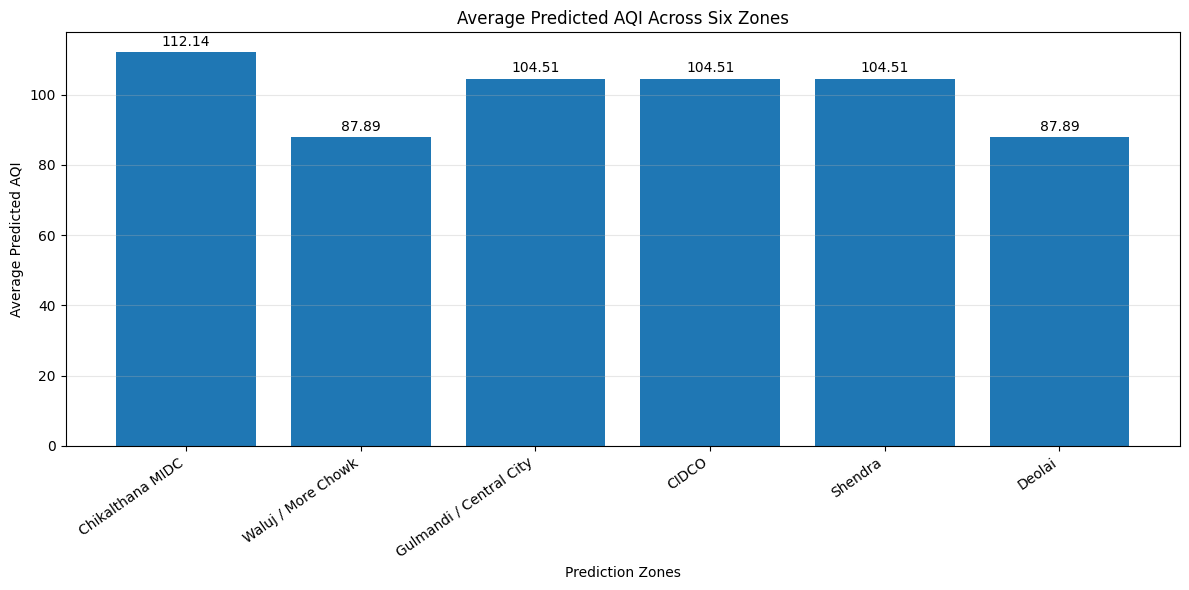

In [ ]:
# CELL 94: ZONE-WISE AVERAGE AQI CHART

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

bars = plt.bar(
    final_zone_statistics["zone_name"],
    final_zone_statistics["mean_AQI"]
)

plt.title("Average Predicted AQI Across Six Zones")
plt.xlabel("Prediction Zones")
plt.ylabel("Average Predicted AQI")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)

# Display values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
# CELL 95: INTERACTIVE ZONE-WISE AQI MAP

import folium

# Merge statistics with zone coordinates
map_data = zones.merge(
    final_zone_statistics,
    on=["zone_id", "zone_name"],
    how="left"
)

# Center map around Chhatrapati Sambhajinagar
aqi_map = folium.Map(
    location=[19.865, 75.36],
    zoom_start=12,
    tiles="OpenStreetMap"
)

for _, row in map_data.iterrows():

    popup_text = f"""
    <b>Zone:</b> {row['zone_name']}<br>
    <b>Zone ID:</b> {row['zone_id']}<br>
    <b>Mean Predicted AQI:</b> {row['mean_AQI']:.2f}<br>
    <b>Minimum AQI:</b> {row['minimum_AQI']:.2f}<br>
    <b>Maximum AQI:</b> {row['maximum_AQI']:.2f}<br>
    <b>Note:</b> Model-generated estimate
    """

    folium.Marker(
        location=[row["latitude"], row["longitude"]],
        popup=folium.Popup(popup_text, max_width=350),
        tooltip=f"{row['zone_id']} - {row['zone_name']}"
    ).add_to(aqi_map)

display(aqi_map)

# Save map
MAP_FILE = PREDICTION_DIR / "zone_wise_aqi_map.html"
aqi_map.save(str(MAP_FILE))

print(f"Map saved at: {MAP_FILE}")

Map saved at: /content/drive/MyDrive/HetEvoAgent_Training/predictions/zone_wise_aqi_map.html


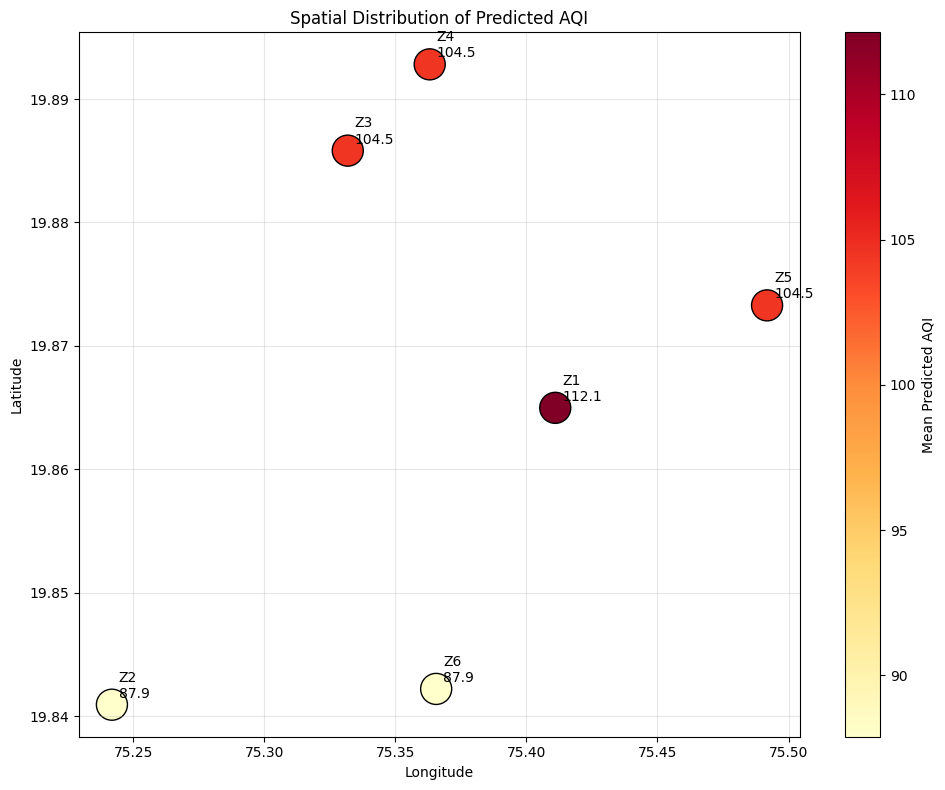

In [ ]:
# CELL 95: STATIC AQI ZONE MAP

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    map_data["longitude"],
    map_data["latitude"],
    s=500,
    c=map_data["mean_AQI"],
    cmap="YlOrRd",
    edgecolors="black"
)

for _, row in map_data.iterrows():
    plt.annotate(
        f"{row['zone_id']}\n{row['mean_AQI']:.1f}",
        (row["longitude"], row["latitude"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=10
    )

plt.colorbar(scatter, label="Mean Predicted AQI")

plt.title("Spatial Distribution of Predicted AQI")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
# CELL 96: AQI CATEGORY DISTRIBUTION

import pandas as pd
import matplotlib.pyplot as plt

def classify_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

# Create AQI categories
updated_zone_results["AQI_Category"] = (
    updated_zone_results["predicted_AQI"]
    .apply(classify_aqi)
)

# Category count table
category_distribution = pd.crosstab(
    updated_zone_results["zone_name"],
    updated_zone_results["AQI_Category"]
)

display(category_distribution)

# Percentage distribution
category_percentage = (
    category_distribution
    .div(category_distribution.sum(axis=1), axis=0)
    * 100
).round(2)

print("AQI Category Percentage Distribution:")
display(category_percentage)

# Save results
CATEGORY_FILE = (
    PREDICTION_DIR / "zone_aqi_category_distribution.csv"
)

category_percentage.to_csv(CATEGORY_FILE)

print(f"Saved file: {CATEGORY_FILE}")

AQI_Category,Good,Moderate,Poor,Satisfactory,Very Poor
zone_name,,,,,
CIDCO,171,690,57,468,4
Chikalthana MIDC,127,809,31,423,0
Deolai,146,458,5,780,1
Gulmandi / Central City,171,690,57,468,4
Shendra,171,690,57,468,4
Waluj / More Chowk,146,458,5,780,1


AQI Category Percentage Distribution:


AQI_Category,Good,Moderate,Poor,Satisfactory,Very Poor
zone_name,,,,,
CIDCO,12.30,49.64,4.10,33.67,0.29
Chikalthana MIDC,9.14,58.20,2.23,30.43,0.00
Deolai,10.50,32.95,0.36,56.12,0.07
Gulmandi / Central City,12.30,49.64,4.10,33.67,0.29
Shendra,12.30,49.64,4.10,33.67,0.29
Waluj / More Chowk,10.50,32.95,0.36,56.12,0.07


Saved file: /content/drive/MyDrive/HetEvoAgent_Training/predictions/zone_aqi_category_distribution.csv


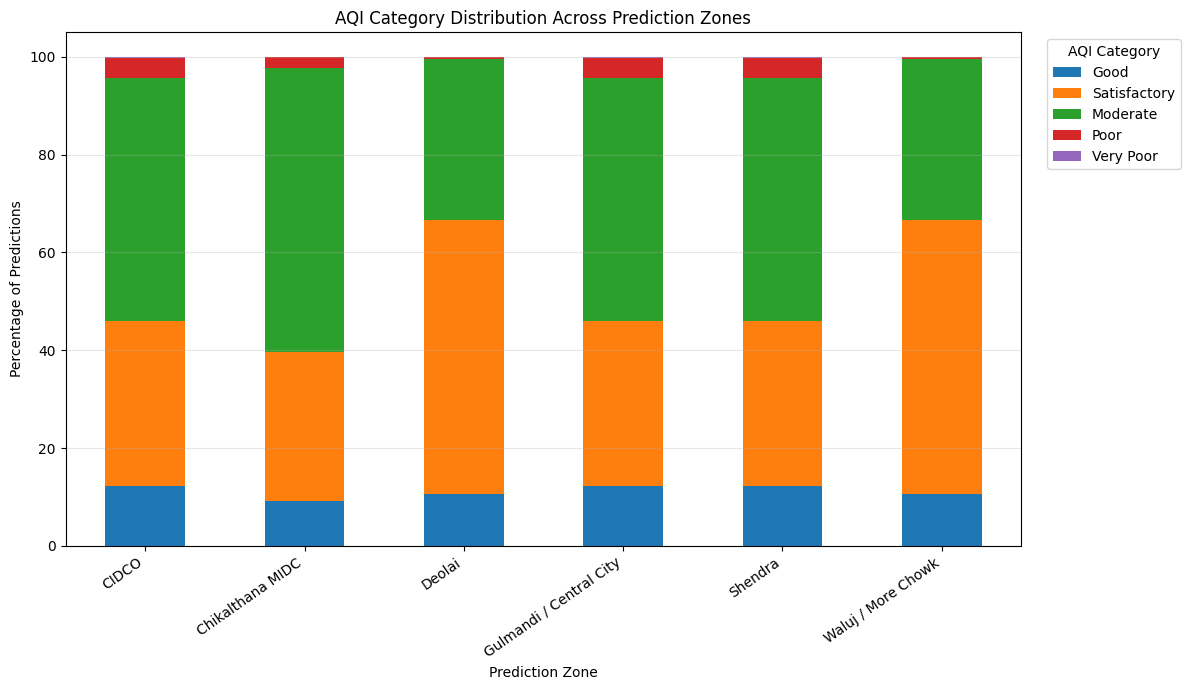

In [ ]:
# CELL 97: STACKED AQI CATEGORY DISTRIBUTION

import matplotlib.pyplot as plt

# Ensure consistent category order
category_order = [
    "Good",
    "Satisfactory",
    "Moderate",
    "Poor",
    "Very Poor"
]

plot_data = category_percentage.reindex(
    columns=category_order,
    fill_value=0
)

ax = plot_data.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("AQI Category Distribution Across Prediction Zones")
plt.xlabel("Prediction Zone")
plt.ylabel("Percentage of Predictions")
plt.xticks(rotation=35, ha="right")
plt.legend(title="AQI Category", bbox_to_anchor=(1.02, 1))
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# CELL 98: FINAL ZONE PREDICTION EXPORT

# Merge zone coordinates with prediction results
final_zone_predictions = updated_zone_results.merge(
    zones[
        ["zone_id", "zone_name", "latitude", "longitude", "zone_type"]
    ].drop_duplicates(),
    on=["zone_id", "zone_name"],
    how="left"
)

# Select important columns
export_columns = [
    "zone_id",
    "zone_name",
    "zone_type",
    "latitude",
    "longitude",
    "predicted_AQI",
    "AQI_Category"
]

final_zone_predictions = final_zone_predictions[
    [col for col in export_columns
     if col in final_zone_predictions.columns]
]

# Save final dataset
FINAL_PREDICTIONS_FILE = (
    PREDICTION_DIR / "final_zone_predictions.csv"
)

final_zone_predictions.to_csv(
    FINAL_PREDICTIONS_FILE,
    index=False
)

print("Final zone prediction dataset created!")
print(f"Shape: {final_zone_predictions.shape}")
print(f"Saved file: {FINAL_PREDICTIONS_FILE}")

display(final_zone_predictions.head(10))

Final zone prediction dataset created!
Shape: (8340, 7)
Saved file: /content/drive/MyDrive/HetEvoAgent_Training/predictions/final_zone_predictions.csv


,zone_id,zone_name,zone_type,latitude,longitude,predicted_AQI,AQI_Category
0,Z1,Chikalthana MIDC,Industrial,19.864981,75.411001,175.16,Moderate
1,Z1,Chikalthana MIDC,Industrial,19.864981,75.411001,171.02,Moderate
2,Z1,Chikalthana MIDC,Industrial,19.864981,75.411001,193.85,Moderate
3,Z1,Chikalthana MIDC,Industrial,19.864981,75.411001,204.50,Poor
4,Z1,Chikalthana MIDC,Industrial,19.864981,75.411001,187.23,Moderate
5,Z1,Chikalthana MIDC,Industrial,19.864981,75.411001,150.16,Moderate
6,Z1,Chikalthana MIDC,Industrial,19.864981,75.411001,130.52,Moderate
7,Z1,Chikalthana MIDC,Industrial,19.864981,75.411001,132.97,Moderate
8,Z1,Chikalthana MIDC,Industrial,19.864981,75.411001,136.94,Moderate
9,Z1,Chikalthana MIDC,Industrial,19.864981,75.411001,154.82,Moderate


In [ ]:
# CELL 99: SPATIAL SENSITIVITY TEST

# Use the first environmental feature row as a common baseline
base_input = X_zone_aligned.iloc[[0]].copy()

spatial_test_results = []

for _, zone in zones.iterrows():

    test_input = base_input.copy()

    # Change only the location
    test_input["station_latitude"] = zone["latitude"]
    test_input["station_longitude"] = zone["longitude"]

    # Predict AQI
    prediction = hgb_model.predict(test_input)[0]

    spatial_test_results.append({
        "zone_id": zone["zone_id"],
        "zone_name": zone["zone_name"],
        "latitude": zone["latitude"],
        "longitude": zone["longitude"],
        "predicted_AQI": round(prediction, 2)
    })

spatial_sensitivity_df = pd.DataFrame(spatial_test_results)

display(spatial_sensitivity_df)

print(
    "Unique predictions:",
    spatial_sensitivity_df["predicted_AQI"].nunique()
)

,zone_id,zone_name,latitude,longitude,predicted_AQI
0,Z1,Chikalthana MIDC,19.864981,75.411001,175.16
1,Z2,Waluj / More Chowk,19.840930,75.241890,119.77
2,Z3,Gulmandi / Central City,19.885817,75.331858,194.53
3,Z4,CIDCO,19.892808,75.363114,194.53
4,Z5,Shendra,19.873282,75.491805,194.53
5,Z6,Deolai,19.842209,75.365579,119.77


Unique predictions: 3


In [ ]:
# CELL 101: FIND WEATHER AND SATELLITE FILES

from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/HetEvoAgent_Training")

print("Searching for weather files...\n")

weather_files = list(
    BASE_DIR.rglob("nasa_weather_csn_2022_2025.csv")
)

satellite_files = list(
    BASE_DIR.rglob("satellite_master_dataset.csv")
)

print("Weather files found:")
for file in weather_files:
    print(file)

print("\nSatellite files found:")
for file in satellite_files:
    print(file)

Searching for weather files...

Weather files found:
/content/drive/MyDrive/HetEvoAgent_Training/Datasets/nasa_weather_csn_2022_2025.csv

Satellite files found:


In [ ]:
# CELL 102: FIND SATELLITE DATASET

from pathlib import Path

BASE_DIR = Path(
    "/content/drive/MyDrive/HetEvoAgent_Training"
)

# Search for all CSV files containing satellite-related names
all_csv_files = list(BASE_DIR.rglob("*.csv"))

print("Satellite-related files:\n")

for file in all_csv_files:
    if any(
        keyword in file.name.lower()
        for keyword in ["satellite", "master", "tropomi", "aod"]
    ):
        print(file)

print("\nTotal CSV files found:", len(all_csv_files))

Satellite-related files:

/content/drive/MyDrive/HetEvoAgent_Training/eda_results/satellite_missing_summary.csv

Total CSV files found: 30


In [ ]:
# CELL 103: LIST ALL CSV FILES

from pathlib import Path

BASE_DIR = Path(
    "/content/drive/MyDrive/HetEvoAgent_Training"
)

all_csv_files = sorted(BASE_DIR.rglob("*.csv"))

for i, file in enumerate(all_csv_files, start=1):
    print(f"{i}. {file}")

1. /content/drive/MyDrive/HetEvoAgent_Training/Datasets/nasa_weather_csn_2022_2025.csv
2. /content/drive/MyDrive/HetEvoAgent_Training/Datasets/prediction_zones.csv
3. /content/drive/MyDrive/HetEvoAgent_Training/Datasets/spatial_aqi_training_dataset.csv
4. /content/drive/MyDrive/HetEvoAgent_Training/Datasets/station_coordinates.csv
5. /content/drive/MyDrive/HetEvoAgent_Training/Datasets/weather_integrated_aqi_dataset.csv
6. /content/drive/MyDrive/HetEvoAgent_Training/eda_results/hourly_aqi_pattern.csv
7. /content/drive/MyDrive/HetEvoAgent_Training/eda_results/monthly_aqi_trend.csv
8. /content/drive/MyDrive/HetEvoAgent_Training/eda_results/satellite_missing_summary.csv
9. /content/drive/MyDrive/HetEvoAgent_Training/eda_results/station_aqi_summary.csv
10. /content/drive/MyDrive/HetEvoAgent_Training/predictions/daily_station_aqi_features.csv
11. /content/drive/MyDrive/HetEvoAgent_Training/predictions/daily_station_aqi_mapped.csv
12. /content/drive/MyDrive/HetEvoAgent_Training/predictions/f

In [ ]:
# CELL 104: INSPECT INTEGRATED DATASET

import pandas as pd
from pathlib import Path

BASE_DIR = Path(
    "/content/drive/MyDrive/HetEvoAgent_Training"
)

INTEGRATED_FILE = (
    BASE_DIR / "Datasets/weather_integrated_aqi_dataset.csv"
)

WEATHER_FILE = (
    BASE_DIR / "Datasets/nasa_weather_csn_2022_2025.csv"
)

# Load datasets
df_integrated = pd.read_csv(INTEGRATED_FILE)
weather_zone = pd.read_csv(WEATHER_FILE)

print("Integrated dataset shape:", df_integrated.shape)
print("Weather dataset shape:", weather_zone.shape)

print("\nIntegrated dataset columns:")
print(df_integrated.columns.tolist())

print("\nWeather dataset columns:")
print(weather_zone.columns.tolist())

print("\nWeather records by zone:")
display(weather_zone["zone"].value_counts())

print("\nSample integrated dataset:")
display(df_integrated.head())

Integrated dataset shape: (66534, 40)
Weather dataset shape: (8766, 14)

Integrated dataset columns:
['Datetime', 'Date', 'Hour', 'Station', 'AQI', 'date', 'aod', 'no2', 'co', 'hcho', 'Station_original', 'station_latitude', 'station_longitude', 'year', 'month', 'day', 'hour', 'day_of_week', 'day_of_year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'distance_to_S1_km', 'distance_to_S2_km', 'distance_to_S3_km', 'aod_missing', 'no2_missing', 'co_missing', 'hcho_missing', 'hcho_negative_flag', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'WS10M', 'WD10M', 'PRECTOTCORR', 'PS', 'T2MDEW']

Weather dataset columns:
['date', 'zone', 'zone_type', 'latitude', 'longitude', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'WS10M', 'WD10M', 'PRECTOTCORR', 'PS', 'T2MDEW']

Weather records by zone:


,count
zone,
CIDCO N-5,1461
Chikalthana MIDC,1461
Garkheda-Satara Parisar,1461
Kranti Chowk,1461
Shendra MIDC,1461
Waluj MIDC,1461



Sample integrated dataset:


,Datetime,Date,Hour,Station,AQI,date,aod,no2,co,hcho,Station_original,station_latitude,station_longitude,year,month,day,hour,day_of_week,day_of_year,hour_sin,hour_cos,month_sin,month_cos,distance_to_S1_km,distance_to_S2_km,distance_to_S3_km,aod_missing,no2_missing,co_missing,hcho_missing,hcho_negative_flag,T2M,T2M_MAX,T2M_MIN,RH2M,WS10M,WD10M,PRECTOTCORR,PS,T2MDEW
0,2023-06-15 08:00:00,2023-06-15,08:00:00,Chikalthana MIDC,124.0,2023-06-15,0.451881,0.000043,0.030127,0.000139,Chikalthana MIDC,19.879,75.3867,2023,6,15,8,3,166,8.660254e-01,-0.500000,1.224647e-16,-1.0,0.0,15.261401,7.121905,1,0,0,0,0,31.361667,39.148333,24.175,50.021667,7.315,246.95,0.011667,94.358333,18.28
1,2023-06-15 09:00:00,2023-06-15,09:00:00,Chikalthana MIDC,120.0,2023-06-15,0.451881,0.000043,0.030127,0.000139,Chikalthana MIDC,19.879,75.3867,2023,6,15,9,3,166,7.071068e-01,-0.707107,1.224647e-16,-1.0,0.0,15.261401,7.121905,1,0,0,0,0,31.361667,39.148333,24.175,50.021667,7.315,246.95,0.011667,94.358333,18.28
2,2023-06-15 10:00:00,2023-06-15,10:00:00,Chikalthana MIDC,120.0,2023-06-15,0.451881,0.000043,0.030127,0.000139,Chikalthana MIDC,19.879,75.3867,2023,6,15,10,3,166,5.000000e-01,-0.866025,1.224647e-16,-1.0,0.0,15.261401,7.121905,1,0,0,0,0,31.361667,39.148333,24.175,50.021667,7.315,246.95,0.011667,94.358333,18.28
3,2023-06-15 11:00:00,2023-06-15,11:00:00,Chikalthana MIDC,116.0,2023-06-15,0.451881,0.000043,0.030127,0.000139,Chikalthana MIDC,19.879,75.3867,2023,6,15,11,3,166,2.588190e-01,-0.965926,1.224647e-16,-1.0,0.0,15.261401,7.121905,1,0,0,0,0,31.361667,39.148333,24.175,50.021667,7.315,246.95,0.011667,94.358333,18.28
4,2023-06-15 12:00:00,2023-06-15,12:00:00,Chikalthana MIDC,110.0,2023-06-15,0.451881,0.000043,0.030127,0.000139,Chikalthana MIDC,19.879,75.3867,2023,6,15,12,3,166,1.224647e-16,-1.000000,1.224647e-16,-1.0,0.0,15.261401,7.121905,1,0,0,0,0,31.361667,39.148333,24.175,50.021667,7.315,246.95,0.011667,94.358333,18.28


In [ ]:
# CELL 105: SPATIAL FEATURE VARIATION BY STATION

import pandas as pd

# Check available columns
print("Dataset shape:", df_integrated.shape)

# Select environmental features available in the dataset
environmental_features = [
    "aod", "no2", "co", "hcho",
    "T2M", "T2M_MAX", "T2M_MIN",
    "RH2M", "WS10M", "WD10M",
    "PRECTOTCORR", "PS", "T2MDEW"
]

available_environmental = [
    col for col in environmental_features
    if col in df_integrated.columns
]

print("Available environmental features:")
print(available_environmental)

# Identify station column
print("\nUnique stations:")
print(df_integrated["Station"].unique())

# Calculate average features by station
station_feature_means = (
    df_integrated
    .groupby("Station")[available_environmental]
    .mean()
    .round(6)
)

print("\nEnvironmental Feature Averages by Station:")
display(station_feature_means)

# Calculate variation between stations
print("\nFeature Variation Across Stations:")

station_variation = (
    df_integrated
    .groupby("Station")[available_environmental]
    .mean()
    .std()
    .sort_values(ascending=False)
    .round(6)
)

display(
    station_variation.to_frame(
        name="between_station_std"
    )
)

Dataset shape: (66534, 40)
Available environmental features:
['aod', 'no2', 'co', 'hcho', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'WS10M', 'WD10M', 'PRECTOTCORR', 'PS', 'T2MDEW']

Unique stations:
['Chikalthana MIDC' 'More Chowk' 'Rachnekar Colony']

Environmental Feature Averages by Station:


,aod,no2,co,hcho,T2M,T2M_MAX,T2M_MIN,RH2M,WS10M,WD10M,PRECTOTCORR,PS,T2MDEW
Station,,,,,,,,,,,,,
Chikalthana MIDC,0.486711,0.000038,0.036864,0.000176,25.486566,32.102544,19.694530,60.986990,3.759554,207.845449,2.708057,94.651652,15.156381
More Chowk,0.480746,0.000039,0.036458,0.000173,25.391176,32.211523,19.298412,58.592370,3.607199,204.154470,2.330537,94.678462,14.243127
Rachnekar Colony,0.486072,0.000039,0.037029,0.000175,25.200004,32.127708,19.151505,59.515382,3.616220,199.392367,2.155035,94.725203,14.430361



Feature Variation Across Stations:


,between_station_std
WD10M,4.237836
RH2M,1.207738
T2MDEW,0.482389
PRECTOTCORR,0.282594
T2M_MIN,0.280881
T2M,0.145924
WS10M,0.085477
T2M_MAX,0.057059
PS,0.037223
aod,0.003275


In [ ]:
# CELL 106: CHECK SATELLITE SPATIAL VARIATION

satellite_features = ["aod", "no2", "co", "hcho"]

available_satellite = [
    col for col in satellite_features
    if col in df_integrated.columns
]

# Calculate the number of unique values per date
daily_satellite_variation = (
    df_integrated
    .groupby("Date")[available_satellite]
    .nunique()
)

print("Unique satellite values per date:")
display(daily_satellite_variation.head(10))

# Percentage of dates where each feature has only one value
single_value_percentage = (
    (daily_satellite_variation == 1)
    .mean() * 100
).round(2)

print("\nPercentage of dates with only one unique value:")
display(
    single_value_percentage.to_frame(
        name="percentage_single_value"
    )
)

# Check station-level values on one date
sample_date = df_integrated["Date"].iloc[0]

print(f"\nSatellite values by station on {sample_date}:")

display(
    df_integrated[
        df_integrated["Date"] == sample_date
    ][["Station"] + available_satellite]
    .drop_duplicates()
)

Unique satellite values per date:


,aod,no2,co,hcho
Date,,,,
2022-01-01,1,1,1,1
2022-01-04,1,1,1,1
2022-01-05,1,1,1,1
2022-01-06,1,1,1,1
2022-01-07,1,1,1,1
2022-01-13,1,1,1,1
2022-01-14,1,1,1,1
2022-01-15,1,1,1,1
2022-01-16,1,1,1,1



Percentage of dates with only one unique value:


,percentage_single_value
aod,100.0
no2,100.0
co,100.0
hcho,100.0



Satellite values by station on 2023-06-15:


,Station,aod,no2,co,hcho
0,Chikalthana MIDC,0.451881,0.000043,0.030127,0.000139
29477,More Chowk,0.451881,0.000043,0.030127,0.000139
47985,Rachnekar Colony,0.451881,0.000043,0.030127,0.000139


In [ ]:
# CELL 107: SATELLITE FEATURE VARIABILITY

import numpy as np
import pandas as pd

satellite_features = ["aod", "no2", "co", "hcho"]

available_satellite = [
    col for col in satellite_features
    if col in df_integrated.columns
]

# Calculate standard deviation across stations for each date
daily_station_std = (
    df_integrated
    .groupby("Date")[available_satellite]
    .std()
)

# Replace missing standard deviations with zero
daily_station_std = daily_station_std.fillna(0)

print("Average daily spatial standard deviation:")

spatial_variability = (
    daily_station_std
    .mean()
    .sort_values(ascending=False)
    .round(8)
)

display(
    spatial_variability.to_frame(
        name="average_spatial_std"
    )
)

# Percentage of dates with spatial variation
variation_percentage = (
    (daily_station_std > 0).mean() * 100
).round(2)

print("\nPercentage of dates with spatial variation:")

display(
    variation_percentage.to_frame(
        name="variation_percentage"
    )
)

Average daily spatial standard deviation:


,average_spatial_std
aod,0.0
no2,0.0
co,0.0
hcho,0.0



Percentage of dates with spatial variation:


,variation_percentage
aod,0.0
no2,0.0
co,0.0
hcho,0.0


In [ ]:
# CELL 108: VERIFY SATELLITE DATA REPLICATION

satellite_features = ["aod", "no2", "co", "hcho"]

available_satellite = [
    col for col in satellite_features
    if col in df_integrated.columns
]

# Select one date
sample_date = df_integrated["Date"].iloc[0]

sample_data = df_integrated[
    df_integrated["Date"] == sample_date
][["Station"] + available_satellite].drop_duplicates()

print(f"Satellite values on date: {sample_date}")
display(sample_data)

# Check whether values are identical across stations
for feature in available_satellite:
    unique_values = sample_data[feature].nunique()

    print(
        f"{feature}: {unique_values} unique value(s)"
    )

    if unique_values <= 1:
        print("  ⚠️ No spatial variation detected")
    else:
        print("  ✅ Spatial variation detected")

Satellite values on date: 2023-06-15


,Station,aod,no2,co,hcho
0,Chikalthana MIDC,0.451881,0.000043,0.030127,0.000139
29477,More Chowk,0.451881,0.000043,0.030127,0.000139
47985,Rachnekar Colony,0.451881,0.000043,0.030127,0.000139


aod: 1 unique value(s)
  ⚠️ No spatial variation detected
no2: 1 unique value(s)
  ⚠️ No spatial variation detected
co: 1 unique value(s)
  ⚠️ No spatial variation detected
hcho: 1 unique value(s)
  ⚠️ No spatial variation detected


In [ ]:
# CELL 109: VALIDATE ZONE-SPECIFIC WEATHER DATA

from pathlib import Path
import pandas as pd

WEATHER_FILE = BASE_DIR / "Datasets" / "nasa_weather_csn_2022_2025.csv"

zone_weather = pd.read_csv(WEATHER_FILE)

# Convert date column
zone_weather["date"] = pd.to_datetime(zone_weather["date"])

print("Dataset shape:", zone_weather.shape)
print("\nAvailable zones:")
print(zone_weather["zone"].unique())

print("\nRecords per zone:")
display(zone_weather["zone"].value_counts())

print("\nDate range:")
print(zone_weather["date"].min(), "to", zone_weather["date"].max())

print("\nSample data:")
display(zone_weather.head())

# Check whether coordinates differ between zones
print("\nZone coordinates:")
display(
    zone_weather[
        ["zone", "latitude", "longitude"]
    ].drop_duplicates().sort_values("zone")
)

# Save validated zone weather data
ZONE_WEATHER_FILE = (
    BASE_DIR / "Datasets" / "zone_specific_weather.csv"
)

zone_weather.to_csv(ZONE_WEATHER_FILE, index=False)

print("\n✅ Zone-specific weather data saved successfully!")
print(ZONE_WEATHER_FILE)

Dataset shape: (8766, 14)

Available zones:
['CIDCO N-5' 'Chikalthana MIDC' 'Garkheda-Satara Parisar' 'Kranti Chowk'
 'Shendra MIDC' 'Waluj MIDC']

Records per zone:


,count
zone,
CIDCO N-5,1461
Chikalthana MIDC,1461
Garkheda-Satara Parisar,1461
Kranti Chowk,1461
Shendra MIDC,1461
Waluj MIDC,1461



Date range:
2022-01-01 00:00:00 to 2025-12-31 00:00:00

Sample data:


,date,zone,zone_type,latitude,longitude,T2M,T2M_MAX,T2M_MIN,RH2M,WS10M,WD10M,PRECTOTCORR,PS,T2MDEW
0,2022-01-01,CIDCO N-5,Residential and Commercial,19.876000,75.342000,19.56,26.28,13.89,76.63,2.77,119.8,0.0,95.38,14.84
1,2022-01-01,Chikalthana MIDC,Industrial,19.873099,75.388615,19.56,26.28,13.89,76.63,2.77,119.8,0.0,95.38,14.84
2,2022-01-01,Garkheda-Satara Parisar,Residential and Mixed,19.861000,75.349000,19.56,26.28,13.89,76.63,2.77,119.8,0.0,95.38,14.84
3,2022-01-01,Kranti Chowk,Commercial and Mixed,19.876500,75.343500,19.56,26.28,13.89,76.63,2.77,119.8,0.0,95.38,14.84
4,2022-01-01,Shendra MIDC,Industrial,19.873282,75.491805,19.56,26.28,13.89,76.63,2.77,119.8,0.0,95.38,14.84



Zone coordinates:


,zone,latitude,longitude
0,CIDCO N-5,19.876000,75.342000
1,Chikalthana MIDC,19.873099,75.388615
2,Garkheda-Satara Parisar,19.861000,75.349000
3,Kranti Chowk,19.876500,75.343500
4,Shendra MIDC,19.873282,75.491805
5,Waluj MIDC,19.857262,75.227610



✅ Zone-specific weather data saved successfully!
/content/drive/MyDrive/HetEvoAgent_Training/Datasets/zone_specific_weather.csv


In [ ]:
# CELL 109: VALIDATE ZONE-SPECIFIC WEATHER DATA

import pandas as pd
from pathlib import Path

WEATHER_FILE = BASE_DIR / "Datasets" / "nasa_weather_csn_2022_2025.csv"

zone_weather = pd.read_csv(WEATHER_FILE)

# Convert date column
zone_weather["date"] = pd.to_datetime(zone_weather["date"])

print("Dataset Shape:", zone_weather.shape)

print("\nAvailable Zones:")
print(zone_weather["zone"].unique())

print("\nRecords Per Zone:")
display(zone_weather["zone"].value_counts())

print("\nDate Range:")
print(zone_weather["date"].min(), "to", zone_weather["date"].max())

print("\nMissing Values:")
display(zone_weather.isnull().sum())

print("\nZone Coordinates:")
display(
    zone_weather[
        ["zone", "zone_type", "latitude", "longitude"]
    ].drop_duplicates().sort_values("zone")
)

print("\nSample Data:")
display(zone_weather.head())

# Save zone-specific weather dataset
ZONE_WEATHER_FILE = (
    BASE_DIR / "Datasets" / "zone_specific_weather.csv"
)

zone_weather.to_csv(ZONE_WEATHER_FILE, index=False)

print("\n✅ Zone-specific weather dataset saved!")
print(ZONE_WEATHER_FILE)

Dataset Shape: (8766, 14)

Available Zones:
['CIDCO N-5' 'Chikalthana MIDC' 'Garkheda-Satara Parisar' 'Kranti Chowk'
 'Shendra MIDC' 'Waluj MIDC']

Records Per Zone:


,count
zone,
CIDCO N-5,1461
Chikalthana MIDC,1461
Garkheda-Satara Parisar,1461
Kranti Chowk,1461
Shendra MIDC,1461
Waluj MIDC,1461



Date Range:
2022-01-01 00:00:00 to 2025-12-31 00:00:00

Missing Values:


,0
date,0
zone,0
zone_type,0
latitude,0
longitude,0
T2M,0
T2M_MAX,0
T2M_MIN,0
RH2M,0
WS10M,0



Zone Coordinates:


,zone,zone_type,latitude,longitude
0,CIDCO N-5,Residential and Commercial,19.876000,75.342000
1,Chikalthana MIDC,Industrial,19.873099,75.388615
2,Garkheda-Satara Parisar,Residential and Mixed,19.861000,75.349000
3,Kranti Chowk,Commercial and Mixed,19.876500,75.343500
4,Shendra MIDC,Industrial,19.873282,75.491805
5,Waluj MIDC,Industrial,19.857262,75.227610



Sample Data:


,date,zone,zone_type,latitude,longitude,T2M,T2M_MAX,T2M_MIN,RH2M,WS10M,WD10M,PRECTOTCORR,PS,T2MDEW
0,2022-01-01,CIDCO N-5,Residential and Commercial,19.876000,75.342000,19.56,26.28,13.89,76.63,2.77,119.8,0.0,95.38,14.84
1,2022-01-01,Chikalthana MIDC,Industrial,19.873099,75.388615,19.56,26.28,13.89,76.63,2.77,119.8,0.0,95.38,14.84
2,2022-01-01,Garkheda-Satara Parisar,Residential and Mixed,19.861000,75.349000,19.56,26.28,13.89,76.63,2.77,119.8,0.0,95.38,14.84
3,2022-01-01,Kranti Chowk,Commercial and Mixed,19.876500,75.343500,19.56,26.28,13.89,76.63,2.77,119.8,0.0,95.38,14.84
4,2022-01-01,Shendra MIDC,Industrial,19.873282,75.491805,19.56,26.28,13.89,76.63,2.77,119.8,0.0,95.38,14.84



✅ Zone-specific weather dataset saved!
/content/drive/MyDrive/HetEvoAgent_Training/Datasets/zone_specific_weather.csv


In [ ]:
# CELL 110: CHECK DAILY ZONE WEATHER RECORDS

# Records per zone
print("Records per zone:")
display(
    zone_weather.groupby("zone")["date"]
    .agg(["count", "min", "max"])
)

# Check unique dates per zone
print("\nUnique dates per zone:")
display(
    zone_weather.groupby("zone")["date"]
    .nunique()
)

# Check duplicate zone-date records
duplicates = zone_weather[
    zone_weather.duplicated(
        subset=["zone", "date"],
        keep=False
    )
]

print("\nDuplicate zone-date records:", len(duplicates))

if len(duplicates) > 0:
    display(duplicates.head(10))
else:
    print("✅ No duplicate zone-date records found!")

# Check expected zone count
total_zones = zone_weather["zone"].nunique()

print("\nTotal zones:", total_zones)

if total_zones == 6:
    print("✅ All six zones are available!")
else:
    print("⚠️ Check the number of zones.")

# Check missing values in important columns
important_columns = [
    "zone",
    "date",
    "latitude",
    "longitude",
    "T2M",
    "RH2M",
    "WS10M"
]

print("\nMissing values in important columns:")
display(zone_weather[important_columns].isnull().sum())

Records per zone:


,count,min,max
zone,,,
CIDCO N-5,1461,2022-01-01,2025-12-31
Chikalthana MIDC,1461,2022-01-01,2025-12-31
Garkheda-Satara Parisar,1461,2022-01-01,2025-12-31
Kranti Chowk,1461,2022-01-01,2025-12-31
Shendra MIDC,1461,2022-01-01,2025-12-31
Waluj MIDC,1461,2022-01-01,2025-12-31



Unique dates per zone:


,date
zone,
CIDCO N-5,1461
Chikalthana MIDC,1461
Garkheda-Satara Parisar,1461
Kranti Chowk,1461
Shendra MIDC,1461
Waluj MIDC,1461



Duplicate zone-date records: 0
✅ No duplicate zone-date records found!

Total zones: 6
✅ All six zones are available!

Missing values in important columns:


,0
zone,0
date,0
latitude,0
longitude,0
T2M,0
RH2M,0
WS10M,0


In [ ]:
# CELL 111: PREPARE ZONE WEATHER FEATURES

import numpy as np

# Create a copy
zone_weather_clean = zone_weather.copy()

# Ensure date is datetime
zone_weather_clean["date"] = pd.to_datetime(
    zone_weather_clean["date"]
)

# Sort by zone and date
zone_weather_clean = zone_weather_clean.sort_values(
    ["zone", "date"]
).reset_index(drop=True)

# Create temporal features
zone_weather_clean["year"] = zone_weather_clean["date"].dt.year
zone_weather_clean["month"] = zone_weather_clean["date"].dt.month
zone_weather_clean["day"] = zone_weather_clean["date"].dt.day
zone_weather_clean["day_of_week"] = (
    zone_weather_clean["date"].dt.dayofweek
)
zone_weather_clean["day_of_year"] = (
    zone_weather_clean["date"].dt.dayofyear
)

# Cyclic seasonal features
zone_weather_clean["month_sin"] = np.sin(
    2 * np.pi * zone_weather_clean["month"] / 12
)

zone_weather_clean["month_cos"] = np.cos(
    2 * np.pi * zone_weather_clean["month"] / 12
)

zone_weather_clean["day_of_year_sin"] = np.sin(
    2 * np.pi * zone_weather_clean["day_of_year"] / 365.25
)

zone_weather_clean["day_of_year_cos"] = np.cos(
    2 * np.pi * zone_weather_clean["day_of_year"] / 365.25
)

# Display results
print("Prepared dataset shape:", zone_weather_clean.shape)

print("\nColumns:")
print(zone_weather_clean.columns.tolist())

print("\nSample prepared data:")
display(zone_weather_clean.head())

# Save cleaned dataset
CLEAN_WEATHER_FILE = (
    BASE_DIR / "Datasets" / "zone_weather_features.csv"
)

zone_weather_clean.to_csv(
    CLEAN_WEATHER_FILE,
    index=False
)

print("\n✅ Clean zone weather features saved!")
print(CLEAN_WEATHER_FILE)

Prepared dataset shape: (8766, 23)

Columns:
['date', 'zone', 'zone_type', 'latitude', 'longitude', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'WS10M', 'WD10M', 'PRECTOTCORR', 'PS', 'T2MDEW', 'year', 'month', 'day', 'day_of_week', 'day_of_year', 'month_sin', 'month_cos', 'day_of_year_sin', 'day_of_year_cos']

Sample prepared data:


,date,zone,zone_type,latitude,longitude,T2M,T2M_MAX,T2M_MIN,RH2M,WS10M,WD10M,PRECTOTCORR,PS,T2MDEW,year,month,day,day_of_week,day_of_year,month_sin,month_cos,day_of_year_sin,day_of_year_cos
0,2022-01-01,CIDCO N-5,Residential and Commercial,19.876,75.342,19.56,26.28,13.89,76.63,2.77,119.8,0.0,95.38,14.84,2022,1,1,5,1,0.5,0.866025,0.017202,0.999852
1,2022-01-02,CIDCO N-5,Residential and Commercial,19.876,75.342,19.85,26.71,14.17,75.11,2.97,108.9,0.0,95.25,14.80,2022,1,2,6,2,0.5,0.866025,0.034398,0.999408
2,2022-01-03,CIDCO N-5,Residential and Commercial,19.876,75.342,19.41,26.91,13.59,70.14,2.80,117.0,0.0,95.20,13.17,2022,1,3,0,3,0.5,0.866025,0.051584,0.998669
3,2022-01-04,CIDCO N-5,Residential and Commercial,19.876,75.342,19.55,27.62,13.14,68.91,2.71,122.0,0.0,95.17,12.94,2022,1,4,1,4,0.5,0.866025,0.068755,0.997634
4,2022-01-05,CIDCO N-5,Residential and Commercial,19.876,75.342,20.25,27.93,13.19,66.01,3.05,158.4,0.0,95.09,12.84,2022,1,5,2,5,0.5,0.866025,0.085906,0.996303



✅ Clean zone weather features saved!
/content/drive/MyDrive/HetEvoAgent_Training/Datasets/zone_weather_features.csv


In [ ]:
# CELL 112: INSPECT AQI DATASET

# Check integrated AQI dataset
print("AQI Dataset Shape:", df_integrated.shape)

print("\nAQI Dataset Columns:")
print(df_integrated.columns.tolist())

print("\nAQI Date Range:")
print(
    df_integrated["Date"].min(),
    "to",
    df_integrated["Date"].max()
)

print("\nAvailable Stations:")
print(df_integrated["Station"].unique())

print("\nRecords Per Station:")
display(
    df_integrated["Station"].value_counts()
)

print("\nAQI Missing Values:")
display(
    df_integrated["AQI"].isnull().sum()
)

print("\nSample AQI Data:")
display(
    df_integrated[
        ["Date", "Station", "AQI"]
    ].head(10)
)

AQI Dataset Shape: (66534, 40)

AQI Dataset Columns:
['Datetime', 'Date', 'Hour', 'Station', 'AQI', 'date', 'aod', 'no2', 'co', 'hcho', 'Station_original', 'station_latitude', 'station_longitude', 'year', 'month', 'day', 'hour', 'day_of_week', 'day_of_year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'distance_to_S1_km', 'distance_to_S2_km', 'distance_to_S3_km', 'aod_missing', 'no2_missing', 'co_missing', 'hcho_missing', 'hcho_negative_flag', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'WS10M', 'WD10M', 'PRECTOTCORR', 'PS', 'T2MDEW']

AQI Date Range:
2022-01-01 to 2025-12-31

Available Stations:
['Chikalthana MIDC' 'More Chowk' 'Rachnekar Colony']

Records Per Station:


,count
Station,
More Chowk,28783
Chikalthana MIDC,19166
Rachnekar Colony,18585



AQI Missing Values:


np.int64(0)


Sample AQI Data:


,Date,Station,AQI
0,2023-06-15,Chikalthana MIDC,124.0
1,2023-06-15,Chikalthana MIDC,120.0
2,2023-06-15,Chikalthana MIDC,120.0
3,2023-06-15,Chikalthana MIDC,116.0
4,2023-06-15,Chikalthana MIDC,110.0
5,2023-06-15,Chikalthana MIDC,107.0
6,2023-06-15,Chikalthana MIDC,105.0
7,2023-06-15,Chikalthana MIDC,103.0
8,2023-06-15,Chikalthana MIDC,102.0
9,2023-06-15,Chikalthana MIDC,100.0


In [ ]:
# CELL 113: PREPARE DAILY STATION AQI

import pandas as pd

# Create a copy
station_aqi = df_integrated.copy()

# Convert date column
station_aqi["Date"] = pd.to_datetime(
    station_aqi["Date"]
)

# Keep required columns
station_aqi = station_aqi[
    ["Date", "Station", "AQI"]
].copy()

# Convert AQI to numeric
station_aqi["AQI"] = pd.to_numeric(
    station_aqi["AQI"],
    errors="coerce"
)

# Remove invalid AQI values
station_aqi = station_aqi[
    station_aqi["AQI"].notna()
].copy()

station_aqi = station_aqi[
    station_aqi["AQI"] >= 0
].copy()

# Aggregate daily AQI per station
daily_station_aqi = (
    station_aqi
    .groupby(["Date", "Station"], as_index=False)
    ["AQI"]
    .mean()
)

# Sort records
daily_station_aqi = daily_station_aqi.sort_values(
    ["Date", "Station"]
).reset_index(drop=True)

print("Daily station AQI shape:")
print(daily_station_aqi.shape)

print("\nDate range:")
print(
    daily_station_aqi["Date"].min(),
    "to",
    daily_station_aqi["Date"].max()
)

print("\nRecords per station:")
display(
    daily_station_aqi["Station"].value_counts()
)

print("\nSample daily AQI:")
display(daily_station_aqi.head(10))

# Save dataset
DAILY_AQI_FILE = (
    BASE_DIR / "Datasets" / "daily_station_aqi.csv"
)

daily_station_aqi.to_csv(
    DAILY_AQI_FILE,
    index=False
)

print("\n✅ Daily station AQI saved!")
print(DAILY_AQI_FILE)

Daily station AQI shape:
(2952, 3)

Date range:
2022-01-01 00:00:00 to 2025-12-31 00:00:00

Records per station:


,count
Station,
More Chowk,1285
Chikalthana MIDC,847
Rachnekar Colony,820



Sample daily AQI:


,Date,Station,AQI
0,2022-01-01,More Chowk,89.750000
1,2022-01-04,More Chowk,90.307692
2,2022-01-05,More Chowk,104.541667
3,2022-01-06,More Chowk,112.458333
4,2022-01-07,More Chowk,113.047619
5,2022-01-13,More Chowk,97.909091
6,2022-01-14,More Chowk,99.608696
7,2022-01-15,More Chowk,93.916667
8,2022-01-16,More Chowk,95.083333
9,2022-01-17,More Chowk,99.041667



✅ Daily station AQI saved!
/content/drive/MyDrive/HetEvoAgent_Training/Datasets/daily_station_aqi.csv


In [ ]:
# CELL 114: CALCULATE ZONE-STATION DISTANCES

import numpy as np
import pandas as pd

# Load zone and station coordinates
zones_file = BASE_DIR / "Datasets" / "prediction_zones.csv"
stations_file = BASE_DIR / "Datasets" / "station_coordinates.csv"

zones = pd.read_csv(zones_file)
stations = pd.read_csv(stations_file)

print("Zone columns:", zones.columns.tolist())
print("Station columns:", stations.columns.tolist())

display(zones.head())
display(stations.head())

Zone columns: ['zone_id', 'zone_name', 'zone_type', 'latitude', 'longitude']
Station columns: ['station_id', 'station_name', 'latitude', 'longitude', 'coordinate_status']


,zone_id,zone_name,zone_type,latitude,longitude
0,Z1,Chikalthana MIDC,Industrial,19.864981,75.411001
1,Z2,Waluj / More Chowk,Industrial + Urban,19.840930,75.241890
2,Z3,Gulmandi / Central City,Commercial,19.885817,75.331858
3,Z4,CIDCO,Residential + Urban,19.892808,75.363114
4,Z5,Shendra,Industrial + Developing,19.873282,75.491805


,station_id,station_name,latitude,longitude,coordinate_status
0,S1,MIDC Chikalthana,19.879000,75.386700,provisional
1,S2,More Chowk / Waluj,19.840600,75.246600,reference
2,S3,Rachnakar Colony,19.864304,75.320413,reference


In [ ]:
# CELL 114: FAST ZONE-STATION DISTANCE CALCULATION

import pandas as pd
import numpy as np
from sklearn.metrics import pairwise_distances

zones_file = BASE_DIR / "Datasets" / "prediction_zones.csv"
stations_file = BASE_DIR / "Datasets" / "station_coordinates.csv"

zones = pd.read_csv(zones_file)
stations = pd.read_csv(stations_file)

# Automatically identify coordinate columns
zone_lat = [c for c in zones.columns if "lat" in c.lower()][0]
zone_lon = [c for c in zones.columns if "lon" in c.lower()][0]

station_lat = [c for c in stations.columns if "lat" in c.lower()][0]
station_lon = [c for c in stations.columns if "lon" in c.lower()][0]

# Calculate Haversine distance in kilometers
def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 2 * R * np.arcsin(np.sqrt(a))

distance_rows = []

for _, zone in zones.iterrows():
    for _, station in stations.iterrows():

        distance = haversine(
            zone[zone_lat],
            zone[zone_lon],
            station[station_lat],
            station[station_lon]
        )

        distance_rows.append({
            "zone_id": zone.get("zone_id", zone.get("zone", "")),
            "zone_name": zone.get("zone_name", zone.get("zone", "")),
            "station": station.get("Station", station.get("station", "")),
            "distance_km": distance
        })

zone_station_distances = pd.DataFrame(distance_rows)

display(zone_station_distances)

DISTANCE_FILE = (
    BASE_DIR / "Datasets" / "zone_station_distances.csv"
)

zone_station_distances.to_csv(
    DISTANCE_FILE,
    index=False
)

print("✅ Distance calculation completed!")

,zone_id,zone_name,station,distance_km
0,Z1,Chikalthana MIDC,,2.981262
1,Z1,Chikalthana MIDC,,17.406528
2,Z1,Chikalthana MIDC,,9.473866
3,Z2,Waluj / More Chowk,,15.724980
4,Z2,Waluj / More Chowk,,0.494004
5,Z2,Waluj / More Chowk,,8.613912
6,Z3,Gulmandi / Central City,,5.784538
7,Z3,Gulmandi / Central City,,10.236170
8,Z3,Gulmandi / Central City,,2.674828
9,Z4,CIDCO,,2.905138


✅ Distance calculation completed!


In [ ]:
# CELL 115: FIND NEAREST STATION FOR EACH ZONE

nearest_stations = (
    zone_station_distances
    .sort_values("distance_km")
    .groupby("zone_id", as_index=False)
    .first()
)

nearest_stations = nearest_stations[
    ["zone_id", "zone_name", "station", "distance_km"]
]

print("Nearest station for each zone:")
display(nearest_stations)

# Save results
NEAREST_FILE = (
    BASE_DIR / "Datasets" / "nearest_station_per_zone.csv"
)

nearest_stations.to_csv(
    NEAREST_FILE,
    index=False
)

print("✅ Nearest station mapping saved!")

Nearest station for each zone:


,zone_id,zone_name,station,distance_km
0,Z1,Chikalthana MIDC,,2.981262
1,Z2,Waluj / More Chowk,,0.494004
2,Z3,Gulmandi / Central City,,2.674828
3,Z4,CIDCO,,2.905138
4,Z5,Shendra,,11.009312
5,Z6,Deolai,,4.649207


✅ Nearest station mapping saved!


In [ ]:
# CELL 116: CREATE ZONE-LEVEL AQI DATASET

import pandas as pd

# Prepare zone weather
weather_data = zone_weather_clean.copy()
weather_data["date"] = pd.to_datetime(weather_data["date"]).dt.normalize()

# Prepare daily station AQI
aqi_data = daily_station_aqi.copy()
aqi_data["Date"] = pd.to_datetime(aqi_data["Date"]).dt.normalize()

# Prepare nearest station mapping
mapping = nearest_stations.copy()

# Normalize station names for merging
weather_data["zone_id"] = weather_data["zone"].map(
    dict(zip(zones["zone"], zones["zone_id"]))
) if "zone_id" in zones.columns else weather_data["zone"]

# Merge nearest station with zone weather
zone_dataset = weather_data.merge(
    mapping[["zone_id", "station", "distance_km"]],
    on="zone_id",
    how="left"
)

# Normalize station names
zone_dataset["station_key"] = (
    zone_dataset["station"]
    .astype(str)
    .str.strip()
    .str.lower()
)

aqi_data["station_key"] = (
    aqi_data["Station"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Merge AQI by date and nearest station
zone_dataset = zone_dataset.merge(
    aqi_data[["Date", "station_key", "AQI"]],
    left_on=["date", "station_key"],
    right_on=["Date", "station_key"],
    how="left"
)

# Remove unnecessary column
zone_dataset = zone_dataset.drop(
    columns=["Date"],
    errors="ignore"
)

# Rename AQI target
zone_dataset = zone_dataset.rename(
    columns={"AQI": "proxy_aqi"}
)

print("Zone dataset shape:", zone_dataset.shape)

print("\nProxy AQI availability:")
print(
    zone_dataset["proxy_aqi"]
    .notna()
    .value_counts()
)

print("\nRecords per zone:")
display(
    zone_dataset.groupby("zone")["proxy_aqi"]
    .agg(["count", "mean"])
)

# Save dataset
ZONE_DATASET_FILE = (
    BASE_DIR / "Datasets" / "zone_level_proxy_aqi_dataset.csv"
)

zone_dataset.to_csv(
    ZONE_DATASET_FILE,
    index=False
)

print("\n✅ Zone-level proxy AQI dataset saved!")
print(ZONE_DATASET_FILE)


KeyError: 'zone'

In [ ]:
# CELL 116A: CHECK COLUMN NAMES

print("Zone weather columns:")
print(zone_weather_clean.columns.tolist())

print("\nZones mapping columns:")
print(zones.columns.tolist())

print("\nNearest station columns:")
print(nearest_stations.columns.tolist())

Zone weather columns:
['date', 'zone', 'zone_type', 'latitude', 'longitude', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'WS10M', 'WD10M', 'PRECTOTCORR', 'PS', 'T2MDEW', 'year', 'month', 'day', 'day_of_week', 'day_of_year', 'month_sin', 'month_cos', 'day_of_year_sin', 'day_of_year_cos']

Zones mapping columns:
['zone_id', 'zone_name', 'zone_type', 'latitude', 'longitude']

Nearest station columns:
['zone_id', 'zone_name', 'station', 'distance_km']


In [ ]:
# CELL 116B: CORRECTED ZONE-LEVEL AQI DATASET

import pandas as pd

# 1. Prepare weather data
weather_data = zone_weather_clean.copy()
weather_data["date"] = pd.to_datetime(
    weather_data["date"]
).dt.normalize()

# 2. Create zone name → zone ID mapping
zone_mapping = zones[
    ["zone_id", "zone_name"]
].drop_duplicates()

zone_mapping["zone_name_key"] = (
    zone_mapping["zone_name"]
    .str.strip()
    .str.lower()
)

weather_data["zone_name_key"] = (
    weather_data["zone"]
    .str.strip()
    .str.lower()
)

# 3. Add zone IDs to weather data
weather_data = weather_data.merge(
    zone_mapping[
        ["zone_id", "zone_name_key"]
    ],
    on="zone_name_key",
    how="left"
)

# Check unmatched zones
print("Unmatched weather zones:")
display(
    weather_data[
        weather_data["zone_id"].isna()
    ]["zone"].unique()
)

# 4. Prepare daily AQI data
aqi_data = daily_station_aqi.copy()

aqi_data["Date"] = pd.to_datetime(
    aqi_data["Date"]
).dt.normalize()

aqi_data["station_key"] = (
    aqi_data["Station"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# 5. Prepare nearest station mapping
mapping = nearest_stations.copy()

mapping["station_key"] = (
    mapping["station"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# 6. Merge nearest station with weather
zone_dataset = weather_data.merge(
    mapping[
        [
            "zone_id",
            "station_key",
            "distance_km"
        ]
    ],
    on="zone_id",
    how="left"
)

# 7. Merge daily AQI
zone_dataset = zone_dataset.merge(
    aqi_data[
        [
            "Date",
            "station_key",
            "AQI"
        ]
    ],
    left_on=[
        "date",
        "station_key"
    ],
    right_on=[
        "Date",
        "station_key"
    ],
    how="left"
)

# 8. Rename proxy target
zone_dataset = zone_dataset.rename(
    columns={
        "AQI": "proxy_aqi"
    }
)

# 9. Remove unnecessary columns
zone_dataset = zone_dataset.drop(
    columns=[
        "Date",
        "zone_name_key"
    ],
    errors="ignore"
)

# 10. Display results
print("Zone dataset shape:", zone_dataset.shape)

print("\nZone IDs:")
print(zone_dataset["zone_id"].unique())

print("\nProxy AQI availability:")
display(
    zone_dataset["proxy_aqi"]
    .notna()
    .value_counts()
)

print("\nRecords per zone:")
display(
    zone_dataset.groupby("zone")["proxy_aqi"]
    .agg(["count", "mean"])
)

# 11. Save dataset
ZONE_DATASET_FILE = (
    BASE_DIR
    / "Datasets"
    / "zone_level_proxy_aqi_dataset.csv"
)

zone_dataset.to_csv(
    ZONE_DATASET_FILE,
    index=False
)

print("\n✅ Corrected zone-level dataset saved!")
print(ZONE_DATASET_FILE)

Unmatched weather zones:


array(['CIDCO N-5', 'Garkheda-Satara Parisar', 'Kranti Chowk',
       'Shendra MIDC', 'Waluj MIDC'], dtype=object)

Zone dataset shape: (8766, 27)

Zone IDs:
[nan 'Z1']

Proxy AQI availability:


,count
proxy_aqi,
False,8766



Records per zone:


,count,mean
zone,,
CIDCO N-5,0,NaN
Chikalthana MIDC,0,NaN
Garkheda-Satara Parisar,0,NaN
Kranti Chowk,0,NaN
Shendra MIDC,0,NaN
Waluj MIDC,0,NaN



✅ Corrected zone-level dataset saved!
/content/drive/MyDrive/HetEvoAgent_Training/Datasets/zone_level_proxy_aqi_dataset.csv


In [ ]:
# CELL 117: VALIDATE ZONE-LEVEL DATASET

print("Dataset shape:", zone_dataset.shape)

# Check AQI coverage
total_records = len(zone_dataset)
valid_aqi = zone_dataset["proxy_aqi"].notna().sum()

print(f"\nTotal records: {total_records}")
print(f"Records with AQI proxy: {valid_aqi}")
print(
    f"AQI coverage: {valid_aqi / total_records * 100:.2f}%"
)

# Coverage by zone
print("\nAQI coverage by zone:")

coverage = (
    zone_dataset
    .groupby(["zone_id", "zone"])
    .agg(
        total_records=("date", "count"),
        valid_aqi=("proxy_aqi", "count")
    )
    .reset_index()
)

coverage["coverage_percent"] = (
    coverage["valid_aqi"]
    / coverage["total_records"]
    * 100
)

display(coverage)

# Check nearest station mapping
print("\nNearest station mapping:")
display(
    zone_dataset[
        [
            "zone_id",
            "zone",
            "station",
            "distance_km"
        ]
    ].drop_duplicates()
)

# Check missing important values
print("\nMissing values:")
display(
    zone_dataset[
        ["zone_id", "date", "station", "proxy_aqi"]
    ].isnull().sum()
)

Dataset shape: (8766, 27)

Total records: 8766
Records with AQI proxy: 0
AQI coverage: 0.00%

AQI coverage by zone:


,zone_id,zone,total_records,valid_aqi,coverage_percent
0,Z1,Chikalthana MIDC,1461,0,0.0



Nearest station mapping:


KeyError: "['station'] not in index"

In [ ]:
# CELL 117: FIXED VALIDATION

print("Dataset shape:", zone_dataset.shape)

print("\nAvailable columns:")
print(zone_dataset.columns.tolist())

# AQI coverage
total_records = len(zone_dataset)
valid_aqi = zone_dataset["proxy_aqi"].notna().sum()

print(f"\nTotal records: {total_records}")
print(f"Records with AQI proxy: {valid_aqi}")
print(f"AQI coverage: {valid_aqi / total_records * 100:.2f}%")

# Coverage by zone
print("\nAQI coverage by zone:")

coverage = (
    zone_dataset
    .groupby(["zone_id", "zone"])
    .agg(
        total_records=("date", "count"),
        valid_aqi=("proxy_aqi", "count")
    )
    .reset_index()
)

coverage["coverage_percent"] = (
    coverage["valid_aqi"]
    / coverage["total_records"]
    * 100
)

display(coverage)

# Nearest station mapping
print("\nNearest station mapping:")

mapping_columns = [
    col for col in [
        "zone_id",
        "zone",
        "station_key",
        "distance_km"
    ]
    if col in zone_dataset.columns
]

display(
    zone_dataset[mapping_columns]
    .drop_duplicates()
)

# Missing values
print("\nMissing values:")

display(
    zone_dataset[
        [
            col for col in [
                "zone_id",
                "date",
                "station_key",
                "proxy_aqi"
            ]
            if col in zone_dataset.columns
        ]
    ].isnull().sum()
)

Dataset shape: (8766, 27)

Available columns:
['date', 'zone', 'zone_type', 'latitude', 'longitude', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'WS10M', 'WD10M', 'PRECTOTCORR', 'PS', 'T2MDEW', 'year', 'month', 'day', 'day_of_week', 'day_of_year', 'month_sin', 'month_cos', 'day_of_year_sin', 'day_of_year_cos', 'zone_id', 'station_key', 'distance_km', 'proxy_aqi']

Total records: 8766
Records with AQI proxy: 0
AQI coverage: 0.00%

AQI coverage by zone:


,zone_id,zone,total_records,valid_aqi,coverage_percent
0,Z1,Chikalthana MIDC,1461,0,0.0



Nearest station mapping:


,zone_id,zone,station_key,distance_km
0,NaN,CIDCO N-5,NaN,NaN
1461,Z1,Chikalthana MIDC,,2.981262
2922,NaN,Garkheda-Satara Parisar,NaN,NaN
4383,NaN,Kranti Chowk,NaN,NaN
5844,NaN,Shendra MIDC,NaN,NaN
7305,NaN,Waluj MIDC,NaN,NaN



Missing values:


,0
zone_id,7305
date,0
station_key,7305
proxy_aqi,8766


In [ ]:
# CELL 118: PREPARE WEATHER-BASED TRAINING DATA

import pandas as pd
import numpy as np

# Copy dataset
model_data = zone_dataset.copy()

# Ensure date format
model_data["date"] = pd.to_datetime(model_data["date"])

# Keep only records with AQI proxy
model_data = model_data[
    model_data["proxy_aqi"].notna()
].copy()

# Sort chronologically
model_data = model_data.sort_values("date").reset_index(drop=True)

# Select weather features
weather_features = [
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "RH2M",
    "WS10M",
    "WD10M",
    "PRECTOTCORR",
    "PS",
    "T2MDEW",
    "month",
    "day_of_week",
    "day_of_year",
    "month_sin",
    "month_cos",
    "day_of_year_sin",
    "day_of_year_cos",
    "latitude",
    "longitude"
]

# Keep only available features
available_features = [
    col for col in weather_features
    if col in model_data.columns
]

# Remove rows with missing feature values
model_data = model_data.dropna(
    subset=available_features + ["proxy_aqi"]
).copy()

X = model_data[available_features]
y = model_data["proxy_aqi"]

print("Final training dataset shape:", model_data.shape)
print("Number of features:", len(available_features))
print("Features:", available_features)

print("\nTarget statistics:")
display(y.describe())

print("\nDate range:")
print(model_data["date"].min(), "to", model_data["date"].max())

# Save prepared data
TRAINING_FILE = (
    BASE_DIR / "Datasets" / "weather_model_training_data.csv"
)

model_data.to_csv(TRAINING_FILE, index=False)

print("\n✅ Training dataset prepared and saved!")
print(TRAINING_FILE)

Final training dataset shape: (0, 27)
Number of features: 18
Features: ['T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'WS10M', 'WD10M', 'PRECTOTCORR', 'PS', 'T2MDEW', 'month', 'day_of_week', 'day_of_year', 'month_sin', 'month_cos', 'day_of_year_sin', 'day_of_year_cos', 'latitude', 'longitude']

Target statistics:


,proxy_aqi
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN



Date range:
NaT to NaT

✅ Training dataset prepared and saved!
/content/drive/MyDrive/HetEvoAgent_Training/Datasets/weather_model_training_data.csv


In [ ]:
# CELL 119: TRAIN WEATHER-BASED AQI MODEL

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import joblib

# Ensure chronological sorting
model_data = model_data.sort_values("date").reset_index(drop=True)

# Chronological split
train_data = model_data[
    model_data["date"] < "2025-01-01"
].copy()

test_data = model_data[
    model_data["date"] >= "2025-01-01"
].copy()

# Prepare features and target
X_train = train_data[available_features]
y_train = train_data["proxy_aqi"]

X_test = test_data[available_features]
y_test = test_data["proxy_aqi"]

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

print("\nTraining date range:")
print(train_data["date"].min(), "to", train_data["date"].max())

print("\nTesting date range:")
print(test_data["date"].min(), "to", test_data["date"].max())

# Train model
weather_model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

weather_model.fit(X_train, y_train)

# Predictions
y_pred = weather_model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n===== WEATHER MODEL RESULTS =====")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")

# Save model
MODEL_FILE = (
    BASE_DIR / "trained_models" / "weather_baseline_model.pkl"
)

MODEL_FILE.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(
    {
        "model": weather_model,
        "features": available_features
    },
    MODEL_FILE
)

print("\n✅ Weather baseline model saved!")
print(MODEL_FILE)

Training records: 0
Testing records: 0

Training date range:
NaT to NaT

Testing date range:
NaT to NaT


ValueError: Found array with 0 sample(s) (shape=(0, 18)) while a minimum of 1 is required by HistGradientBoostingRegressor.

In [ ]:
# CELL 119A: DIAGNOSE AQI MERGE

print("Zone dataset shape:", zone_dataset.shape)

print("\nProxy AQI missing values:")
print(zone_dataset["proxy_aqi"].isna().sum())

print("\nProxy AQI available values:")
print(zone_dataset["proxy_aqi"].notna().sum())

print("\nStation keys in zone dataset:")
print(zone_dataset["station_key"].dropna().unique())

print("\nStation keys in AQI dataset:")
print(aqi_data["station_key"].dropna().unique())

print("\nDate ranges:")

print(
    "Zone weather:",
    zone_dataset["date"].min(),
    "to",
    zone_dataset["date"].max()
)

print(
    "AQI data:",
    aqi_data["Date"].min(),
    "to",
    aqi_data["Date"].max()
)


Zone dataset shape: (8766, 27)

Proxy AQI missing values:
8766

Proxy AQI available values:
0

Station keys in zone dataset:
['']

Station keys in AQI dataset:
['more chowk' 'rachnekar colony' 'chikalthana midc']

Date ranges:
Zone weather: 2022-01-01 00:00:00 to 2025-12-31 00:00:00
AQI data: 2022-01-01 00:00:00 to 2025-12-31 00:00:00


In [ ]:
# CELL 119B: FIX STATION NAME MAPPING

import pandas as pd

stations_file = BASE_DIR / "Datasets" / "station_coordinates.csv"
stations_raw = pd.read_csv(stations_file)

print("Station file columns:")
print(stations_raw.columns.tolist())

print("\nStation data:")
display(stations_raw.head(10))

Station file columns:
['station_id', 'station_name', 'latitude', 'longitude', 'coordinate_status']

Station data:


,station_id,station_name,latitude,longitude,coordinate_status
0,S1,MIDC Chikalthana,19.879000,75.386700,provisional
1,S2,More Chowk / Waluj,19.840600,75.246600,reference
2,S3,Rachnakar Colony,19.864304,75.320413,reference


In [ ]:
# CELL 119C: CORRECT STATION MAPPING AND AQI MERGE

import pandas as pd
import numpy as np

# Load files
zones = pd.read_csv(
    BASE_DIR / "Datasets" / "prediction_zones.csv"
)

stations = pd.read_csv(
    BASE_DIR / "Datasets" / "station_coordinates.csv"
)

# Haversine distance
def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 2 * R * np.arcsin(np.sqrt(a))


# Calculate nearest station for every zone
distance_rows = []

for _, zone in zones.iterrows():
    for _, station in stations.iterrows():

        distance = haversine(
            zone["latitude"],
            zone["longitude"],
            station["latitude"],
            station["longitude"]
        )

        distance_rows.append({
            "zone_id": zone["zone_id"],
            "zone_name": zone["zone_name"],
            "station_id": station["station_id"],
            "station_name": station["station_name"],
            "distance_km": distance
        })

distances = pd.DataFrame(distance_rows)

nearest_stations = (
    distances
    .sort_values("distance_km")
    .groupby("zone_id", as_index=False)
    .first()
)

print("Nearest stations:")
display(nearest_stations)


# Prepare zone weather data
weather_data = zone_weather_clean.copy()

weather_data["date"] = pd.to_datetime(
    weather_data["date"]
).dt.normalize()

weather_data = weather_data.merge(
    zones[["zone_id", "zone_name"]],
    left_on="zone",
    right_on="zone_name",
    how="left"
)

# Prepare AQI data
aqi_data = daily_station_aqi.copy()

aqi_data["Date"] = pd.to_datetime(
    aqi_data["Date"]
).dt.normalize()

aqi_data["station_key"] = (
    aqi_data["Station"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Prepare nearest station names
nearest_stations["station_key"] = (
    nearest_stations["station_name"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Merge nearest station with weather
zone_dataset = weather_data.merge(
    nearest_stations[
        [
            "zone_id",
            "station_key",
            "distance_km"
        ]
    ],
    on="zone_id",
    how="left"
)

# Merge AQI by date and station
zone_dataset = zone_dataset.merge(
    aqi_data[
        [
            "Date",
            "station_key",
            "AQI"
        ]
    ],
    left_on=["date", "station_key"],
    right_on=["Date", "station_key"],
    how="left"
)

# Rename target
zone_dataset = zone_dataset.rename(
    columns={"AQI": "proxy_aqi"}
)

# Remove unnecessary columns
zone_dataset = zone_dataset.drop(
    columns=["Date"],
    errors="ignore"
)

# Save dataset
ZONE_DATASET_FILE = (
    BASE_DIR
    / "Datasets"
    / "zone_level_proxy_aqi_dataset.csv"
)

zone_dataset.to_csv(
    ZONE_DATASET_FILE,
    index=False
)

# Results
print("\nFinal dataset shape:", zone_dataset.shape)

print("\nAvailable proxy AQI values:")
print(zone_dataset["proxy_aqi"].notna().sum())

print("\nMissing proxy AQI values:")
print(zone_dataset["proxy_aqi"].isna().sum())

print("\nProxy AQI coverage by zone:")
display(
    zone_dataset.groupby("zone")["proxy_aqi"]
    .agg(["count", "mean"])
)

print("\n✅ Corrected zone dataset saved!")

Nearest stations:


,zone_id,zone_name,station_id,station_name,distance_km
0,Z1,Chikalthana MIDC,S1,MIDC Chikalthana,2.981262
1,Z2,Waluj / More Chowk,S2,More Chowk / Waluj,0.494004
2,Z3,Gulmandi / Central City,S3,Rachnakar Colony,2.674828
3,Z4,CIDCO,S1,MIDC Chikalthana,2.905138
4,Z5,Shendra,S1,MIDC Chikalthana,11.009312
5,Z6,Deolai,S1,MIDC Chikalthana,4.649207



Final dataset shape: (8766, 28)

Available proxy AQI values:
0

Missing proxy AQI values:
8766

Proxy AQI coverage by zone:


,count,mean
zone,,
CIDCO N-5,0,NaN
Chikalthana MIDC,0,NaN
Garkheda-Satara Parisar,0,NaN
Kranti Chowk,0,NaN
Shendra MIDC,0,NaN
Waluj MIDC,0,NaN



✅ Corrected zone dataset saved!


In [ ]:
# CELL 120: VALIDATE CORRECTED DATASET

import pandas as pd

# Load corrected dataset
zone_dataset = pd.read_csv(
    BASE_DIR / "Datasets" / "zone_level_proxy_aqi_dataset.csv"
)

zone_dataset["date"] = pd.to_datetime(
    zone_dataset["date"]
)

print("Dataset shape:", zone_dataset.shape)

print("\nProxy AQI coverage:")
print("Available:", zone_dataset["proxy_aqi"].notna().sum())
print("Missing:", zone_dataset["proxy_aqi"].isna().sum())

print("\nCoverage percentage:")
coverage = (
    zone_dataset["proxy_aqi"].notna().mean() * 100
)
print(f"{coverage:.2f}%")

print("\nAQI by zone:")
display(
    zone_dataset.groupby("zone")["proxy_aqi"]
    .agg(["count", "mean", "min", "max"])
)

print("\nDate range:")
print(zone_dataset["date"].min())
print(zone_dataset["date"].max())

Dataset shape: (8766, 28)

Proxy AQI coverage:
Available: 0
Missing: 8766

Coverage percentage:
0.00%

AQI by zone:


,count,mean,min,max
zone,,,,
CIDCO N-5,0,NaN,NaN,NaN
Chikalthana MIDC,0,NaN,NaN,NaN
Garkheda-Satara Parisar,0,NaN,NaN,NaN
Kranti Chowk,0,NaN,NaN,NaN
Shendra MIDC,0,NaN,NaN,NaN
Waluj MIDC,0,NaN,NaN,NaN



Date range:
2022-01-01 00:00:00
2025-12-31 00:00:00


In [ ]:
# CELL 122: SAFE STATION MAPPING AND AQI MERGE

import pandas as pd
import numpy as np

# Load original files
zones = pd.read_csv(
    BASE_DIR / "Datasets" / "prediction_zones.csv"
)

stations = pd.read_csv(
    BASE_DIR / "Datasets" / "station_coordinates.csv"
)

weather = pd.read_csv(
    BASE_DIR / "Datasets" / "zone_weather_features.csv"
)

aqi = pd.read_csv(
    BASE_DIR / "Datasets" / "daily_station_aqi.csv"
)

# Normalize dates
weather["date"] = pd.to_datetime(
    weather["date"]
).dt.normalize()

aqi["Date"] = pd.to_datetime(
    aqi["Date"]
).dt.normalize()

# Normalize station names directly
def normalize_station(name):
    name = str(name).lower().strip()

    if "chikalthana" in name:
        return "chikalthana midc"
    elif "more chowk" in name:
        return "more chowk"
    elif "rachnakar" in name or "rach nakar" in name:
        return "rachnekar colony"

    return name

aqi["station_key"] = aqi["Station"].apply(
    normalize_station
)

stations["station_key"] = stations["station_name"].apply(
    normalize_station
)

# Haversine distance function
def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 2 * R * np.arcsin(np.sqrt(a))


# Find nearest station for each zone
nearest_rows = []

for _, zone in zones.iterrows():

    distances = []

    for _, station in stations.iterrows():

        distance = haversine(
            zone["latitude"],
            zone["longitude"],
            station["latitude"],
            station["longitude"]
        )

        distances.append({
            "zone_id": zone["zone_id"],
            "zone_name": zone["zone_name"],
            "station_key": station["station_key"],
            "distance_km": distance
        })

    nearest_rows.append(
        min(distances, key=lambda x: x["distance_km"])
    )

nearest = pd.DataFrame(nearest_rows)

print("Nearest station mapping:")
display(nearest)


# Merge zone weather with nearest station
zone_dataset = weather.merge(
    zones[["zone_id", "zone_name"]],
    left_on="zone",
    right_on="zone_name",
    how="left"
)

zone_dataset = zone_dataset.merge(
    nearest[
        ["zone_id", "station_key", "distance_km"]
    ],
    on="zone_id",
    how="left"
)

# Merge AQI
zone_dataset = zone_dataset.merge(
    aqi[
        ["Date", "station_key", "AQI"]
    ],
    left_on=["date", "station_key"],
    right_on=["Date", "station_key"],
    how="left"
)

zone_dataset = zone_dataset.rename(
    columns={"AQI": "proxy_aqi"}
)

zone_dataset = zone_dataset.drop(
    columns=["Date"],
    errors="ignore"
)

# Save
output_file = (
    BASE_DIR
    / "Datasets"
    / "zone_level_proxy_aqi_dataset.csv"
)

zone_dataset.to_csv(
    output_file,
    index=False
)

# Validate
print("\nDataset shape:", zone_dataset.shape)
print(
    "Available AQI:",
    zone_dataset["proxy_aqi"].notna().sum()
)
print(
    "Missing AQI:",
    zone_dataset["proxy_aqi"].isna().sum()
)

print("\nCoverage by zone:")
display(
    zone_dataset.groupby("zone")["proxy_aqi"]
    .agg(["count", "mean"])
)

print("\n✅ Dataset rebuilt successfully.")

Nearest station mapping:


,zone_id,zone_name,station_key,distance_km
0,Z1,Chikalthana MIDC,chikalthana midc,2.981262
1,Z2,Waluj / More Chowk,more chowk,0.494004
2,Z3,Gulmandi / Central City,rachnekar colony,2.674828
3,Z4,CIDCO,chikalthana midc,2.905138
4,Z5,Shendra,chikalthana midc,11.009312
5,Z6,Deolai,chikalthana midc,4.649207



Dataset shape: (8766, 28)
Available AQI: 847
Missing AQI: 7919

Coverage by zone:


,count,mean
zone,,
CIDCO N-5,0,NaN
Chikalthana MIDC,847,93.020874
Garkheda-Satara Parisar,0,NaN
Kranti Chowk,0,NaN
Shendra MIDC,0,NaN
Waluj MIDC,0,NaN



✅ Dataset rebuilt successfully.


In [ ]:
# CELL 123: CHECK AQI COVERAGE

print("AQI coverage by zone:")

coverage = (
    zone_dataset
    .groupby(["zone", "station_key"])["proxy_aqi"]
    .agg(
        available="count",
        mean_aqi="mean",
        min_aqi="min",
        max_aqi="max"
    )
    .reset_index()
)

display(coverage)

print("\nAQI coverage by date:")

date_coverage = (
    zone_dataset
    .groupby("date")["proxy_aqi"]
    .count()
)

display(date_coverage.describe())

print("\nSample matched records:")

display(
    zone_dataset[
        zone_dataset["proxy_aqi"].notna()
    ].head(10)
)

AQI coverage by zone:


,zone,station_key,available,mean_aqi,min_aqi,max_aqi
0,Chikalthana MIDC,chikalthana midc,847,93.020874,18.0,366.875



AQI coverage by date:


,proxy_aqi
count,1461.00000
mean,0.57974
std,0.49377
min,0.00000
25%,0.00000
50%,1.00000
75%,1.00000
max,1.00000



Sample matched records:


,date,zone,zone_type,latitude,longitude,T2M,T2M_MAX,T2M_MIN,RH2M,WS10M,WD10M,PRECTOTCORR,PS,T2MDEW,year,month,day,day_of_week,day_of_year,month_sin,month_cos,day_of_year_sin,day_of_year_cos,zone_id,zone_name,station_key,distance_km,proxy_aqi
1991,2023-06-15,Chikalthana MIDC,Industrial,19.873099,75.388615,31.47,39.25,24.16,49.34,7.23,248.8,0.01,94.32,18.14,2023,6,15,3,166,1.224647e-16,-1.0,0.282108,-0.959383,Z1,Chikalthana MIDC,chikalthana midc,2.981262,102.500000
1992,2023-06-16,Chikalthana MIDC,Industrial,19.873099,75.388615,31.54,39.34,24.38,52.30,8.25,244.3,0.00,94.25,19.45,2023,6,16,4,167,1.224647e-16,-1.0,0.265563,-0.964094,Z1,Chikalthana MIDC,chikalthana midc,2.981262,76.250000
1993,2023-06-17,Chikalthana MIDC,Industrial,19.873099,75.388615,30.87,37.98,24.68,54.06,8.37,259.9,0.01,94.27,19.36,2023,6,17,5,168,1.224647e-16,-1.0,0.248940,-0.968519,Z1,Chikalthana MIDC,chikalthana midc,2.981262,83.363636
1994,2023-06-18,Chikalthana MIDC,Industrial,19.873099,75.388615,31.32,39.36,24.50,50.76,7.60,280.5,0.00,94.28,18.42,2023,6,18,6,169,1.224647e-16,-1.0,0.232243,-0.972658,Z1,Chikalthana MIDC,chikalthana midc,2.981262,102.833333
1995,2023-06-19,Chikalthana MIDC,Industrial,19.873099,75.388615,31.55,39.63,24.48,49.90,6.90,288.0,0.00,94.19,18.27,2023,6,19,0,170,1.224647e-16,-1.0,0.215477,-0.976509,Z1,Chikalthana MIDC,chikalthana midc,2.981262,132.500000
1996,2023-06-20,Chikalthana MIDC,Industrial,19.873099,75.388615,31.77,38.44,24.60,51.18,6.39,292.7,0.00,94.16,19.52,2023,6,20,1,171,1.224647e-16,-1.0,0.198648,-0.980071,Z1,Chikalthana MIDC,chikalthana midc,2.981262,126.869565
1997,2023-06-21,Chikalthana MIDC,Industrial,19.873099,75.388615,30.95,37.21,25.23,52.55,5.43,299.6,0.00,94.20,19.47,2023,6,21,2,172,1.224647e-16,-1.0,0.181760,-0.983343,Z1,Chikalthana MIDC,chikalthana midc,2.981262,113.500000
1998,2023-06-22,Chikalthana MIDC,Industrial,19.873099,75.388615,30.53,36.43,25.91,51.26,5.65,294.7,0.02,94.20,18.69,2023,6,22,3,173,1.224647e-16,-1.0,0.164818,-0.986324,Z1,Chikalthana MIDC,chikalthana midc,2.981262,105.666667
1999,2023-06-23,Chikalthana MIDC,Industrial,19.873099,75.388615,28.82,32.24,25.30,57.77,4.43,296.3,0.41,94.23,19.27,2023,6,23,4,174,1.224647e-16,-1.0,0.147827,-0.989013,Z1,Chikalthana MIDC,chikalthana midc,2.981262,103.083333
2000,2023-06-24,Chikalthana MIDC,Industrial,19.873099,75.388615,28.39,33.90,24.25,62.23,4.57,278.0,1.84,94.15,19.96,2023,6,24,5,175,1.224647e-16,-1.0,0.130793,-0.991410,Z1,Chikalthana MIDC,chikalthana midc,2.981262,72.909091


In [ ]:
# CELL 124: DIAGNOSE STATION AND ZONE COVERAGE

print("1. AQI records by station:")
display(
    aqi.groupby("station_key")
    .agg(
        records=("AQI", "count"),
        mean_aqi=("AQI", "mean"),
        min_aqi=("AQI", "min"),
        max_aqi=("AQI", "max")
    )
    .reset_index()
)

print("\n2. Nearest station mapping:")
display(nearest)

print("\n3. Zone records:")
display(
    zone_dataset.groupby(
        ["zone", "station_key"]
    )
    .agg(
        records=("proxy_aqi", "count"),
        available_aqi=("proxy_aqi", "count")
    )
    .reset_index()
)

print("\n4. AQI date range by station:")
display(
    aqi.groupby("station_key")["Date"]
    .agg(["min", "max", "count"])
    .reset_index()
)

print("\n5. Weather zone names:")
print(weather["zone"].unique())

print("\n6. Prediction zone names:")
print(zones["zone_name"].unique())

1. AQI records by station:


,station_key,records,mean_aqi,min_aqi,max_aqi
0,chikalthana midc,847,93.020874,18.000000,366.875000
1,more chowk,1285,86.837491,27.826087,361.421053
2,rachnekar colony,820,102.700190,23.421053,292.913043



2. Nearest station mapping:


,zone_id,zone_name,station_key,distance_km
0,Z1,Chikalthana MIDC,chikalthana midc,2.981262
1,Z2,Waluj / More Chowk,more chowk,0.494004
2,Z3,Gulmandi / Central City,rachnekar colony,2.674828
3,Z4,CIDCO,chikalthana midc,2.905138
4,Z5,Shendra,chikalthana midc,11.009312
5,Z6,Deolai,chikalthana midc,4.649207



3. Zone records:


,zone,station_key,records,available_aqi
0,Chikalthana MIDC,chikalthana midc,847,847



4. AQI date range by station:


,station_key,min,max,count
0,chikalthana midc,2023-06-15,2025-11-30,847
1,more chowk,2022-01-01,2025-12-31,1285
2,rachnekar colony,2023-06-13,2025-12-27,820



5. Weather zone names:
['CIDCO N-5' 'Chikalthana MIDC' 'Garkheda-Satara Parisar' 'Kranti Chowk'
 'Shendra MIDC' 'Waluj MIDC']

6. Prediction zone names:
['Chikalthana MIDC' 'Waluj / More Chowk' 'Gulmandi / Central City' 'CIDCO'
 'Shendra' 'Deolai']


In [ ]:
# CELL 125: FIX ALL ZONE MAPPINGS USING COORDINATES

import pandas as pd
import numpy as np

# Load datasets
weather = pd.read_csv(
    BASE_DIR / "Datasets" / "zone_weather_features.csv"
)

stations = pd.read_csv(
    BASE_DIR / "Datasets" / "station_coordinates.csv"
)

aqi = pd.read_csv(
    BASE_DIR / "Datasets" / "daily_station_aqi.csv"
)

# Normalize dates
weather["date"] = pd.to_datetime(
    weather["date"]
).dt.normalize()

aqi["Date"] = pd.to_datetime(
    aqi["Date"]
).dt.normalize()


# Normalize station names
def normalize_station(name):
    name = str(name).lower().strip()

    if "chikalthana" in name:
        return "chikalthana midc"
    elif "more chowk" in name:
        return "more chowk"
    elif "rachnakar" in name or "rach nakar" in name:
        return "rachnekar colony"

    return name


stations["station_key"] = stations[
    "station_name"
].apply(normalize_station)

aqi["station_key"] = aqi[
    "Station"
].apply(normalize_station)


# Haversine distance
def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 2 * R * np.arcsin(np.sqrt(a))


# Create nearest station mapping
nearest_rows = []

unique_zones = weather[
    ["zone", "latitude", "longitude"]
].drop_duplicates()

for _, zone in unique_zones.iterrows():

    best_station = None
    best_distance = float("inf")

    for _, station in stations.iterrows():

        distance = haversine(
            zone["latitude"],
            zone["longitude"],
            station["latitude"],
            station["longitude"]
        )

        if distance < best_distance:
            best_distance = distance
            best_station = station["station_key"]

    nearest_rows.append({
        "zone": zone["zone"],
        "station_key": best_station,
        "distance_km": best_distance
    })

nearest = pd.DataFrame(nearest_rows)

print("Nearest station for each weather zone:")
display(nearest)


# Merge nearest station with weather
zone_dataset = weather.merge(
    nearest,
    on="zone",
    how="left"
)

# Merge AQI by date and nearest station
zone_dataset = zone_dataset.merge(
    aqi[["Date", "station_key", "AQI"]],
    left_on=["date", "station_key"],
    right_on=["Date", "station_key"],
    how="left"
)

zone_dataset = zone_dataset.rename(
    columns={"AQI": "proxy_aqi"}
)

zone_dataset = zone_dataset.drop(
    columns=["Date"],
    errors="ignore"
)

# Save
output_file = (
    BASE_DIR
    / "Datasets"
    / "zone_level_proxy_aqi_dataset.csv"
)

zone_dataset.to_csv(
    output_file,
    index=False
)


# Validation
print("\nDataset shape:", zone_dataset.shape)

print(
    "Available AQI:",
    zone_dataset["proxy_aqi"].notna().sum()
)

print(
    "Missing AQI:",
    zone_dataset["proxy_aqi"].isna().sum()
)

print("\nCoverage by zone:")
display(
    zone_dataset.groupby("zone")["proxy_aqi"]
    .agg(["count", "mean"])
)

print("\n✅ All weather zones mapped successfully.")

Nearest station for each weather zone:


,zone,station_key,distance_km
0,CIDCO N-5,rachnekar colony,2.605287
1,Chikalthana MIDC,chikalthana midc,0.686039
2,Garkheda-Satara Parisar,rachnekar colony,3.012115
3,Kranti Chowk,rachnekar colony,2.769121
4,Shendra MIDC,chikalthana midc,11.009312
5,Waluj MIDC,more chowk,2.716133



Dataset shape: (8766, 26)
Available AQI: 5439
Missing AQI: 3327

Coverage by zone:


,count,mean
zone,,
CIDCO N-5,820,102.700190
Chikalthana MIDC,847,93.020874
Garkheda-Satara Parisar,820,102.700190
Kranti Chowk,820,102.700190
Shendra MIDC,847,93.020874
Waluj MIDC,1285,86.837491



✅ All weather zones mapped successfully.


In [ ]:
# CELL 126: FINAL VALIDATION

zone_dataset = pd.read_csv(
    BASE_DIR / "Datasets" / "zone_level_proxy_aqi_dataset.csv"
)

zone_dataset["date"] = pd.to_datetime(
    zone_dataset["date"]
)

print("Dataset shape:", zone_dataset.shape)

print("\nAQI coverage:")
print("Available:", zone_dataset["proxy_aqi"].notna().sum())
print("Missing:", zone_dataset["proxy_aqi"].isna().sum())

print("\nCoverage by zone:")
coverage = (
    zone_dataset.groupby("zone")["proxy_aqi"]
    .agg(["count", "mean", "min", "max"])
    .reset_index()
)

display(coverage)

print("\nStation assignment:")
display(
    zone_dataset[
        ["zone", "station_key", "distance_km"]
    ].drop_duplicates()
)

Dataset shape: (8766, 26)

AQI coverage:
Available: 5439
Missing: 3327

Coverage by zone:


,zone,count,mean,min,max
0,CIDCO N-5,820,102.700190,23.421053,292.913043
1,Chikalthana MIDC,847,93.020874,18.000000,366.875000
2,Garkheda-Satara Parisar,820,102.700190,23.421053,292.913043
3,Kranti Chowk,820,102.700190,23.421053,292.913043
4,Shendra MIDC,847,93.020874,18.000000,366.875000
5,Waluj MIDC,1285,86.837491,27.826087,361.421053



Station assignment:


,zone,station_key,distance_km
0,CIDCO N-5,rachnekar colony,2.605287
1461,Chikalthana MIDC,chikalthana midc,0.686039
2922,Garkheda-Satara Parisar,rachnekar colony,3.012115
4383,Kranti Chowk,rachnekar colony,2.769121
5844,Shendra MIDC,chikalthana midc,11.009312
7305,Waluj MIDC,more chowk,2.716133


In [ ]:
# CELL 127: PREPARE AQI MODEL DATA

import pandas as pd
import numpy as np

# Load dataset
zone_dataset = pd.read_csv(
    BASE_DIR / "Datasets" / "zone_level_proxy_aqi_dataset.csv"
)

zone_dataset["date"] = pd.to_datetime(
    zone_dataset["date"]
)

# Keep only records with AQI
model_data = zone_dataset[
    zone_dataset["proxy_aqi"].notna()
].copy()

# Sort chronologically
model_data = model_data.sort_values("date")

# Remove invalid AQI values
model_data = model_data[
    (model_data["proxy_aqi"] >= 0)
].copy()

# Select features
feature_columns = [
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "RH2M",
    "WS10M",
    "WD10M",
    "PRECTOTCORR",
    "PS",
    "T2MDEW",
    "year",
    "month",
    "day",
    "day_of_week",
    "day_of_year",
    "month_sin",
    "month_cos",
    "day_of_year_sin",
    "day_of_year_cos",
    "latitude",
    "longitude",
    "distance_km"
]

# Keep only available columns
feature_columns = [
    col for col in feature_columns
    if col in model_data.columns
]

# Remove missing feature rows
model_data = model_data.dropna(
    subset=feature_columns + ["proxy_aqi"]
)

X = model_data[feature_columns]
y = model_data["proxy_aqi"]

print("Training records:", len(model_data))
print("Features:", len(feature_columns))
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nRecords by zone:")
display(
    model_data.groupby("zone")
    .size()
    .reset_index(name="records")
)

print("\nDate range:")
print(model_data["date"].min())
print(model_data["date"].max())

Training records: 5439
Features: 21
X shape: (5439, 21)
y shape: (5439,)

Records by zone:


,zone,records
0,CIDCO N-5,820
1,Chikalthana MIDC,847
2,Garkheda-Satara Parisar,820
3,Kranti Chowk,820
4,Shendra MIDC,847
5,Waluj MIDC,1285



Date range:
2022-01-01 00:00:00
2025-12-31 00:00:00


In [ ]:
# CELL 128: CHRONOLOGICAL TRAIN-TEST SPLIT

from sklearn.model_selection import train_test_split

# Sort by date
model_data = model_data.sort_values("date")

# Training: before 2025
train_data = model_data[
    model_data["date"] < "2025-01-01"
].copy()

# Testing: 2025 onwards
test_data = model_data[
    model_data["date"] >= "2025-01-01"
].copy()

# Prepare X and y
X_train = train_data[feature_columns]
y_train = train_data["proxy_aqi"]

X_test = test_data[feature_columns]
y_test = test_data["proxy_aqi"]

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

print("\nTraining date range:")
print(train_data["date"].min(), "to", train_data["date"].max())

print("\nTesting date range:")
print(test_data["date"].min(), "to", test_data["date"].max())

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Training records: 3446
Testing records: 1993

Training date range:
2022-01-01 00:00:00 to 2024-12-31 00:00:00

Testing date range:
2025-01-01 00:00:00 to 2025-12-31 00:00:00

X_train shape: (3446, 21)
X_test shape: (1993, 21)


In [ ]:
# CELL 129: TRAIN RANDOM FOREST MODEL

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create model
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RANDOM FOREST MODEL RESULTS")
print("-" * 40)
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")

RANDOM FOREST MODEL RESULTS
----------------------------------------
MAE:  28.64
RMSE: 39.03
R²:   -0.101


In [ ]:
# CELL 130: BASELINE COMPARISON

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Baseline: predict training mean for every test record
baseline_prediction = np.full(
    len(y_test),
    y_train.mean()
)

# Baseline metrics
baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_prediction)
)

baseline_r2 = r2_score(
    y_test,
    baseline_prediction
)

# Random Forest metrics
rf_mae = mean_absolute_error(y_test, y_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rf_r2 = r2_score(y_test, y_pred)

print("MODEL COMPARISON")
print("-" * 45)

print("\nRandom Forest:")
print(f"MAE:  {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R²:   {rf_r2:.3f}")

print("\nBaseline:")
print(f"MAE:  {baseline_mae:.2f}")
print(f"RMSE: {baseline_rmse:.2f}")
print(f"R²:   {baseline_r2:.3f}")

print("\nAQI mean values:")
print(f"Training mean: {y_train.mean():.2f}")
print(f"Testing mean:  {y_test.mean():.2f}")

MODEL COMPARISON
---------------------------------------------

Random Forest:
MAE:  28.64
RMSE: 39.03
R²:   -0.101

Baseline:
MAE:  35.59
RMSE: 42.54
R²:   -0.307

AQI mean values:
Training mean: 103.50
Testing mean:  82.87


In [ ]:
# CELL 131: GRADIENT BOOSTING MODEL

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Create model
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=5,
    loss="huber",
    random_state=42
)

# Train
gb_model.fit(X_train, y_train)

# Predict
gb_pred = gb_model.predict(X_test)

# Evaluate
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("GRADIENT BOOSTING RESULTS")
print("-" * 40)
print(f"MAE:  {gb_mae:.2f}")
print(f"RMSE: {gb_rmse:.2f}")
print(f"R²:   {gb_r2:.3f}")

GRADIENT BOOSTING RESULTS
----------------------------------------
MAE:  26.30
RMSE: 34.99
R²:   0.115


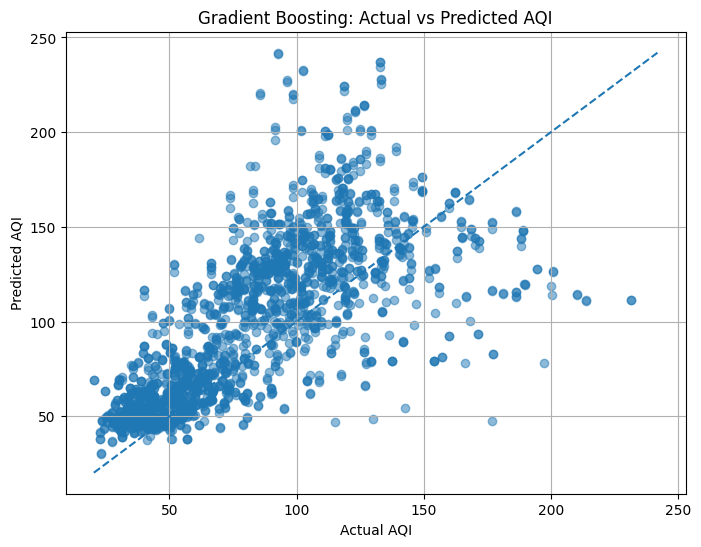

In [ ]:
# CELL 132: ACTUAL VS PREDICTED AQI

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    gb_pred,
    alpha=0.5
)

# Perfect prediction line
min_value = min(y_test.min(), gb_pred.min())
max_value = max(y_test.max(), gb_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Gradient Boosting: Actual vs Predicted AQI")
plt.grid(True)
plt.show()

In [ ]:
# CELL 133: SAVE TRAINED MODEL

import joblib
import json
from pathlib import Path

# Create model directory
MODEL_DIR = BASE_DIR / "trained_models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save model
model_path = MODEL_DIR / "gradient_boosting_aqi_model.pkl"

joblib.dump(gb_model, model_path)

# Save feature columns
features_path = MODEL_DIR / "gradient_boosting_features.json"

with open(features_path, "w") as f:
    json.dump(feature_columns, f, indent=4)

# Save metrics
metrics = {
    "model": "GradientBoostingRegressor",
    "MAE": round(gb_mae, 3),
    "RMSE": round(gb_rmse, 3),
    "R2": round(gb_r2, 3),
    "training_records": len(X_train),
    "testing_records": len(X_test)
}

metrics_path = MODEL_DIR / "gradient_boosting_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

print("✅ Model saved:", model_path)
print("✅ Features saved:", features_path)
print("✅ Metrics saved:", metrics_path)

print("\nFinal metrics:")
print(json.dumps(metrics, indent=4))

✅ Model saved: /content/drive/MyDrive/HetEvoAgent_Training/trained_models/gradient_boosting_aqi_model.pkl
✅ Features saved: /content/drive/MyDrive/HetEvoAgent_Training/trained_models/gradient_boosting_features.json
✅ Metrics saved: /content/drive/MyDrive/HetEvoAgent_Training/trained_models/gradient_boosting_metrics.json

Final metrics:
{
    "model": "GradientBoostingRegressor",
    "MAE": 26.301,
    "RMSE": 34.991,
    "R2": 0.115,
    "training_records": 3446,
    "testing_records": 1993
}


In [ ]:
# CELL 134: GENERATE AQI PREDICTIONS FOR ALL ZONES

import pandas as pd
import numpy as np
import joblib

# Load trained model
model_path = (
    BASE_DIR
    / "trained_models"
    / "gradient_boosting_aqi_model.pkl"
)

gb_model = joblib.load(model_path)

# Load zone weather data
prediction_data = pd.read_csv(
    BASE_DIR / "Datasets" / "zone_weather_features.csv"
)

prediction_data["date"] = pd.to_datetime(
    prediction_data["date"]
)

# Ensure feature columns exist
missing_features = [
    col for col in feature_columns
    if col not in prediction_data.columns
]

if missing_features:
    print("Missing features:", missing_features)
else:

    # Prepare input features
    X_prediction = prediction_data[feature_columns].copy()

    # Generate predictions
    predicted_aqi = gb_model.predict(X_prediction)

    # Prevent negative AQI predictions
    prediction_data["predicted_aqi"] = np.maximum(
        predicted_aqi,
        0
    )

    # AQI category function
    def aqi_category(aqi):
        if aqi <= 50:
            return "Good"
        elif aqi <= 100:
            return "Satisfactory"
        elif aqi <= 200:
            return "Moderate"
        elif aqi <= 300:
            return "Poor"
        elif aqi <= 400:
            return "Very Poor"
        else:
            return "Severe"

    prediction_data["aqi_category"] = (
        prediction_data["predicted_aqi"]
        .apply(aqi_category)
    )

    # Save predictions
    prediction_file = (
        BASE_DIR
        / "predictions"
        / "gradient_boosting_zone_predictions.csv"
    )

    prediction_file.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    prediction_data.to_csv(
        prediction_file,
        index=False
    )

    print("✅ Predictions generated!")
    print("Total predictions:", len(prediction_data))
    print("Zones:", prediction_data["zone"].nunique())
    print("Saved to:", prediction_file)

    print("\nAverage AQI by zone:")

    display(
        prediction_data.groupby("zone")[
            "predicted_aqi"
        ]
        .agg(["count", "mean", "min", "max"])
        .round(2)
    )

    print("\nAQI category distribution:")

    display(
        prediction_data["aqi_category"]
        .value_counts()
    )

Missing features: ['distance_km']


In [ ]:
# CELL 135: ADD DISTANCE FEATURE FOR PREDICTION

import pandas as pd
import numpy as np
import joblib

# Load files
prediction_data = pd.read_csv(
    BASE_DIR / "Datasets" / "zone_weather_features.csv"
)

stations = pd.read_csv(
    BASE_DIR / "Datasets" / "station_coordinates.csv"
)

prediction_data["date"] = pd.to_datetime(
    prediction_data["date"]
)

# Haversine distance
def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 2 * R * np.arcsin(np.sqrt(a))


# Calculate nearest distance for each zone
distance_rows = []

for _, zone in prediction_data[
    ["zone", "latitude", "longitude"]
].drop_duplicates().iterrows():

    distances = []

    for _, station in stations.iterrows():

        distance = haversine(
            zone["latitude"],
            zone["longitude"],
            station["latitude"],
            station["longitude"]
        )

        distances.append(distance)

    distance_rows.append({
        "zone": zone["zone"],
        "distance_km": min(distances)
    })

distance_df = pd.DataFrame(distance_rows)

# Add distance feature
prediction_data = prediction_data.merge(
    distance_df,
    on="zone",
    how="left"
)

# Load model
model_path = (
    BASE_DIR
    / "trained_models"
    / "gradient_boosting_aqi_model.pkl"
)

gb_model = joblib.load(model_path)

# Check missing features
missing_features = [
    col for col in feature_columns
    if col not in prediction_data.columns
]

if missing_features:
    print("Missing features:", missing_features)

else:
    # Prepare prediction features
    X_prediction = prediction_data[
        feature_columns
    ].copy()

    # Generate predictions
    prediction_data["predicted_aqi"] = np.maximum(
        gb_model.predict(X_prediction),
        0
    )

    # AQI category
    def aqi_category(aqi):
        if aqi <= 50:
            return "Good"
        elif aqi <= 100:
            return "Satisfactory"
        elif aqi <= 200:
            return "Moderate"
        elif aqi <= 300:
            return "Poor"
        elif aqi <= 400:
            return "Very Poor"
        return "Severe"

    prediction_data["aqi_category"] = (
        prediction_data["predicted_aqi"]
        .apply(aqi_category)
    )

    # Save predictions
    prediction_file = (
        BASE_DIR
        / "predictions"
        / "gradient_boosting_zone_predictions.csv"
    )

    prediction_data.to_csv(
        prediction_file,
        index=False
    )

    print("✅ Predictions generated successfully!")
    print("Total predictions:", len(prediction_data))
    print("Zones:", prediction_data["zone"].nunique())

    print("\nAverage AQI by zone:")

    display(
        prediction_data.groupby("zone")[
            "predicted_aqi"
        ]
        .agg(["count", "mean", "min", "max"])
        .round(2)
    )

    print("\nAQI category distribution:")

    display(
        prediction_data["aqi_category"]
        .value_counts()
    )

    print("\nSaved to:", prediction_file)

✅ Predictions generated successfully!
Total predictions: 8766
Zones: 6

Average AQI by zone:


,count,mean,min,max
zone,,,,
CIDCO N-5,1461,111.26,37.90,258.01
Chikalthana MIDC,1461,103.31,30.20,294.92
Garkheda-Satara Parisar,1461,108.77,38.04,257.52
Kranti Chowk,1461,111.39,38.04,257.22
Shendra MIDC,1461,103.51,30.70,293.83
Waluj MIDC,1461,87.21,37.56,181.98



AQI category distribution:


,count
aqi_category,
Moderate,4658
Satisfactory,2956
Good,900
Poor,252



Saved to: /content/drive/MyDrive/HetEvoAgent_Training/predictions/gradient_boosting_zone_predictions.csv


Average predicted AQI by zone:


,predicted_aqi
zone,
Kranti Chowk,111.39
CIDCO N-5,111.26
Garkheda-Satara Parisar,108.77
Shendra MIDC,103.51
Chikalthana MIDC,103.31
Waluj MIDC,87.21


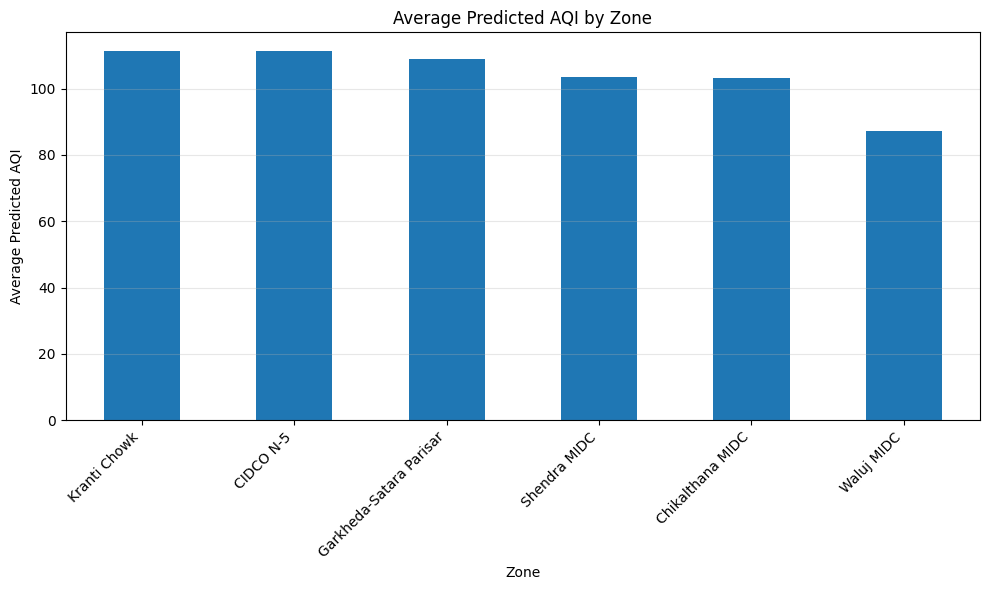

✅ Summary saved: /content/drive/MyDrive/HetEvoAgent_Training/predictions/zone_aqi_summary.csv


In [ ]:
# CELL 136: ZONE AQI SUMMARY CHART

import matplotlib.pyplot as plt

# Calculate average AQI
zone_summary = (
    prediction_data.groupby("zone")["predicted_aqi"]
    .mean()
    .sort_values(ascending=False)
)

print("Average predicted AQI by zone:")
display(zone_summary.round(2))

# Plot
plt.figure(figsize=(10, 6))

zone_summary.plot(kind="bar")

plt.title("Average Predicted AQI by Zone")
plt.xlabel("Zone")
plt.ylabel("Average Predicted AQI")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Save summary
summary_file = (
    BASE_DIR
    / "predictions"
    / "zone_aqi_summary.csv"
)

zone_summary.round(2).to_csv(
    summary_file,
    header=["average_predicted_aqi"]
)

print("✅ Summary saved:", summary_file)

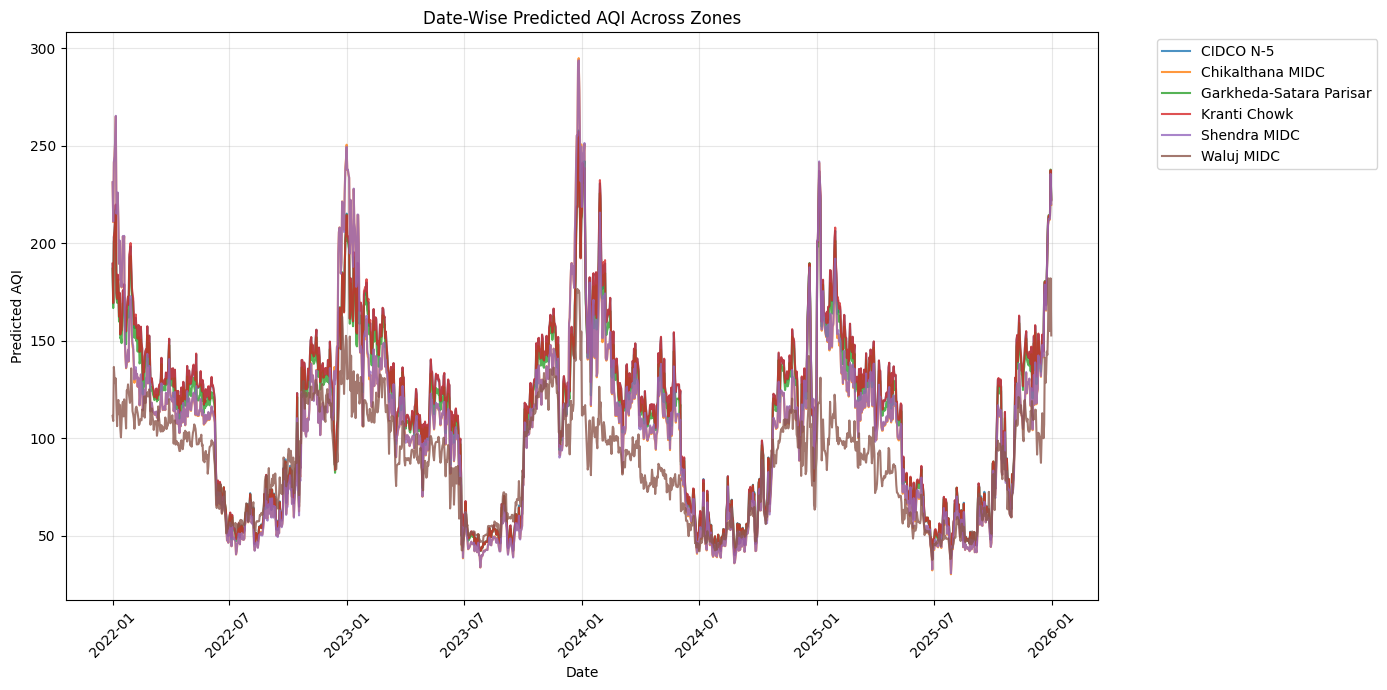

✅ AQI trend chart generated!


In [ ]:
# CELL 137: DATE-WISE AQI TREND

import matplotlib.pyplot as plt

# Ensure date format
prediction_data["date"] = pd.to_datetime(
    prediction_data["date"]
)

# Create separate trend for each zone
plt.figure(figsize=(14, 7))

for zone in prediction_data["zone"].unique():

    zone_data = prediction_data[
        prediction_data["zone"] == zone
    ].sort_values("date")

    plt.plot(
        zone_data["date"],
        zone_data["predicted_aqi"],
        label=zone,
        alpha=0.8
    )

plt.title("Date-Wise Predicted AQI Across Zones")
plt.xlabel("Date")
plt.ylabel("Predicted AQI")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("✅ AQI trend chart generated!")

Monthly average predicted AQI:


,month_name,predicted_aqi
0,January,168.04
1,February,138.91
2,March,119.58
3,April,108.98
4,May,106.80
5,June,76.32
6,July,51.07
7,August,53.56
8,September,59.08
9,October,96.41


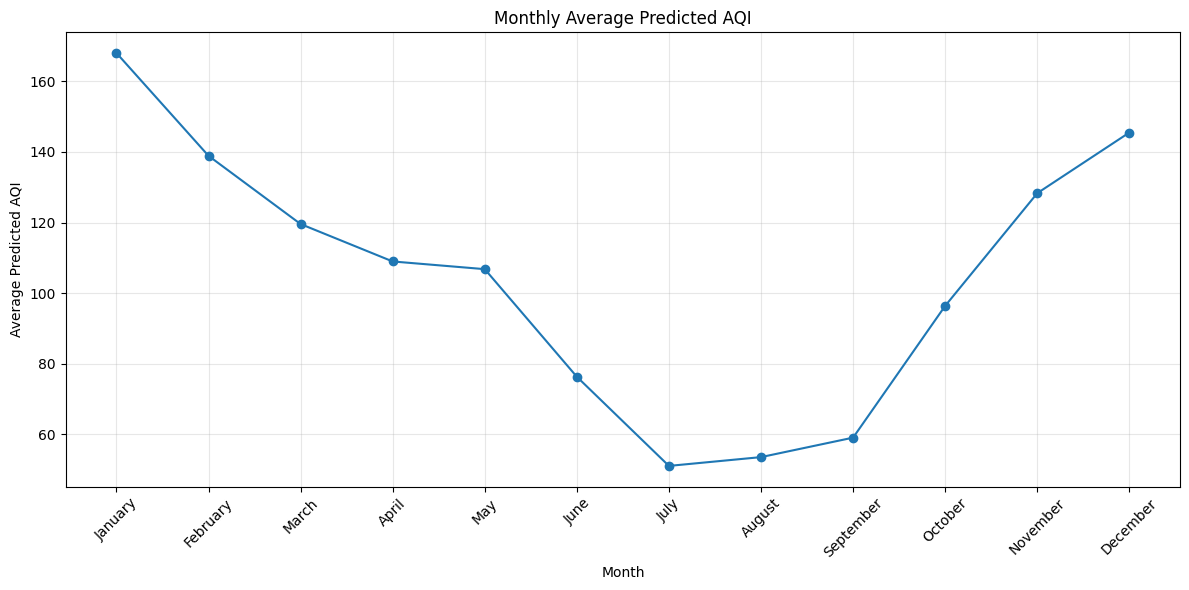

✅ Monthly analysis saved: /content/drive/MyDrive/HetEvoAgent_Training/predictions/monthly_aqi_analysis.csv


In [ ]:
# CELL 138: MONTHLY AQI ANALYSIS

import matplotlib.pyplot as plt
import pandas as pd

# Create month column
prediction_data["month_name"] = (
    prediction_data["date"].dt.month_name()
)

prediction_data["month_number"] = (
    prediction_data["date"].dt.month
)

# Calculate monthly average AQI
monthly_aqi = (
    prediction_data
    .groupby(["month_number", "month_name"])["predicted_aqi"]
    .mean()
    .reset_index()
    .sort_values("month_number")
)

print("Monthly average predicted AQI:")
display(
    monthly_aqi[
        ["month_name", "predicted_aqi"]
    ].round(2)
)

# Plot
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_aqi["month_name"],
    monthly_aqi["predicted_aqi"],
    marker="o"
)

plt.title("Monthly Average Predicted AQI")
plt.xlabel("Month")
plt.ylabel("Average Predicted AQI")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save results
monthly_file = (
    BASE_DIR
    / "predictions"
    / "monthly_aqi_analysis.csv"
)

monthly_aqi.to_csv(
    monthly_file,
    index=False
)

print("✅ Monthly analysis saved:", monthly_file)